# پایپ‌لاینِ کاملِ کاورد کال — از پیش‌بینیِ قیمت تا انتخابِ اختیار و بک‌تست
### End-to-End: Price Prediction → Portfolio → Option Selection → Backtest (TSE, 6-Asset Universe)

این نوت‌بوک، نسخه‌ی **نهایی و یکپارچه**‌ی کلِ کاری است که مرحله‌به‌مرحله انجام
شد — از سلولِ اول تا آخر، پشتِ‌سرِهم قابلِ‌اجراست و زیرِ هر سلول خروجیِ واقعیِ
همان اجرا قرار دارد. چهار بخشِ اصلی:

| بخش | سؤال | خروجی |
|---|---|---|
| **۱. پیش‌بینیِ قیمتِ سررسید** | قیمتِ هر سهم در تاریخِ سررسید چند می‌شود؟ | مدلِ Ensemble (LightGBM/XGBoost/CatBoost/RandomForest/Ridge/CNN-LSTM+GRU) + بازه‌ی کوانتایلِ ۱۰٪-۹۰٪ |
| **۲. ساختِ پورتفو** | با این پیش‌بینی‌ها، چه وزنی از سرمایه به هر سهم برود؟ | Black-Litterman + Ledoit-Wolf، وزن‌هایی که جمعشان ۱ است |
| **۳. انتخابِ اختیارِ خرید** | برایِ هر سهم، کدام Strike/سررسیدِ اختیارِ خرید فروخته شود؟ | بهینه‌سازیِ مطلوبیتِ میانگین-واریانس روی شبکه‌ی Strike×سررسید |
| **۴. بک‌تست** | اگر این کار در گذشته انجام می‌شد، واقعاً سودآور بود؟ | مقایسه‌ی Walk-Forwardِ کاورد کال در برابرِ Buy&Hold، با معیارهایِ استانداردِ صنعت |

هر بخش خودش قبلاً به‌صورتِ جداگانه ساخته و اجرا شده بود
(`price_at_maturity_prediction.ipynb`، `portfolio_construction.ipynb`،
`covered_call_option_selection.ipynb`)؛ این نوت‌بوک همان منطق را بدونِ تغییر
در **یک فایلِ واحد و پیوسته** ادغام می‌کند و بخشِ بک‌تست را (که تا این‌جا
وجود نداشت) به آن اضافه می‌کند. دو آزمایشِ مکملِ بخشِ پیش‌بینی (Pooling و
طبقه‌بندیِ احتمالِ عبور از Strike) که نتیجه‌ی نهایی را تغییر ندادند، برای
فشرده‌ماندنِ این نسخه‌ی نهایی حذف شده‌اند — جزئیاتشان در
`price_at_maturity_prediction.ipynb` باقی مانده.

**اصلِ راهنمایِ سرتاسرِ کار:** هیچ مرحله‌ای به آینده نگاه نمی‌کند (Purged
Time-Series CV، Embargo Gap، انتخابِ مدل فقط روی Validation)، و هر نتیجه —
مثبت یا منفی — همان‌طور که به‌دست آمده گزارش می‌شود.

---
# بخشِ ۱ — پیش‌بینیِ قیمتِ سررسید
---

# پیش‌بینی قیمت سهم در تاریخ سررسید — بورس اوراق بهادار تهران (v1)
### Price-at-Maturity Forecasting for TSE Covered-Call Underlyings

**هدف این نوت‌بوک** با نسخه‌ی قبلی پروژه (`covered_call_strategy.ipynb`) اساساً فرق دارد:

- نسخه‌ی قبلی یک مدل **کلاسیفیکیشن** آموزش می‌داد («احتمال صعود/نزول تا افق ثابت ۵ روزه»)
  که خروجی‌اش فقط برای گیتِ فروش/عدم‌فروش کال در بک‌تست استفاده می‌شد؛ هیچ پیش‌بینیِ
  عددیِ قیمت وجود نداشت. AUCهای واقعی آن (طبق `horizon_selection_summary.csv` موجود در
  ریپازیتوری) هم اغلب نزدیک ۰.۵ (تصادف) بودند.
- **این نسخه** مستقیماً روی هدف اصلیِ کاربر تمرکز می‌کند: **پیش‌بینیِ سطح قیمتِ سهم در
  خودِ تاریخ سررسید** (Maturity Date) — همان چیزی که برای طراحیِ واقعیِ استراتژیِ
  کاورد کال (تعیینِ Strike، برآوردِ سود/زیانِ اختیار، و تصمیمِ نگه‌داشتن/فروش) واقعاً
  لازم است.

**دامنه‌ی این نسخه (طبق درخواست):** فقط تا مرحله‌ی «پیش‌بینیِ دقیقِ قیمت در سررسید»
پیش می‌رویم؛ اتصالِ این پیش‌بینی‌ها به موتورِ کاملِ بک‌تستِ کاورد کال (فرمول بلک-شولز،
انتخابِ Strike/Premium، محاسبه‌ی Sharpe/Sortino) به نسخه‌ی بعدی موکول می‌شود.

## چرا این‌طور طراحی شده — خلاصه‌ی روش‌شناسی حرفه‌ای

| مسئله | چالشِ بازار ایران | راه‌حلِ به‌کاررفته |
|---|---|---|
| هدف پیش‌بینی | قیمت سهم نوسانِ زیادی دارد و سطح خامِ آن Non-Stationary است | به‌جای پیش‌بینیِ مستقیمِ قیمت، **بازدهِ لگاریتمیِ تجمعیِ H روزه** پیش‌بینی می‌شود؛ قیمت سررسید از رابطه‌ی $\hat P_{t+H}=P_t\cdot e^{\hat r}$ بازسازی می‌شود (استاندارد در مالیِ کمّی). |
| جهش‌های قیمتیِ افراطی | افزایش سرمایه/تجدید ارزیابی در TSETMC جهش‌های ۳۰٪ تا ۹۰٪+ ایجاد می‌کند که ربطی به نوسانِ بازار ندارد | **Back-Adjustment وقایعِ شرکتی** (همان ایده‌ای که در نسخه‌ی قبلیِ پروژه به‌درستی اضافه شده بود، اینجا هم حفظ شده). |
| نوسانِ شدید/رژیم‌های متفاوت | بورس تهران در ۱۵ سال اخیر چند رژیمِ کاملاً متفاوتِ تورمی/رکودی را رد کرده | فیچرِ **نوسانِ شرطیِ GARCH(1,1)-t** (برازش‌شده فقط روی داده‌ی Train)، **وزن‌دهیِ نمایی به‌نفعِ داده‌ی جدید** (Recency Weighting)، و فیچرهای کلانِ **نرخ دلار آزاد**. |
| نشتِ داده (Leakage) | هدف H روز جلوتر را می‌بیند؛ بدون احتیاط، مرزِ Train/Val/Test نشت می‌دهد | **Purged Split با Embargo Gap = H روز** بینِ هر دو بخش (دقیقاً همان اصلِ Purged Cross-Validation در کتابِ *Advances in Financial Machine Learning*, López de Prado 2018). |
| انتخابِ افقِ سررسید | افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی کاملاً دلبخواهی بود | **تورنمنتِ افق** روی چند افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی) با معیارِ Skill نسبت به یک baseline ساده، روی Walk-Forward Purged Folds — فقط از داده‌ی پیش از Test استفاده می‌شود (نه cherry-picking روی Test). |
| مدل‌های قوی | یک مدلِ تکی معمولاً بی‌ثبات است | مجموعه‌ای از baselineهای کلاسیک مالی (Random Walk، Drift، GBM با نوسانِ GARCH) + مدل‌های یادگیریِ ماشین (Ridge، LightGBM، XGBoost، CatBoost، RandomForest) + یک خانواده‌ی مدلِ سری‌زمانیِ عمیق (**CNN-LSTM/GRU + Attention**، PyTorch) + یک **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** (Forecast Combination، ایده‌ی Bates & Granger 1969) که اگر مدل‌های ML چیزی روی baseline اضافه نکنند، خودکار به baseline برمی‌گردد. |
| هایپرپارامترهای هر مدل | هایپرپارامترِ پیش‌فرض به‌ندرت بهینه است | **تیونینگِ اختصاصیِ هر مدل** روی Validation: `GridSearchCV` (اسکای‌لرن، با CV سفارشیِ Purged) برایِ Ridge/RandomForest؛ Optuna/TPE (بهینه‌سازیِ بیزی، برایِ فضاهایِ پیوسته) برایِ LightGBM/XGBoost/CatBoost؛ Grid Search دستیِ معماری برایِ CNN-LSTM/GRU. تعدادِ ترکیب‌ها در هر گرید عمداً کم نگه داشته شده (۶ تا ۸ ترکیب). |
| عدمِ‌قطعیت | یک عددِ تکی برای قیمتِ سررسید در بازارِ پرنوسان گمراه‌کننده است | **رگرسیونِ کوانتایل** (۱۰٪/۵۰٪/۹۰٪) با LightGBMِ تیون‌شده → بازه‌ی پیش‌بینیِ قیمتِ سررسید، نه فقط یک نقطه. |
| صداقتِ علمی | انتخابِ مدل روی Test = Data Snooping | مدلِ «پیشنهادی» برای هر سهم فقط بر اساسِ **Validation RMSE** انتخاب می‌شود؛ Test فقط یک‌بار در پایان، صرفاً برای گزارش، لمس می‌شود. یک تست Walk-Forward Robustness (تشخیصی) هم پایداریِ نتیجه را نشان می‌دهد. |
| 🆕 داده‌ی کم به‌ازای هر سهم | هر سهم فقط از تاریخچه‌ی خودش (~۲۰۰۰-۳۰۰۰ ردیف) یاد می‌گیرد | فیچرِ **بازدهِ بازارِ Leave-One-Out** (بخشِ ۱.۵) + یک آزمایشِ **مدلِ Pooled** (بخشِ ۱۳.۵) که هر ۶ سهم را با هم آموزش می‌دهد تا ببینیم Pooling واقعاً کمک می‌کند یا نه. |
| 🆕 هدف نادرست برای تصمیمِ واقعی | پیش‌بینیِ «قیمتِ دقیق» سخت‌تر از چیزی است که کاورد کال واقعاً لازم دارد | یک هدفِ **هم‌راستا با تصمیم** هم اضافه شده (بخشِ ۱۳.۷): به‌جای قیمتِ دقیق، احتمالِ «عبور از Strike» (طبقِ `STRIKE_PCT` پروژه‌ی اصلی) به‌صورتِ طبقه‌بندی پیش‌بینی می‌شود. |

**الهام‌گیری از ادبیاتِ حرفه‌ای:** ترکیبِ درخت‌های گرادیان‌بوست + شبکه‌ی توالی برای
پیش‌بینیِ مالی (Kim & Won, 2018 — hybrid GARCH-LSTM)، معماریِ CNN-LSTM برایِ
استخراجِ الگوهای محلی پیش از مدل‌سازیِ توالی (Lu, Zhang & Xu, 2020؛ همان الگویی که
در نسخه‌ی v17 پروژه هم استفاده شده بود)، Purged/Embargoed Cross-Validation
(López de Prado, 2018)، بهینه‌سازیِ بیزیِ هایپرپارامتر با TPE به‌جای Grid Search
کلاسیک برای فضاهای پیوسته (Bergstra et al., 2011)، اهمیتِ baselineهای
Random-Walk/Drift در پیش‌بینیِ قیمت (Meese & Rogoff puzzle در ادبیاتِ ارز/سهام)، و
رگرسیونِ کوانتایل برای کمّی‌سازیِ ریسک در بازارهای نوظهور با نوسانِ بالا.

⚠️ **صداقتِ علمی، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه:** نتایج هرچه باشند (حتی اگر یک
baseline ساده برنده شود) دقیقاً همان‌طور که به‌دست آمده گزارش می‌شوند — این خودش
برای بازارِ تهران یک یافته‌ی معتبر است (سازگار با فرضیه‌ی کارایی ضعیفِ بازار).

In [1]:
import warnings, time, os, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
import torch
torch.manual_seed(GLOBAL_SEED)

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_CANDIDATES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
ASSET_NAMES = [n for n in ASSET_CANDIDATES if os.path.exists(DATA_DIR + f'{n}.csv')]
if len(ASSET_NAMES) < len(ASSET_CANDIDATES):
    missing = set(ASSET_CANDIDATES) - set(ASSET_NAMES)
    print(f"⚠️ فایل این نمادها پیدا نشد و نادیده گرفته می‌شوند: {missing}")

CORP_ACTION_THRESHOLD = 0.25     # جهش تک‌روزه بیش از این درصد -> واقعه‌ی شرکتی فرض می‌شود
MATURITY_CANDIDATES  = [10, 15, 20, 30]   # کاندیدهای افق سررسید (روز معاملاتی)
HORIZON_WF_SPLITS    = 4
HORIZON_MIN_MARGIN   = 0.01
VAL_FRAC             = 0.15
TEST_FRAC            = 0.25   # افزایش‌یافته از ۰.۱۵ برای دو برابر شدنِ تقریبیِ تعدادِ دوره‌هایِ بک‌تست
RECENCY_HALF_LIFE     = 500        # نیم‌عمر وزنِ نمایی (ردیف) ~ ۲ سالِ معاملاتی

print(f"✅ Ready | assets={ASSET_NAMES} | data_dir={DATA_DIR}")

✅ Ready | assets=['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat'] | data_dir=/home/user/CoveredCall/data/


## ۱) بارگذاری و پاکسازیِ داده + تعدیلِ وقایعِ شرکتی

داده‌های خامِ TSETMC گاهی جهش‌های قیمتیِ افراطی (تا ده‌ها درصد در یک روز) دارند که
ناشیِ از افزایشِ سرمایه یا تجدیدِ ارزیابی هستند، نه نوسانِ واقعیِ بازار. دامنه‌ی نوسانِ
روزانه‌ی مجازِ بورسِ تهران معمولاً ±۵٪ تا ±۶٪ است، پس هر جهشِ تک‌روزه‌ی بیش از ۲۵٪
تقریباً همیشه یک رویدادِ شرکتی است. تابعِ زیر (با همان منطقِ نسخه‌ی قبلیِ پروژه) این
جهش‌ها را با روشِ **Back-Adjustment** (دقیقاً مشابهِ تعدیلِ تقسیمِ سهام) اصلاح می‌کند:
آخرین قیمت دست‌نخورده می‌ماند و کلِ تاریخچه‌ی *قبل* از هر جهش با ضریبِ همان جهش
ضرب می‌شود.

In [2]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    events = []
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0:
            raw_ret = c1 / c0 - 1.0
            if abs(raw_ret) > threshold:
                local_factor = c1 / c0
                cum *= local_factor
                events.append((df.index[i + 1], raw_ret, local_factor))
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df, events[::-1]


usd_close = pd.read_csv(DATA_DIR + 'USD_IRR.csv', parse_dates=['date']).set_index('date').sort_index()['usd_close']
print(f"✅ نرخ دلار بارگذاری شد: {usd_close.index.min().date()} تا {usd_close.index.max().date()} ({len(usd_close)} ردیف)")

processed = {}
corp_events = {}
summary_rows = []
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df, ev = adjust_corporate_actions(df)
    corp_events[name] = ev
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    df = df.loc['2010-01-01':]
    processed[name] = df
    summary_rows.append(dict(Asset=name, Rows=len(df), Start=df.index.min().date(),
                              End=df.index.max().date(), CorpActionEvents=len(ev),
                              LargestRawJump=f"{max((abs(e[1]) for e in ev), default=0)*100:.0f}%"))
summary_df = pd.DataFrame(summary_rows)
summary_df

✅ نرخ دلار بارگذاری شد: 2011-11-26 تا 2026-09-01 (3940 ردیف)


,Asset,Rows,Start,End,CorpActionEvents,LargestRawJump
0,Fameli,3448,2010-01-02,2025-04-15,5,66%
1,Fulad,3424,2010-01-02,2025-04-16,10,42%
2,IranKhodro,3296,2010-01-02,2025-03-16,10,100%
3,Khgostar,3405,2010-01-02,2025-04-16,6,109%
4,Shapna,2969,2010-02-16,2025-04-16,11,243%
5,VebMellat,3215,2010-01-02,2025-04-16,7,76%


## ۱.۵) 🆕 فیچرِ هم‌حرکتیِ بازار (Cross-Sectional Leave-One-Out)

تا این‌جا هر سهم فقط از تاریخچه‌ی خودش یاد می‌گرفت — هیچ اطلاعی از این‌که «امروز
کلِ بازار چطور بوده» یا «سهم‌های دیگر چه حرکتی داشته‌اند» در فیچرها نبود. چون
بورسِ تهران معمولاً روی اخبارِ کلان/سیاسی به‌صورتِ هم‌زمان حرکت می‌کند، بازدهِ
هم‌بورسی‌ها می‌تواند سیگنالِ واقعی داشته باشد. برای هر سهم، یک **بازدهِ بازارِ
Leave-One-Out** ساخته می‌شود: میانگینِ بازدهِ همان روزِ بقیه‌ی ۵ سهم (بدونِ
احتسابِ خودِ سهم — تا فیچر مصنوعاً شبیهِ target نشود). این یک شاخصِ بازارِ
داخلی است که فقط از همین ۶ فایلِ CSV ساخته می‌شود (بدون نیاز به دیتای بیرونی).

In [3]:
ret_wide = pd.DataFrame({name: np.log(df['close'] / df['close'].shift(1)) for name, df in processed.items()})
row_sum = ret_wide.sum(axis=1, skipna=True)
row_cnt = ret_wide.count(axis=1)
mkt_loo = pd.DataFrame(index=ret_wide.index)
for name in ASSET_NAMES:
    denom = (row_cnt - ret_wide[name].notna().astype(int)).replace(0, np.nan)
    mkt_loo[name] = (row_sum - ret_wide[name].fillna(0)) / denom
print(f"✅ بازدهِ بازارِ Leave-One-Out ساخته شد — {ret_wide.shape[0]} روز، {ret_wide.shape[1]} سهم")

✅ بازدهِ بازارِ Leave-One-Out ساخته شد — 3675 روز، 6 سهم


## ۲) مهندسیِ فیچر — تکنیکال + نوسان + کلان + تقویمی + هم‌حرکتیِ بازار

فیچرها در چهار دسته‌ی معنادار ساخته می‌شوند (هیچ‌کدام از آینده استفاده نمی‌کنند —
همه‌شان فقط از `close/high/low/vol` تا لحظه‌ی *t* محاسبه می‌شوند):

1. **مومنتوم/بازده**: بازدهِ لگاریتمیِ ۱/۳/۵/۱۰/۲۰ روزه، MACD، RSI، Momentum، Stochastic.
2. **نوسان/ریسک**: انحرافِ معیارِ غلتان (چند پنجره)، ATR%، پهنای بولینگر، نسبتِ نوسانِ
   کوتاه‌به‌بلندمدت، Skewness/Kurtosis غلتان (چون توزیعِ بازدهیِ TSE دنباله‌ی سنگین دارد).
3. **حجم/جریانِ نقدینگی**: Z-Score حجم، شیبِ OBV.
4. **کلان و تقویمی**: بازده/نوسانِ نرخِ دلارِ آزاد (چون سهم‌های این نمونه عمدتاً
   صادرات‌محور یا وابسته به دلار هستند)، روزِ هفته، ماه، پایانِ ماه.
5. 🆕 **هم‌حرکتیِ بازار**: بازدهِ بازارِ Leave-One-Out (بخشِ ۱.۵) و بازدهِ نسبی
   (`rel_strength_loo` = بازدهِ خودِ سهم منهایِ بازدهِ بقیه‌ی سهم‌ها) — آیا این سهم
   امروز از «میانگینِ بازار» جلوتر بوده یا عقب‌تر.

عمداً فقط از **بازده/نوسانِ کوتاه‌مدتِ دلار** استفاده شده، نه سطحِ خامِ آن — سطحِ خامِ
دلار در این بازه تقریباً یک‌طرفه (صعودی) است و می‌تواند صرفاً «زمان» را به مدل نشت
بدهد، نه سیگنالِ معاملاتیِ واقعی.

In [4]:
def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def build_features(df, usd=None, mkt=None):
    d = pd.DataFrame(index=df.index)
    close = df['close']; high = df.get('high', close); low = df.get('low', close)
    vol = df.get('vol', pd.Series(0, index=df.index))
    logret = np.log(close / close.shift(1))
    d['ret1'] = logret
    for w in [3, 5, 10, 20]:
        d[f'ret{w}'] = np.log(close / close.shift(w))
    for w in [10, 20, 30]:
        d[f'vol{w}'] = logret.rolling(w).std()
    d['vol_ratio'] = d['vol10'] / d['vol30'].replace(0, np.nan)
    tr = pd.concat([(high - low), (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    d['atr_pct'] = tr.rolling(14).mean() / close
    sma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    d['bb_width'] = (4 * std20) / sma20
    d['bb_pos'] = (close - (sma20 - 2 * std20)) / (4 * std20).replace(0, np.nan)
    d['rsi14'] = rsi(close, 14)
    ema12 = close.ewm(span=12, adjust=False).mean(); ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26; macd_sig = macd.ewm(span=9, adjust=False).mean()
    d['macd'] = macd / close
    d['macd_hist'] = (macd - macd_sig) / close
    for w in [10, 20, 50]:
        d[f'sma{w}_dev'] = close / close.rolling(w).mean() - 1
    d['mom10'] = close / close.shift(10) - 1
    d['mom20'] = close / close.shift(20) - 1
    ll14 = low.rolling(14).min(); hh14 = high.rolling(14).max()
    stoch_k = 100 * (close - ll14) / (hh14 - ll14).replace(0, np.nan)
    d['stoch_k'] = stoch_k; d['stoch_d'] = stoch_k.rolling(3).mean()
    vol_sma20 = vol.rolling(20).mean(); vol_std20 = vol.rolling(20).std()
    d['vol_z20'] = (vol - vol_sma20) / vol_std20.replace(0, np.nan)
    obv = (np.sign(logret.fillna(0)) * vol).cumsum()
    d['obv_slope'] = obv.diff(5) / vol.rolling(20).mean().replace(0, np.nan)
    d['skew20'] = logret.rolling(20).skew()
    d['kurt20'] = logret.rolling(20).kurt()
    d['days_since_high20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmax(x), raw=True)
    d['days_since_low20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmin(x), raw=True)
    d['dow'] = df.index.dayofweek
    d['month'] = df.index.month
    d['is_month_end'] = df.index.is_month_end.astype(int)
    if usd is not None:
        usd_a = usd.reindex(df.index, method='ffill')
        usd_ret = np.log(usd_a / usd_a.shift(1))
        d['usd_ret5'] = usd_ret.rolling(5).sum()
        d['usd_ret20'] = usd_ret.rolling(20).sum()
        d['usd_vol20'] = usd_ret.rolling(20).std()
        d['usd_dev_sma50'] = usd_a / usd_a.rolling(50).mean() - 1
    else:
        for c in ['usd_ret5', 'usd_ret20', 'usd_vol20', 'usd_dev_sma50']:
            d[c] = 0.0
    if mkt is not None:
        m = mkt.reindex(df.index)
        d['mkt_ret_loo'] = m
        d['mkt_ret_loo5'] = m.rolling(5).sum()
        d['mkt_ret_loo20'] = m.rolling(20).sum()
        d['mkt_vol_loo20'] = m.rolling(20).std()
        d['rel_strength_loo'] = logret - m
    else:
        for c in ['mkt_ret_loo', 'mkt_ret_loo5', 'mkt_ret_loo20', 'mkt_vol_loo20', 'rel_strength_loo']:
            d[c] = 0.0
    return d

print("✅ build_features() آماده است —",
      len(build_features(processed[ASSET_NAMES[0]], usd_close, mkt_loo[ASSET_NAMES[0]]).columns), "فیچر تولید می‌کند")

✅ build_features() آماده است — 40 فیچر تولید می‌کند


## ۳) فیچرِ نوسانِ شرطیِ GARCH(1,1)-t

برخلافِ نوسانِ غلتانِ ساده (که فقط میانگینِ گذشته را می‌بیند)، مدلِ GARCH نوسان را
به‌صورتِ **شرطی و پویا** مدل می‌کند — دقیقاً مناسبِ بازاری مثلِ تهران که خوشه‌بندیِ
نوسان (Volatility Clustering) در آن شدید است. برای جلوگیری از نشتِ داده، مدل **فقط
روی بخشِ پیش از Test برازش می‌شود** («Pre-Test»)؛ سپس با همان پارامترهای ثابت (نه
پارامترهای جدید) روی کلِ سری فیلتر می‌شود (`arch_model(...).fix(params)`) — یعنی
اطلاعاتِ Test هرگز در تخمینِ پارامترها استفاده نمی‌شود.

In [5]:
from arch import arch_model

def garch_vol_feature(close, n_train_only):
    # نکته: پارامتر باید مرزِ *فقط Train* باشد، نه Pre-test (Train+Val) —
    # وگرنه GARCH هنگامِ برآوردِ پارامترها، بازده‌های دوره‌ی Validation را هم
    # می‌بیند (نشتِ خفیف به Validation، حتی اگر مدلِ ML خودش Validation را
    # ندیده باشد).
    logret_pct = (np.log(close / close.shift(1)) * 100).dropna()
    train_part = logret_pct.iloc[:n_train_only]
    try:
        am = arch_model(train_part, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        am_full = arch_model(logret_pct, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res_full = am_full.fix(res.params)
        return (res_full.conditional_volatility / 100.0).reindex(close.index)
    except Exception as e:
        print('  ⚠️ GARCH fit failed:', e)
        return pd.Series(np.nan, index=close.index)

print("✅ garch_vol_feature() آماده است")

✅ garch_vol_feature() آماده است


## ۴) اعتبارسنجیِ بدونِ نشت — Purged Split + Embargo + وزن‌دهیِ زمانی

چون Target هر روز به‌اندازه‌ی H روز به جلو نگاه می‌کند، اگر مرزِ Train/Val/Test بدونِ
فاصله باشد، چند ردیفِ آخرِ Train «دید»ی به داده‌ی Val/Test خواهند داشت (Leakage).
راه‌حل: بینِ هر دو بخش یک **Embargo Gap به‌اندازه‌ی H** حذف می‌شود (Purged
Time-Series Split، دقیقاً طبقِ روشِ López de Prado در *Advances in Financial Machine
Learning*).

همچنین چون بازارِ TSE در بازه‌های مختلف رژیم‌های کاملاً متفاوتی داشته، به مدل‌های
درختی وزنِ نمایی می‌دهیم که ردیف‌های نزدیک‌تر به امروز را مهم‌تر می‌شمارد
(Recency Weighting, نیم‌عمر = ۵۰۰ ردیف ≈ ۲ سالِ معاملاتی).

In [6]:
def purged_split(n, val_frac, test_frac, purge):
    test_size = int(n * test_frac); val_size = int(n * val_frac)
    test_start = n - test_size; val_start = test_start - val_size
    train_end = max(val_start - purge, 1)
    val_end = max(test_start - purge, train_end + 1)
    return slice(0, train_end), slice(val_start, val_end), slice(test_start, n)


def purged_walkforward_folds(n_train, n_splits, purge, min_train=200):
    fold_size = (n_train - min_train) // (n_splits + 1)
    folds = []
    for k in range(n_splits):
        tr_end = min_train + fold_size * (k + 1)
        va_start = tr_end + purge
        va_end = va_start + fold_size
        if va_end > n_train or fold_size <= 0:
            break
        folds.append((slice(0, tr_end), slice(va_start, va_end)))
    return folds


def recency_weights(n, half_life=RECENCY_HALF_LIFE):
    return 0.5 ** ((n - 1 - np.arange(n)) / half_life)


class PurgedWalkForwardCV:
    '''شیءِ CV سازگار با اسکای‌لرن (split/get_n_splits) برای استفاده‌ی مستقیم در
    GridSearchCV — دقیقاً همان فولدهای Purged Walk-Forward بالا را برمی‌گرداند
    (نه KFold تصادفی که برای داده‌ی سری‌زمانی نامعتبر است).'''
    def __init__(self, n, n_splits=3, purge=10, min_train=200):
        self.folds = purged_walkforward_folds(n, n_splits, purge, min_train)

    def split(self, X, y=None, groups=None):
        for tr_s, va_s in self.folds:
            yield np.arange(tr_s.start, tr_s.stop), np.arange(va_s.start, va_s.stop)

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

print("✅ توابعِ Split/Weighting + کلاسِ PurgedWalkForwardCV آماده‌اند")

✅ توابعِ Split/Weighting + کلاسِ PurgedWalkForwardCV آماده‌اند


## ۵) تورنمنتِ افقِ سررسید (Maturity Horizon Selection)

افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی یک انتخابِ دلبخواهی بود. اینجا برای هر سهم، چند
افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی — بازه‌ای معقول برای سررسیدِ اختیارهای
کوتاه‌مدت تا میان‌مدت) با معیارِ **Skill** مقایسه می‌شوند:

$$\text{Skill} = 1 - \frac{\text{RMSE}_{\text{مدل}}}{\text{RMSE}_{\text{baseline drift}}}$$

روی چند فولدِ Purged Walk-Forward که **فقط از داده‌ی پیش از Test** ساخته می‌شوند (نه
از کلِ داده) — یعنی افق را با نگاه‌کردن به Test انتخاب نمی‌کنیم؛ این خودش یک شکلِ
ظریف از Data Snooping می‌بود. Skill مثبت یعنی مدل بهتر از baseline است؛ منفی یعنی
حتی یک مدلِ ساده هم نمی‌تواند بر پیش‌بینیِ «بدونِ تغییر» غلبه کند (که در بازارهای
کارا، به‌خصوص در افق‌های کوتاه، رایج است). از بینِ افق‌هایی که Skill‌شان به بهترین
نزدیک است (اصلِ ساده‌گرایی)، کوتاه‌ترین انتخاب می‌شود.

In [7]:
import lightgbm as lgb

def evaluate_horizon(feat_no_target, close, h, n_pretest):
    target = np.log(close.shift(-h) / close)
    feat = feat_no_target.copy()
    feat['target'] = target
    feat = feat.dropna()
    eligible_end = max(n_pretest - 1 - h, 0)   # embargo: h روزِ آخرِ پیش از مرزِ
    feat = feat[feat.index <= close.index[eligible_end]]
    X = feat.drop(columns='target').values
    y = feat['target'].values
    folds = purged_walkforward_folds(len(feat), HORIZON_WF_SPLITS, purge=h)
    if not folds:
        return np.nan
    skills = []
    for tr_s, va_s in folds:
        Xtr, ytr = X[tr_s], y[tr_s]
        Xva, yva = X[va_s], y[va_s]
        if len(Xva) < 10:
            continue
        m = lgb.LGBMRegressor(n_estimators=150, num_leaves=15, learning_rate=0.05,
                               min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
                               verbose=-1, random_state=GLOBAL_SEED)
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)
        rmse_model = np.sqrt(np.mean((pred - yva) ** 2))
        rmse_naive = np.sqrt(np.mean((yva - ytr.mean()) ** 2))
        skills.append(1.0 - rmse_model / rmse_naive if rmse_naive > 0 else np.nan)
    return np.mean(skills) if skills else np.nan

print("✅ evaluate_horizon() آماده است")

✅ evaluate_horizon() آماده است


## ۶) مدل‌ها + تیونینگِ هایپرپارامتر (برای هر مدل جداگانه)

🆕 **GARCH_LSTM_Hybrid**: به‌جایِ استفاده از `garch_vol` صرفاً به‌عنوانِ یک فیچرِ عادی (که همه‌ی مدل‌ها از قبل به آن دسترسی دارند)، اینجا یک ترکیبِ واقعیِ GARCH+LSTM پیاده می‌شود: هدفِ آموزشِ SeqNet نه بازدهِ خامِ H-روزه، بلکه بازدهِ **استانداردشده با نوسانِ شرطیِ GARCH** است (`y_std = y / (garch_vol * sqrt(H))`) — یعنی اثرِ خوشه‌بندیِ نوسان (heteroskedasticity) قبل از آموزش حذف می‌شود تا شبکه روی الگویِ خودِ بازده تمرکز کند، نه دامنه‌ی نوسانش. در پیش‌بینی، خروجیِ شبکه دوباره در `garch_vol*sqrt(H)` ضرب می‌شود تا به مقیاسِ بازدهِ واقعی برگردد. این دقیقاً همان معماریِ رایجِ «GARCH-LSTM hybrid» در ادبیاتِ پیش‌بینیِ قیمت است.

**Baselineهای مالیِ کلاسیک** (برای این‌که مدل‌های ML مجبور باشند واقعاً چیزی «اضافه»
کنند، نه این‌که صرفاً از یک baseline ضعیف بهتر باشند):
- `Naive_RW`: بدونِ تغییر (Random Walk خالص).
- `Drift_RW`: میانگینِ تاریخیِ بازدهِ H‌روزه (Random Walk with Drift).
- `GBM_GARCH`: میانگینِ رانه‌ی روزانه × H (معادلِ حرکتِ براونیِ هندسی؛ خودِ فرضِ
  پایه‌ای مدلِ بلک-شولز).

**مدل‌های یادگیریِ ماشین/عمیق** — این‌بار **هر مدل با روشِ تیونینگِ مناسبِ خودش**
روی Validation بهینه می‌شود (نه فقط دو مدل مثل نسخه‌ی قبلی):

| مدل | روشِ تیونینگ | فضای جستجو |
|---|---|---|
| `Ridge` | **GridSearchCV** (اسکای‌لرن) با CV سفارشیِ Purged Walk-Forward | ۶ مقدار برای `alpha` |
| `RandomForest` | **GridSearchCV** با همان CV | ۲×۲×۲=۸ ترکیب (`n_estimators`×`max_depth`×`min_samples_leaf`) |
| `LightGBM` | Optuna/TPE (بهینه‌سازیِ بیزی) | ۶ هایپرپارامترِ پیوسته، ۴۰ trial |
| `XGBoost` | Optuna/TPE | ۵ هایپرپارامتر، ۳۰ trial |
| `CatBoost` | Optuna/TPE | ۳ هایپرپارامتر، ۲۰ trial |
| `DeepSeq` (زیر) | **Grid Search دستی روی معماری** | ۵ ترکیب |

چرا برای LightGBM/XGBoost/CatBoost از Optuna به‌جای GridSearchCV؟ چون این مدل‌ها
چند هایپرپارامترِ **پیوسته** دارند و اندازه‌ی یک گریدِ کلاسیک با هر بُعدِ اضافه
به‌صورتِ نمایی رشد می‌کند (Curse of Dimensionality) — یعنی برای پوششِ همین فضا با
Grid Search کلاسیک، به صدها ترکیب نیاز بود. Optuna با نمونه‌گیریِ بیزیِ TPE با
همان تعدادِ کمِ trial (طبقِ خواسته‌ی «جستجوی زیاد نه») به نتیجه‌ای هم‌ارز یا بهتر از
یک گریدِ بسیار بزرگ می‌رسد — این خودش یکی از رایج‌ترین روش‌های حرفه‌ای در صنعت است.
برای `Ridge`/`RandomForest` که فضای هایپرپارامترشان کوچک و گسسته است، مستقیماً از
**GridSearchCV** استفاده شده (طبقِ درخواستِ صریح)، اما با یک کلاسِ CV سفارشی
(`PurgedWalkForwardCV`، تعریف‌شده در بخشِ ۴) به‌جایِ k-fold تصادفیِ پیش‌فرضِ
اسکای‌لرن — چون k-fold تصادفی ترتیبِ زمانی را به‌هم می‌ریزد و برای سری‌زمانیِ مالی
باعثِ نشتِ داده می‌شود.

### مدلِ سری‌زمانیِ عمیق: CNN + LSTM/GRU + Attention

به‌جای یک LSTM ساده، یک معماریِ یکپارچه (`SeqNet`) ساخته شده که سه انتخاب دارد:

1. **لایه‌ی Conv1d علّی اختیاری** (`use_cnn`) — پیش از شبکه‌ی بازگشتی، یک کانولوشنِ
   یک‌بعدی روی محورِ زمان اجرا می‌شود که الگوهای محلیِ کوتاه‌مدت (شبیهِ یک الگوی
   چند-کندلی) را استخراج می‌کند؛ کاملاً داخلِ همان پنجره‌ی ۲۰روزه‌ی بسته‌شده اجرا
   می‌شود (بدون نگاه به بعد از لحظه‌ی پیش‌بینی)، دقیقاً همان ایده‌ی معماریِ
   CNN-LSTM که در نسخه‌ی قبلیِ این پروژه (v17) برای کلاسیفیکیشن استفاده شده بود.
2. **نوعِ سلولِ بازگشتی** (`rnn_type`): `LSTM` یا `GRU` — GRU پارامترِ کمتری دارد و
   روی داده‌ی کوچک‌تر گاهی بهتر Generalize می‌کند.
3. **اندازه‌ی لایه‌ی پنهان** (`hidden`).
4. **Attention Pooling** — در هر پنجِ ترکیب ثابت است: به‌جای این‌که فقط آخرین روزِ
   پنجره ملاک باشد، مدل یاد می‌گیرد کدام روزها برایِ این پیش‌بینیِ خاص مهم‌ترند.

برایِ هر سهم، هر ۵ ترکیبِ زیر آموزش داده می‌شوند (Grid Search دستی، چون این مدل
با API اسکای‌لرن سازگار نیست) و برنده بر اساسِ کمترینِ خطایِ Validation انتخاب
می‌شود — یعنی می‌تواند برایِ یک سهم `LSTM`، برایِ سهمِ دیگر `CNN-GRU` باشد؛ این
صادقانه در ستونِ `DeepSeq` گزارش می‌شود.

```
{LSTM, GRU} × {با CNN, بدون CNN} × یک حالتِ hidden=64 اضافه  →  ۵ معماری
```

- `Ensemble` — ترکیبِ **همه‌ی** مدل‌های بالا (baselineها هم داخل‌اند، با
  هایپرپارامترهای تیون‌شده‌شان) با وزنِ معکوسِ RMSE روی Validation (Forecast
  Combination، Bates & Granger 1969)؛ اگر هیچ مدلی چیزی روی baseline اضافه
  نکند، وزنِ Ensemble خودکار به baseline برمی‌گردد.

برای LightGBM علاوه‌بر پیش‌بینیِ نقطه‌ای، **رگرسیونِ کوانتایل ۱۰٪/۵۰٪/۹۰٪** هم (با
همان هایپرپارامترهای تیون‌شده) آموزش داده می‌شود تا یک **بازه‌ی پیش‌بینیِ قیمتِ
سررسید** داشته باشیم.

In [8]:
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import torch.nn as nn


class SeqNet(nn.Module):
    '''LSTM/GRU + لایه‌ی Conv1d علّیِ اختیاری (CNN-LSTM/CNN-GRU) + Attention Pooling.
    کانولوشن فقط داخلِ همان پنجره‌ی تاریخیِ بسته‌شده اجرا می‌شود (بدون نگاه به آینده).'''
    def __init__(self, n_feat, hidden=32, rnn_type='lstm', use_cnn=True, kernel_size=3, dropout=0.1):
        super().__init__()
        self.use_cnn = use_cnn
        if use_cnn:
            self.conv = nn.Conv1d(n_feat, n_feat, kernel_size=kernel_size, padding=kernel_size // 2)
            self.act = nn.ReLU()
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(n_feat, hidden, batch_first=True)
        self.attn = nn.Linear(hidden, 1)
        self.out = nn.Sequential(nn.Linear(hidden, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x):
        if self.use_cnn:
            xc = x.transpose(1, 2)
            xc = self.act(self.conv(xc))
            x = xc.transpose(1, 2)
        h, _ = self.rnn(x)
        scores = self.attn(h).squeeze(-1)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        ctx = (h * w).sum(dim=1)
        return self.out(ctx).squeeze(-1)


SEQ_GRID = [
    dict(rnn_type='lstm', use_cnn=False, hidden=32),
    dict(rnn_type='lstm', use_cnn=True,  hidden=32),
    dict(rnn_type='gru',  use_cnn=False, hidden=32),
    dict(rnn_type='gru',  use_cnn=True,  hidden=32),
    dict(rnn_type='lstm', use_cnn=True,  hidden=64),
]


def seq_label(cfg):
    arch = 'CNN-' if cfg['use_cnn'] else ''
    return f"DeepSeq({arch}{cfg['rnn_type'].upper()},h{cfg['hidden']})"


def make_windows(Xs, ys, w):
    out_x, out_y = [], []
    for i in range(w, len(Xs)):
        out_x.append(Xs[i - w:i]); out_y.append(ys[i])
    return np.array(out_x), np.array(out_y)


def train_seqnet(cfg, X_train, y_train, X_val, y_val, window=20, epochs=150, patience=15, seed=GLOBAL_SEED):
    torch.manual_seed(seed)
    scaler = StandardScaler().fit(X_train)
    Xtr_s = scaler.transform(X_train)
    Xval_ctx = scaler.transform(np.vstack([X_train[-window:], X_val]))
    yval_ctx = np.concatenate([y_train[-window:], y_val])
    Xtr_w, ytr_w = make_windows(Xtr_s, y_train, window)
    Xval_w, yval_w = make_windows(Xval_ctx, yval_ctx, window)
    net = SeqNet(X_train.shape[1], **cfg)
    opt_ = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr_w, dtype=torch.float32); ytr_t = torch.tensor(ytr_w, dtype=torch.float32)
    Xval_t = torch.tensor(Xval_w, dtype=torch.float32); yval_t = torch.tensor(yval_w, dtype=torch.float32)
    best_val, bad, best_state = np.inf, 0, None
    n_tr = len(Xtr_t); batch = 64
    for epoch in range(epochs):
        net.train()
        perm = torch.randperm(n_tr)
        for i in range(0, n_tr, batch):
            idx = perm[i:i + batch]
            opt_.zero_grad()
            pred = net(Xtr_t[idx])
            loss = loss_fn(pred, ytr_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt_.step()
        net.eval()
        with torch.no_grad():
            vloss = loss_fn(net(Xval_t), yval_t).item()
        if vloss < best_val - 1e-6:
            best_val, bad = vloss, 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    net.load_state_dict(best_state)
    return net, scaler, best_val


def tune_seqnet(X_train, y_train, X_val, y_val, window=20):
    '''Grid Search دستیِ معماری روی SEQ_GRID — برنده بر اساسِ کمترینِ RMSE ولیدیشن.'''
    best = None
    for cfg in SEQ_GRID:
        net, scaler, val_mse = train_seqnet(cfg, X_train, y_train, X_val, y_val, window=window)
        if best is None or val_mse < best[3]:
            best = (cfg, net, scaler, val_mse)
    cfg, net, scaler, val_mse = best
    return net, scaler, window, cfg


def predict_seqnet(net, scaler, window, X_context_tail, X_target):
    Xall = scaler.transform(np.vstack([X_context_tail, X_target]))
    Xw, _ = make_windows(Xall, np.zeros(len(Xall)), window)
    net.eval()
    with torch.no_grad():
        pred = net(torch.tensor(Xw, dtype=torch.float32)).numpy()
    return pred


def tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=40):
    def objective(trial):
        params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED,
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      num_leaves=trial.suggest_int('num_leaves', 7, 31),
                      min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 100),
                      feature_fraction=trial.suggest_float('ff', 0.5, 1.0),
                      bagging_fraction=trial.suggest_float('bf', 0.5, 1.0), bagging_freq=1,
                      lambda_l2=trial.suggest_float('l2', 0.0, 5.0))
        dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=500, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(40, verbose=False)])
        pred = m.predict(X_val, num_iteration=m.best_iteration)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=30):
    def objective(trial):
        params = dict(n_estimators=500,
                      max_depth=trial.suggest_int('max_depth', 3, 6),
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      subsample=trial.suggest_float('subsample', 0.5, 1.0),
                      colsample_bytree=trial.suggest_float('colsample', 0.5, 1.0),
                      reg_lambda=trial.suggest_float('l2', 0.0, 5.0),
                      random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
        m = xgb.XGBRegressor(**params)
        m.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
        pred = m.predict(X_val)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def tune_catboost(X_train, y_train, w_train, X_val, y_val, n_trials=20):
    def objective(trial):
        params = dict(iterations=600,
                      depth=trial.suggest_int('depth', 4, 7),
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      l2_leaf_reg=trial.suggest_float('l2', 1.0, 10.0),
                      loss_function='RMSE', verbose=False, random_seed=GLOBAL_SEED, early_stopping_rounds=40)
        m = cb.CatBoostRegressor(**params)
        m.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val))
        pred = m.predict(X_val)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print("✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge+GridSearchCV, RandomForest+GridSearchCV, "
      "LightGBM/XGBoost/CatBoost+Optuna, CNN-LSTM/GRU+Attention با Grid Search معماری)")

✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge+GridSearchCV, RandomForest+GridSearchCV, LightGBM/XGBoost/CatBoost+Optuna, CNN-LSTM/GRU+Attention با Grid Search معماری)


## ۷) اجرای کاملِ Pipeline برای هر سهم

برای هر سهم به‌ترتیب: (۱) مهندسیِ فیچر، (۲) تورنمنتِ افقِ سررسید روی داده‌ی پیش از
Test، (۳) ساختِ فیچرِ GARCH و ماتریسِ نهایی، (۴) Purged Split، (۵) آموزشِ همه‌ی
baselineها و مدل‌های ML/DL روی Train (با Optuna روی Val)، (۶) ساختِ Ensemble با
وزنِ اعتبارسنجی‌شده، (۷) انتخابِ «مدلِ پیشنهادی» صرفاً بر اساسِ Validation RMSE، و
در پایان ارزیابیِ صادقانه روی Test (که تا این لحظه هیچ مدلی آن را ندیده).

⏱️ اجرای این سلول برای همه‌ی سهم‌ها معمولاً بین ۱ تا ۲ دقیقه طول می‌کشد (شاملِ
Optuna tuning و آموزشِ LSTM برای هر سهم).

In [9]:
t_start = time.time()
results_rows = []
predictions_store = {}
ASSET_ARTIFACTS = {}

for name in ASSET_NAMES:
    print(f"\n{'='*72}\n{name}\n{'='*72}")
    df = processed[name]
    feat_raw = build_features(df, usd_close, mkt_loo[name])
    n_all = len(df)
    n_pretest = int(n_all * (1 - TEST_FRAC))
    n_train_only_approx = int(n_all * (1 - TEST_FRAC - VAL_FRAC))  # برایِ GARCH: تقریبیِ مرزِ فقط-Train

    print("افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):")
    horizon_scores = {}
    for h in MATURITY_CANDIDATES:
        score = evaluate_horizon(feat_raw, df['close'], h, n_pretest)
        horizon_scores[h] = score
        print(f"  H={h:>3} روز -> WF skill = {score:+.4f}")
    best_h = max(horizon_scores, key=lambda k: (-np.inf if np.isnan(horizon_scores[k]) else horizon_scores[k]))
    best_score = horizon_scores[best_h]
    near_best = [h for h, s in horizon_scores.items() if not np.isnan(s) and s >= best_score - HORIZON_MIN_MARGIN]
    H = min(near_best)
    print(f"  -> افقِ سررسیدِ انتخاب‌شده: H = {H} روزِ معاملاتی")

    target = np.log(df['close'].shift(-H) / df['close'])
    garch_vol = garch_vol_feature(df['close'], n_train_only_approx)
    feat = feat_raw.copy()
    feat['garch_vol'] = garch_vol
    feat['target'] = target
    feat = feat.dropna()

    feature_cols = [c for c in feat.columns if c != 'target']
    X = feat[feature_cols].values
    y = feat['target'].values
    price = df['close'].reindex(feat.index).values

    n = len(feat)
    tr_s, va_s, te_s = purged_split(n, VAL_FRAC, TEST_FRAC, purge=H)
    X_train, y_train, p_train = X[tr_s], y[tr_s], price[tr_s]
    X_val, y_val, p_val = X[va_s], y[va_s], price[va_s]
    X_test, y_test, p_test = X[te_s], y[te_s], price[te_s]
    dates_test = feat.index[te_s]
    print(f"  ردیف‌ها: train={len(X_train)} val={len(X_val)} test={len(X_test)} | فیچرها={len(feature_cols)}")

    w_train = recency_weights(len(X_train))
    model_preds_val, model_preds_test = {}, {}

    model_preds_val['Naive_RW'] = np.zeros(len(y_val))
    model_preds_test['Naive_RW'] = np.zeros(len(y_test))

    drift = y_train.mean()
    model_preds_val['Drift_RW'] = np.full(len(y_val), drift)
    model_preds_test['Drift_RW'] = np.full(len(y_test), drift)

    daily_mu = np.log(df['close'] / df['close'].shift(1)).iloc[:tr_s.stop].mean()
    model_preds_val['GBM_GARCH'] = np.full(len(y_val), daily_mu * H)
    model_preds_test['GBM_GARCH'] = np.full(len(y_test), daily_mu * H)

    cv_purged = PurgedWalkForwardCV(len(X_train), n_splits=3, purge=H)

    # Pipeline(scaler, Ridge) به‌جایِ fit-کردنِ scaler روی کلِ X_train قبل از CV —
    # این‌طوری هر foldِ purged CV اسکیلرِ خودش را فقط رویِ train-foldِ خودش
    # fit می‌کند (رفعِ نشتِ فولدهایِ اولیه به آمارِ فولدهایِ بعدی).
    ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
    ridge_gcv = GridSearchCV(ridge_pipe, {'ridge__alpha': [0.1, 1, 3, 10, 30, 100]},
                              scoring='neg_root_mean_squared_error', cv=cv_purged, n_jobs=-1)
    ridge_gcv.fit(X_train, y_train, ridge__sample_weight=w_train)
    ridge = ridge_gcv.best_estimator_
    ridge.fit(X_train, y_train, ridge__sample_weight=w_train)   # refit on full Train with the chosen alpha
    scaler_r = ridge.named_steps['scaler']  # نگه‌داشته می‌شود چون جاهایِ دیگر به آن ارجاع می‌دهند
    model_preds_val['Ridge'] = ridge.predict(X_val)
    model_preds_test['Ridge'] = ridge.predict(X_test)
    print(f"  [GridSearchCV] Ridge best alpha = {ridge_gcv.best_params_['ridge__alpha']}")

    best_lgb = tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=40)
    lgb_params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
    lgb_params.update({'learning_rate': best_lgb['lr'], 'num_leaves': best_lgb['num_leaves'],
                        'min_data_in_leaf': best_lgb['min_data_in_leaf'], 'feature_fraction': best_lgb['ff'],
                        'bagging_fraction': best_lgb['bf'], 'lambda_l2': best_lgb['l2']})
    dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
    lgb_model = lgb.train(lgb_params, dtr, num_boost_round=500, valid_sets=[dval],
                           callbacks=[lgb.early_stopping(40, verbose=False)])
    model_preds_val['LightGBM'] = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
    model_preds_test['LightGBM'] = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

    q_models = {}
    for q in [0.1, 0.5, 0.9]:
        qp = dict(lgb_params); qp['objective'] = 'quantile'; qp['alpha'] = q; qp.pop('metric', None)
        qm = lgb.train(qp, dtr, num_boost_round=500, valid_sets=[dval], callbacks=[lgb.early_stopping(40, verbose=False)])
        q_models[q] = qm
    q_pred_test = {q: m.predict(X_test, num_iteration=m.best_iteration) for q, m in q_models.items()}
    # اصلاحِ Quantile Crossing: q0.1/q0.5/q0.9 مستقل fit شده‌اند و ممکن است
    # هم‌ردیف نامرتب باشند (q10>q50 مثلاً)؛ با sort ردیفی، monotonic می‌شوند.
    _q_stack = np.sort(np.stack([q_pred_test[0.1], q_pred_test[0.5], q_pred_test[0.9]], axis=0), axis=0)
    q_pred_test[0.1], q_pred_test[0.5], q_pred_test[0.9] = _q_stack[0], _q_stack[1], _q_stack[2]

    best_xgb = tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=30)
    xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=best_xgb['max_depth'], learning_rate=best_xgb['lr'],
                                  subsample=best_xgb['subsample'], colsample_bytree=best_xgb['colsample'],
                                  reg_lambda=best_xgb['l2'], random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
    xgb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
    model_preds_val['XGBoost'] = xgb_model.predict(X_val)
    model_preds_test['XGBoost'] = xgb_model.predict(X_test)

    best_cb = tune_catboost(X_train, y_train, w_train, X_val, y_val, n_trials=20)
    cb_model = cb.CatBoostRegressor(iterations=600, depth=best_cb['depth'], learning_rate=best_cb['lr'],
                                     l2_leaf_reg=best_cb['l2'], loss_function='RMSE', verbose=False,
                                     random_seed=GLOBAL_SEED, early_stopping_rounds=40)
    cb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val))
    model_preds_val['CatBoost'] = cb_model.predict(X_val)
    model_preds_test['CatBoost'] = cb_model.predict(X_test)

    rf_gcv = GridSearchCV(RandomForestRegressor(random_state=GLOBAL_SEED, n_jobs=1),
                           {'n_estimators': [200, 400], 'max_depth': [4, 8], 'min_samples_leaf': [10, 30]},
                           scoring='neg_root_mean_squared_error', cv=cv_purged, n_jobs=-1)
    rf_gcv.fit(X_train, y_train, sample_weight=w_train)
    rf = rf_gcv.best_estimator_
    rf.fit(X_train, y_train, sample_weight=w_train)   # refit on full Train with the chosen hyperparams
    model_preds_val['RandomForest'] = rf.predict(X_val)
    model_preds_test['RandomForest'] = rf.predict(X_test)
    print(f"  [GridSearchCV] RandomForest best params = {rf_gcv.best_params_}")

    net, seq_scaler, seq_window, seq_cfg = tune_seqnet(X_train, y_train, X_val, y_val, window=20)
    seq_name = seq_label(seq_cfg)
    pred_val_seq = predict_seqnet(net, seq_scaler, seq_window, X_train[-seq_window:], X_val)
    Xtr_val_tail = np.vstack([X_train[-seq_window:], X_val])[-seq_window:]
    pred_test_seq = predict_seqnet(net, seq_scaler, seq_window, Xtr_val_tail, X_test)
    model_preds_val['DeepSeq'] = pred_val_seq
    model_preds_test['DeepSeq'] = pred_test_seq
    print(f"  [Grid Search معماری] بهترینِ DeepSeq برای {name}: {seq_name}")

    # 🆕 GARCH_LSTM_Hybrid: هدفِ آموزش = بازدهِ استانداردشده با نوسانِ شرطیِ GARCH
    # (نه بازدهِ خام مثلِ DeepSeq بالا) — رفعِ اثرِ heteroskedasticity قبل از آموزشِ LSTM.
    garch_col_idx = feature_cols.index('garch_vol')
    vol_scale_train = np.maximum(X_train[:, garch_col_idx], 1e-4) * np.sqrt(H)
    vol_scale_val = np.maximum(X_val[:, garch_col_idx], 1e-4) * np.sqrt(H)
    vol_scale_test = np.maximum(X_test[:, garch_col_idx], 1e-4) * np.sqrt(H)
    y_train_std = y_train / vol_scale_train
    y_val_std = y_val / vol_scale_val

    net_gh, scaler_gh, window_gh, cfg_gh = tune_seqnet(X_train, y_train_std, X_val, y_val_std, window=20)
    pred_val_gh_std = predict_seqnet(net_gh, scaler_gh, window_gh, X_train[-window_gh:], X_val)
    Xtr_val_tail_gh = np.vstack([X_train[-window_gh:], X_val])[-window_gh:]
    pred_test_gh_std = predict_seqnet(net_gh, scaler_gh, window_gh, Xtr_val_tail_gh, X_test)
    model_preds_val['GARCH_LSTM_Hybrid'] = pred_val_gh_std * vol_scale_val
    model_preds_test['GARCH_LSTM_Hybrid'] = pred_test_gh_std * vol_scale_test
    print(f"  [Grid Search معماری] بهترینِ GARCH_LSTM_Hybrid برای {name}: {seq_label(cfg_gh)}")

    all_names = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
                 'CatBoost', 'RandomForest', 'DeepSeq', 'GARCH_LSTM_Hybrid']
    val_rmses = {k: np.sqrt(np.mean((model_preds_val[k] - y_val) ** 2)) for k in all_names}
    inv = {k: 1.0 / max(v, 1e-6) ** 4 for k, v in val_rmses.items()}
    tot = sum(inv.values())
    weights = {k: v / tot for k, v in inv.items()}
    model_preds_val['Ensemble'] = sum(weights[k] * model_preds_val[k] for k in all_names)
    model_preds_test['Ensemble'] = sum(weights[k] * model_preds_test[k] for k in all_names)

    all_val_rmse = dict(val_rmses)
    all_val_rmse['Ensemble'] = np.sqrt(np.mean((model_preds_val['Ensemble'] - y_val) ** 2))
    recommended_model = min(all_val_rmse, key=all_val_rmse.get)

    for mname, pred in model_preds_test.items():
        pred_price = p_test * np.exp(pred)
        actual_price = p_test * np.exp(y_test)
        rmse_ret = np.sqrt(np.mean((pred - y_test) ** 2))
        mae_price = np.mean(np.abs(actual_price - pred_price))
        mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100
        rmse_price = np.sqrt(np.mean((actual_price - pred_price) ** 2))
        da = np.mean(np.sign(pred) == np.sign(y_test))
        ss_res = np.sum((y_test - pred) ** 2); ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        results_rows.append(dict(Asset=name, Model=mname, Horizon=H, RMSE_logret=rmse_ret,
                                  MAE_price=mae_price, RMSE_price=rmse_price, MAPE_pct=mape,
                                  DirectionalAcc=da, R2=r2))

    coverage = np.mean((p_test * np.exp(y_test) >= p_test * np.exp(q_pred_test[0.1])) &
                        (p_test * np.exp(y_test) <= p_test * np.exp(q_pred_test[0.9])))
    print(f"  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: {coverage:.1%} (هدف ~۸۰٪)")

    err_naive = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Naive_RW']))
    err_ens = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Ensemble']))
    try:
        stat, pval = stats.wilcoxon(err_naive, err_ens)
    except Exception:
        stat, pval = np.nan, np.nan
    print(f"  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = {pval:.4f}")
    print(f"  مدلِ پیشنهادی (بر اساسِ Validation RMSE): {recommended_model}")

    predictions_store[name] = dict(dates=dates_test, actual=p_test * np.exp(y_test),
                                    pred_lightgbm=p_test * np.exp(model_preds_test['LightGBM']),
                                    pred_ensemble=p_test * np.exp(model_preds_test['Ensemble']),
                                    q10=p_test * np.exp(q_pred_test[0.1]), q90=p_test * np.exp(q_pred_test[0.9]),
                                    p_test=p_test, weights=weights, coverage=coverage, pval=pval)

    ASSET_ARTIFACTS[name] = dict(
        H=H, feature_cols=feature_cols, horizon_scores=horizon_scores,
        X_train=X_train, y_train=y_train, w_train=w_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        p_train=p_train, p_val=p_val, p_test=p_test, dates_test=dates_test,
        lgb_model=lgb_model, lgb_params=lgb_params, xgb_model=xgb_model, cb_model=cb_model,
        rf_model=rf, rf_best_params=rf_gcv.best_params_,
        ridge_model=ridge, ridge_best_alpha=ridge_gcv.best_params_['ridge__alpha'], scaler_r=scaler_r,
        seq_net=net, seq_scaler=seq_scaler, seq_window=seq_window, seq_cfg=seq_cfg, seq_name=seq_name,
        q_models=q_models, weights=weights, recommended_model=recommended_model,
        model_preds_val=model_preds_val, model_preds_test=model_preds_test,
    )

print(f"\n✅ Pipeline برای همه‌ی {len(ASSET_NAMES)} سهم تمام شد. زمانِ کل: {time.time()-t_start:.1f} ثانیه")


Fameli
افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):


  H= 10 روز -> WF skill = -0.1036
  H= 15 روز -> WF skill = -0.1938


  H= 20 روز -> WF skill = -0.3081
  H= 30 روز -> WF skill = -0.3968
  -> افقِ سررسیدِ انتخاب‌شده: H = 10 روزِ معاملاتی


  ردیف‌ها: train=1732 val=425 test=725 | فیچرها=41


  [GridSearchCV] Ridge best alpha = 100


...

  H= 20 روز -> WF skill = -0.0814


  H= 30 روز -> WF skill = -0.1329
  -> افقِ سررسیدِ انتخاب‌شده: H = 20 روزِ معاملاتی
  ردیف‌ها: train=1593 val=382 test=671 | فیچرها=41
  [GridSearchCV] Ridge best alpha = 100


  [GridSearchCV] RandomForest best params = {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}


  [Grid Search معماری] بهترینِ DeepSeq برای VebMellat: DeepSeq(GRU,h32)


  [Grid Search معماری] بهترینِ GARCH_LSTM_Hybrid برای VebMellat: DeepSeq(LSTM,h32)
  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: 76.3% (هدف ~۸۰٪)
  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = 0.0008
  مدلِ پیشنهادی (بر اساسِ Validation RMSE): DeepSeq

✅ Pipeline برای همه‌ی 6 سهم تمام شد. زمانِ کل: 271.4 ثانیه


## ۷.۵) خلاصه‌ی هایپرپارامترهای انتخاب‌شده (نتیجه‌ی تیونینگ)

این جدول دقیقاً نشان می‌دهد که برای هر سهم، هر روشِ تیونینگ (GridSearchCV یا
Optuna یا Grid Search معماری) به چه هایپرپارامترها/معماری‌ای رسیده — تا خروجیِ
تیونینگ هم شفاف و قابلِ‌بازبینی باشد، نه یک جعبه‌سیاه.

In [10]:
tuning_rows = []
for name, art in ASSET_ARTIFACTS.items():
    tuning_rows.append(dict(
        Asset=name, Horizon=art['H'],
        Ridge_alpha=art['ridge_best_alpha'],
        RandomForest_params=art['rf_best_params'],
        LightGBM_lr=round(art['lgb_params']['learning_rate'], 4),
        LightGBM_num_leaves=art['lgb_params']['num_leaves'],
        DeepSeq_architecture=art['seq_name'],
    ))
tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

,Asset,Horizon,Ridge_alpha,RandomForest_params,LightGBM_lr,LightGBM_num_leaves,DeepSeq_architecture
0,Fameli,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0923,31,"DeepSeq(CNN-GRU,h32)"
1,Fulad,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0961,23,"DeepSeq(CNN-LSTM,h32)"
2,IranKhodro,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0774,19,"DeepSeq(LSTM,h32)"
3,Khgostar,10,100,"{'max_depth': 4, 'min_samples_leaf': 10, 'n_es...",0.0229,9,"DeepSeq(CNN-GRU,h32)"
4,Shapna,10,100,"{'max_depth': 4, 'min_samples_leaf': 10, 'n_es...",0.0128,13,"DeepSeq(LSTM,h32)"
5,VebMellat,20,100,"{'max_depth': 8, 'min_samples_leaf': 10, 'n_es...",0.0937,14,"DeepSeq(GRU,h32)"


## ۸) جدولِ نتایج نهایی (روی Test)

`RMSE_price` و `MAPE_pct` روی **سطحِ قیمتِ بازسازی‌شده** محاسبه شده‌اند (نه روی
بازدهِ لگاریتمی)، یعنی دقیقاً همان چیزی که برای «قیمتِ سررسید» اهمیت دارد.

In [11]:
results_df = pd.DataFrame(results_rows)
pd.set_option('display.width', 120)
print("RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').round(1))
print("\nMAPE (%) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='MAPE_pct').round(2))
print("\nدقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='DirectionalAcc').round(3))

RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,526.3,221.1,274.8,482.7,346.8,169.9
DeepSeq,531.6,234.1,282.4,497.7,325.5,181.5
Drift_RW,502.3,221.5,270.5,469.5,339.9,169.0
Ensemble,504.9,219.7,276.8,469.3,328.4,164.1
GARCH_LSTM_Hybrid,500.9,253.6,358.4,494.3,321.8,171.5
GBM_GARCH,504.1,221.3,270.6,467.2,328.2,171.6
LightGBM,511.7,222.8,277.4,500.0,348.2,167.8
Naive_RW,505.3,221.9,271.0,467.2,322.9,174.1
RandomForest,556.7,228.1,296.7,498.8,345.8,170.3



MAPE (%) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,6.26,5.90,7.77,9.23,7.72,10.57
DeepSeq,6.11,6.15,7.71,9.34,7.33,10.24
Drift_RW,5.77,5.76,7.59,9.01,7.51,10.29
Ensemble,5.87,5.76,7.74,8.91,7.22,9.88
GARCH_LSTM_Hybrid,5.75,6.41,10.06,9.32,6.93,9.95
GBM_GARCH,5.74,5.73,7.57,8.89,7.15,10.11
LightGBM,6.10,5.93,7.82,9.32,7.77,10.38
Naive_RW,5.74,5.67,7.55,8.85,6.96,10.12
RandomForest,6.65,6.09,8.26,9.35,7.49,10.37



دقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,0.521,0.520,0.496,0.507,0.505,0.575
DeepSeq,0.426,0.506,0.523,0.493,0.524,0.538
Drift_RW,0.521,0.502,0.513,0.494,0.505,0.575
Ensemble,0.519,0.506,0.506,0.529,0.505,0.575
GARCH_LSTM_Hybrid,0.556,0.573,0.459,0.536,0.527,0.647
GBM_GARCH,0.521,0.502,0.513,0.494,0.505,0.575
LightGBM,0.530,0.502,0.552,0.532,0.502,0.575
Naive_RW,0.008,0.003,0.004,0.001,0.003,0.001
RandomForest,0.521,0.553,0.483,0.525,0.511,0.599


## ۹) مدلِ پیشنهادی برای هر سهم (انتخاب‌شده روی Validation، نه Test)

این جدول همان چیزی است که در عمل باید استفاده شود: برای هر سهم، مدلی که **روی
Validation** کمترین خطا را داشته انتخاب شده و فقط در همین یک لحظه، عملکردش روی
Test (که تا این‌جا هرگز در انتخاب دخالت نداشته) گزارش می‌شود.

In [12]:
best_rows = []
for name in ASSET_NAMES:
    art = ASSET_ARTIFACTS[name]
    rec = art['recommended_model']
    sub = results_df[(results_df.Asset == name) & (results_df.Model == rec)].iloc[0]
    naive_rmse = results_df[(results_df.Asset == name) & (results_df.Model == 'Naive_RW')].RMSE_price.values[0]
    best_rows.append(dict(Asset=name, Horizon_days=art['H'], Recommended_Model=rec,
                           Test_RMSE_price=round(sub.RMSE_price, 1), Test_MAPE_pct=round(sub.MAPE_pct, 2),
                           Test_DirectionalAcc=round(sub.DirectionalAcc, 3),
                           Beats_Naive_RW=bool(sub.RMSE_price < naive_rmse),
                           Quantile80_Coverage=round(predictions_store[name]['coverage'], 3)))
best_model_df = pd.DataFrame(best_rows)
display(best_model_df)

,Asset,Horizon_days,Recommended_Model,Test_RMSE_price,Test_MAPE_pct,Test_DirectionalAcc,Beats_Naive_RW,Quantile80_Coverage
0,Fameli,10,DeepSeq,531.6,6.11,0.426,False,0.793
1,Fulad,10,DeepSeq,234.1,6.15,0.506,False,0.763
2,IranKhodro,10,GARCH_LSTM_Hybrid,358.4,10.06,0.459,False,0.741
3,Khgostar,10,Ridge,500.5,9.51,0.515,False,0.829
4,Shapna,10,GARCH_LSTM_Hybrid,321.8,6.93,0.527,True,0.814
5,VebMellat,20,DeepSeq,181.5,10.24,0.538,False,0.763


## ۱۰) نمودار: قیمتِ واقعی در برابرِ قیمتِ پیش‌بینی‌شده در سررسید (بازه‌ی Test)

خطِ آبی قیمتِ واقعی است، خطِ نارنجی‌چین پیش‌بینیِ Ensemble، و ناحیه‌ی خاکستری بازه‌ی
اطمینانِ ۸۰٪ (کوانتایل ۱۰٪ تا ۹۰٪ از LightGBM). هر نقطه روی این نمودار یعنی: «اگر
امروز یک اختیارِ خرید با سررسید H روزِ بعد می‌نوشتیم، مدل چه قیمتی برای سهم در همان
تاریخِ سررسید پیش‌بینی می‌کرد؟»

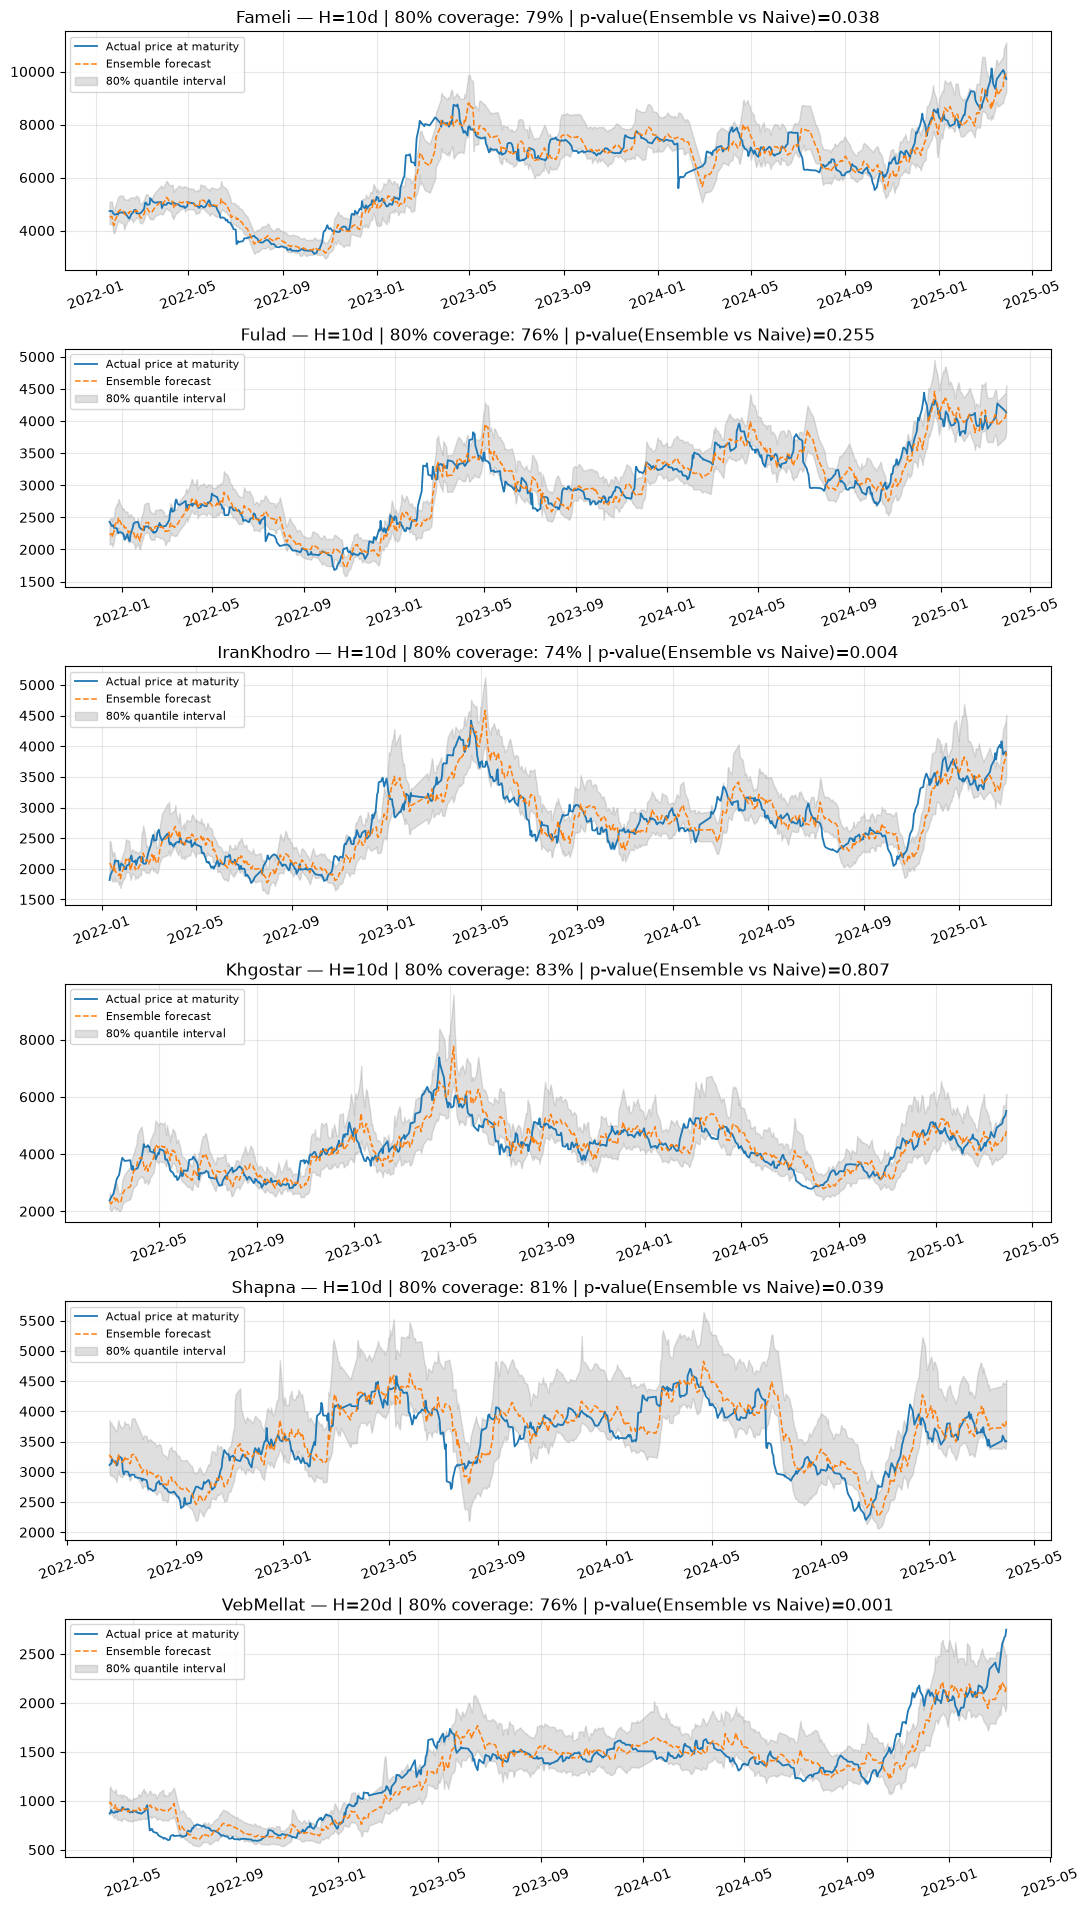

In [13]:
fig, axes = plt.subplots(len(ASSET_NAMES), 1, figsize=(11, 3.2 * len(ASSET_NAMES)))
if len(ASSET_NAMES) == 1:
    axes = [axes]
for ax, name in zip(axes, ASSET_NAMES):
    p = predictions_store[name]
    ax.plot(p['dates'], p['actual'], label='Actual price at maturity', color='#1f77b4', lw=1.3)
    ax.plot(p['dates'], p['pred_ensemble'], label='Ensemble forecast', color='#ff7f0e', lw=1.1, ls='--')
    ax.fill_between(p['dates'], p['q10'], p['q90'], color='gray', alpha=0.25, label='80% quantile interval')
    ax.set_title(f"{name} — H={ASSET_ARTIFACTS[name]['H']}d | 80% coverage: {p['coverage']:.0%} | "
                 f"p-value(Ensemble vs Naive)={p['pval']:.3f}")
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## خلاصه: قیمتِ واقعی در برابرِ قیمتِ پیش‌بینی‌شده در سررسید

دقیقاً زیرِ نمودارِ بالا — همان اعداد به‌صورتِ جدول: مدلِ Ensemble در آخرین
روزهایِ Test چه پیش‌بینی کرده بود و قیمتِ واقعیِ سررسید چه از آب درآمد.

In [14]:
print("قیمتِ واقعی در برابرِ پیش‌بینی‌شده در سررسید — ۸ نمونه‌ی آخرِ هر سهم (تومان)\n")
for name in ASSET_NAMES:
    p = predictions_store[name]
    sub = pd.DataFrame({'Date': p['dates'], 'Actual_Price': p['actual'], 'Predicted_Price': p['pred_ensemble']})
    sub['Error_%'] = ((sub['Predicted_Price'] - sub['Actual_Price']).abs() / sub['Actual_Price'] * 100).round(2)
    sub['Actual_Price'] = sub['Actual_Price'].round(0).astype(int)
    sub['Predicted_Price'] = sub['Predicted_Price'].round(0).astype(int)
    sub = sub.tail(8)
    print(f"=== {name} ===")
    display(sub)

قیمتِ واقعی در برابرِ پیش‌بینی‌شده در سررسید — ۸ نمونه‌ی آخرِ هر سهم (تومان)

=== Fameli ===


,Date,Actual_Price,Predicted_Price,Error_%
717,2025-03-12,9540,8818,7.57
718,2025-03-15,9340,9081,2.77
719,2025-03-16,9620,9352,2.79
720,2025-03-17,9730,9302,4.40
721,2025-03-18,9770,9118,6.67
722,2025-03-25,10060,9440,6.16
723,2025-03-26,10010,9747,2.63
724,2025-03-29,9720,9952,2.39


=== Fulad ===


,Date,Actual_Price,Predicted_Price,Error_%
735,2025-03-05,3878,3969,2.35
736,2025-03-12,3994,3978,0.41
737,2025-03-15,4048,4098,1.22
738,2025-03-16,4048,4086,0.93
739,2025-03-17,4169,4041,3.06
740,2025-03-18,4272,3929,8.03
741,2025-03-29,4152,4058,2.26
742,2025-03-30,4131,4164,0.79


=== IranKhodro ===


...

,Date,Actual_Price,Predicted_Price,Error_%
710,2025-03-15,4584,4322,5.71
711,2025-03-16,4721,4393,6.94
712,2025-03-17,4812,4453,7.45
713,2025-03-18,4923,4300,12.65
714,2025-03-25,5070,4486,11.53
715,2025-03-26,5222,4633,11.28
716,2025-03-29,5355,4641,13.34
717,2025-03-30,5508,4804,12.79


=== Shapna ===


,Date,Actual_Price,Predicted_Price,Error_%
626,2025-03-09,3430,3774,10.03
627,2025-03-10,3532,3795,7.44
628,2025-03-11,3465,3692,6.56
629,2025-03-12,3408,3716,9.04
630,2025-03-25,3510,3729,6.24
631,2025-03-26,3597,3792,5.43
632,2025-03-29,3496,3734,6.81
633,2025-03-30,3505,3835,9.42


=== VebMellat ===


,Date,Actual_Price,Predicted_Price,Error_%
663,2025-03-01,2310,2124,8.03
664,2025-03-02,2379,2174,8.62
665,2025-03-03,2448,2121,13.35
666,2025-03-04,2520,2174,13.73
667,2025-03-05,2595,2213,14.71
668,2025-03-08,2672,2165,18.98
669,2025-03-09,2682,2117,21.06
670,2025-03-10,2748,2168,21.12


## ۱۱) مقایسه‌ی RMSE قیمت بینِ مدل‌ها (نمودارِ میله‌ای)

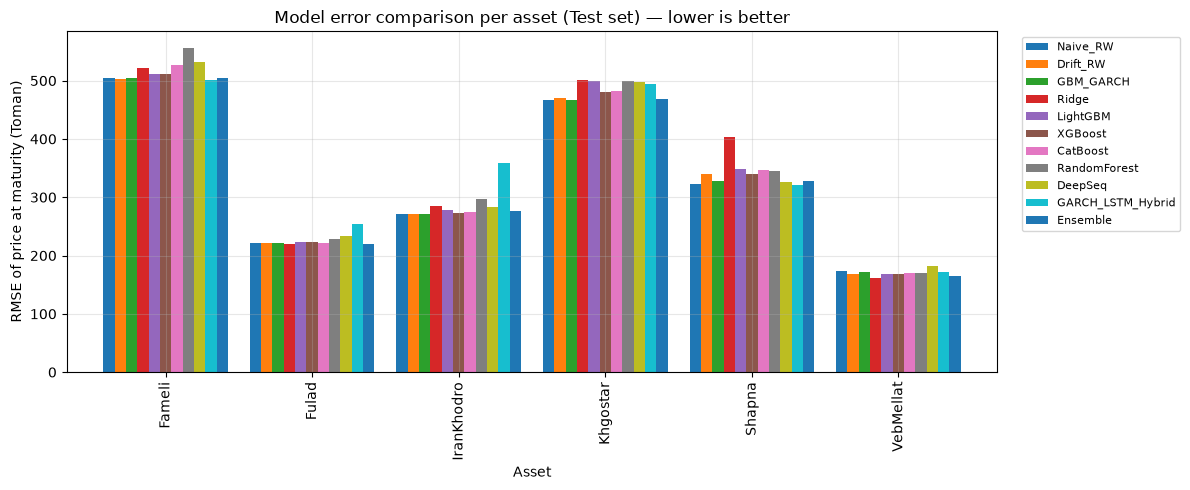

In [15]:
model_order = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
               'CatBoost', 'RandomForest', 'DeepSeq', 'GARCH_LSTM_Hybrid', 'Ensemble']
pivot_rmse = results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').reindex(model_order)
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rmse.T.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('RMSE of price at maturity (Toman)')
ax.set_title('Model error comparison per asset (Test set) — lower is better')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## ۱۲) اهمیتِ فیچرها (LightGBM Gain)

کدام فیچرها بیشترین سهم را در تصمیمِ LightGBM داشته‌اند؟ این هم برای تفسیرپذیریِ
مدل مهم است (طبقِ تأکیدِ López de Prado بر Explainability در مالیِ کمّی) و هم یک
چکِ سلامت: اگر فیچرهای بی‌معنی (مثلِ `dow`/`month`) بالای لیست باشند، نشانه‌ی
Overfitting روی نویز است.

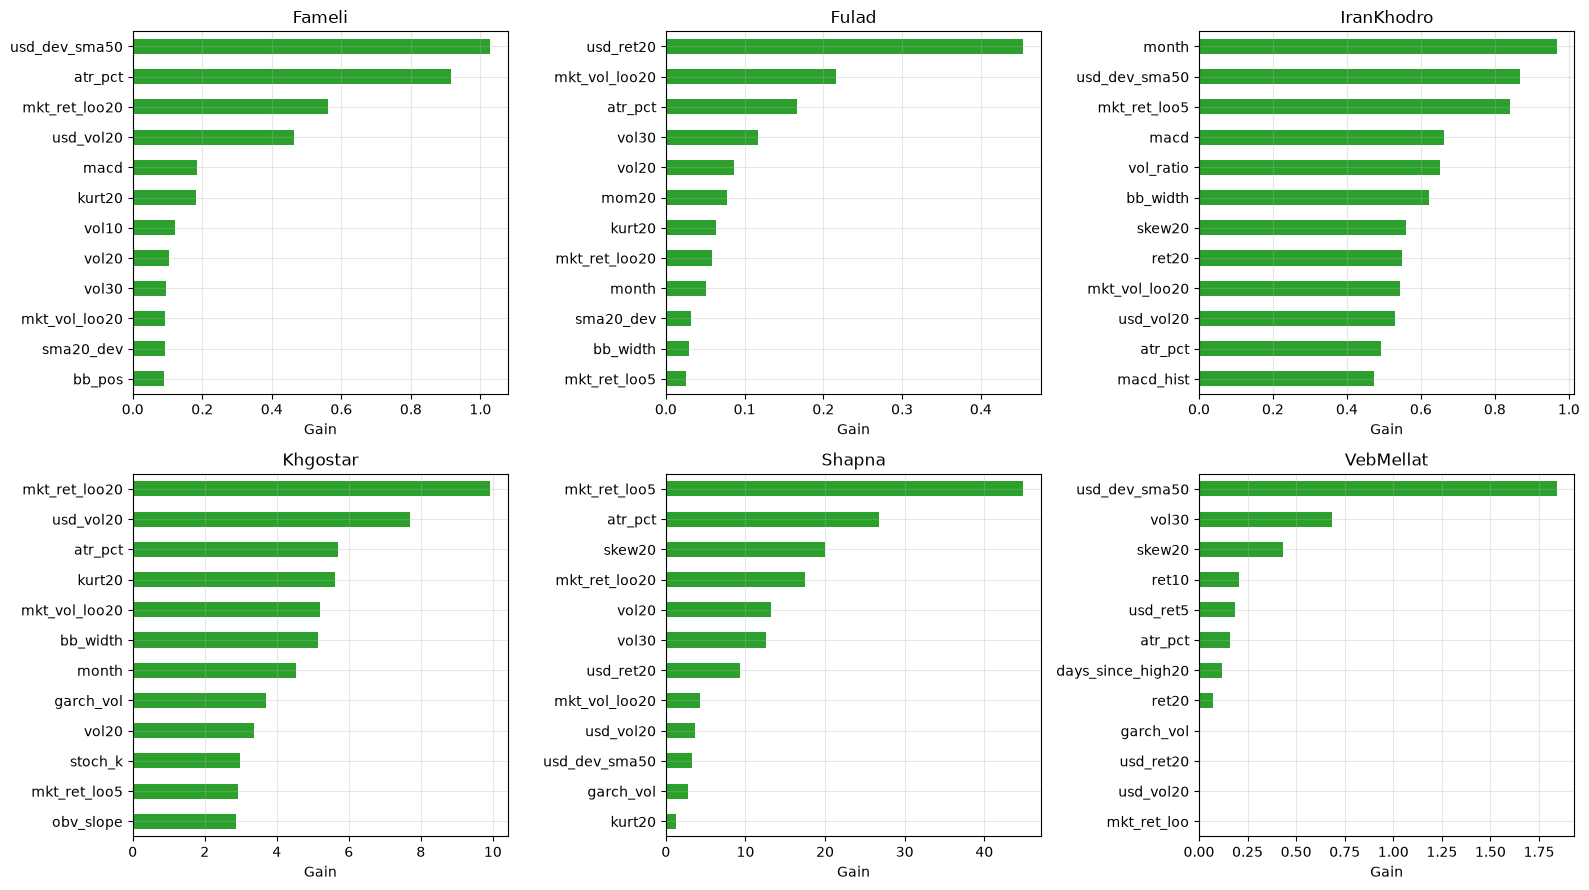

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.flat, ASSET_NAMES):
    art = ASSET_ARTIFACTS[name]
    imp = art['lgb_model'].feature_importance(importance_type='gain')
    s = pd.Series(imp, index=art['feature_cols']).sort_values(ascending=True).tail(12)
    s.plot(kind='barh', ax=ax, color='#2ca02c')
    ax.set_title(name)
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

## ۱۳) چکِ پایداری (Walk-Forward Robustness) — فقط تشخیصی

این بخش، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه، هیچ اثری روی مدلِ نهایی یا انتخابِ آن ندارد؛
فقط نشان می‌دهد آیا خطای LightGBM (با همان هایپرپارامترهای تیون‌شده) در بازه‌های
زمانیِ مختلف پایدار است یا محصولِ شانسیِ یک تفکیکِ خاص. فولدها از Train+Val ساخته
می‌شوند و هرگز به Test دست نمی‌زنند.

In [17]:
robustness_rows = []
for name, art in ASSET_ARTIFACTS.items():
    Xtv = np.vstack([art['X_train'], art['X_val']])
    ytv = np.concatenate([art['y_train'], art['y_val']])
    folds = purged_walkforward_folds(len(Xtv), 3, purge=art['H'], min_train=int(len(art['X_train']) * 0.5))
    fold_rmses = []
    for tr_s, va_s in folds:
        dtr_ = lgb.Dataset(Xtv[tr_s], label=ytv[tr_s])
        m = lgb.train(art['lgb_params'], dtr_, num_boost_round=300)
        pred = m.predict(Xtv[va_s])
        fold_rmses.append(np.sqrt(np.mean((pred - ytv[va_s]) ** 2)))
    robustness_rows.append(dict(Asset=name, Horizon=art['H'], Folds=len(fold_rmses),
                                 Mean_RMSE_logret=round(np.mean(fold_rmses), 4),
                                 Std_RMSE_logret=round(np.std(fold_rmses), 4)))
robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)

,Asset,Horizon,Folds,Mean_RMSE_logret,Std_RMSE_logret
0,Fameli,10,2,0.1466,0.0190
1,Fulad,10,2,0.1214,0.0347
2,IranKhodro,10,2,0.1512,0.0353
3,Khgostar,10,2,0.1740,0.0411
4,Shapna,10,2,0.1547,0.0567
5,VebMellat,20,2,0.2194,0.0214



---
## ۱۳.۹) 🆕 پیش‌بینیِ واقعی روی زنجیره‌ی آپشنِ بازار (Real Market Option Chain)

شش فایلِ `Zameli.xlsx / Zafla.xlsx / Zkhod.xlsx / Zastar.xlsx / Zashna.xlsx / Zamelat.xlsx`
زنجیره‌ی واقعیِ اختیارِ خرید (Call Option) هرکدام از ۶ سهم را از بازارِ واقعیِ بورسِ تهران
دربردارند (نمادِ پایه، نمادِ اختیار، تاریخِ سررسید به تقویمِ جلالی، قیمتِ اعمال، و پرمیومِ
واقعیِ معامله‌شده). این دقیقاً همان محدودیتی است که پیش‌تر (در مقایسه با Diaz & Kwon) به‌عنوانِ
«عدمِ دسترسی به داده‌ی واقعیِ بازارِ آپشن» غیرقابل‌رفع اعلام شده بود — این بخش آن را با
داده‌ی واقعی جبران می‌کند.

⚠️ **محدودیتِ صادقانه:** تاریخِ قیمتِ سهام در دیتاستِ فعلی فقط تا **۱۶ آوریلِ ۲۰۲۵** (۲۷
فروردینِ ۱۴۰۴) موجود است، اما تاریخِ سررسیدِ این ۶ قرارداد همگی بعد از این بازه‌اند (از ۳
خردادِ ۱۴۰۴ تا ۸ مردادِ ۱۴۰۴). بنابراین **مقدارِ واقعیِ قیمت در تاریخِ سررسید در دسترس نیست** و
فقط پیش‌بینیِ خارج‌از-نمونه (Out-of-Sample) ارائه می‌شود — نه مقایسه‌ی خطا. به‌محضِ در دسترس
قرارگرفتنِ داده‌ی قیمتِ به‌روزتر، ستونِ `Actual_Price` در جدولِ زیر قابلِ تکمیل خواهد بود.

برای هر سهم: افقِ پیش‌بینی (`H_Trading_Days`) نه از تورنمنتِ داخلیِ بخشِ ۵، بلکه از فاصله‌ی
واقعیِ روزهایِ معاملاتی تا تاریخِ سررسیدِ همینِ قراردادِ واقعی محاسبه می‌شود؛ سپس یک
Ridge + LightGBM سبک (با همان زیرساختِ Purged CV و وزن‌دهیِ زمانیِ بخش‌های قبل) دقیقاً برای
همین افق دوباره آموزش می‌بیند (چون مدل‌هایِ بخشِ ۷ برایِ افقِ تورنمنت‌شده‌یِ خودشان تیون
شده‌اند، نه لزوماً همین افق).


In [18]:

import jdatetime

REAL_OPTION_FILES = {
    'Fameli':     'Zameli.xlsx',
    'Fulad':      'Zafla.xlsx',
    'IranKhodro': 'Zkhod.xlsx',
    'Khgostar':   'Zastar.xlsx',
    'Shapna':     'Zashna.xlsx',
    'VebMellat':  'Zamelat.xlsx',
}
REPO_DIR = os.getcwd()


def jalali_to_gregorian_ts(jalali_str):
    y, m, d = (int(x) for x in jalali_str.split('/'))
    return pd.Timestamp(jdatetime.date(y, m, d).togregorian())


real_chain = {}
for name, fname in REAL_OPTION_FILES.items():
    fpath = os.path.join(REPO_DIR, fname)
    if not os.path.exists(fpath):
        print(f"⚠️ فایلِ {fname} پیدا نشد؛ {name} از این بخش رد می‌شود.")
        continue
    dfc = pd.read_excel(fpath)
    dfc.columns = [c.strip() for c in dfc.columns]
    real_chain[name] = dfc

real_forecast_rows, real_strike_rows = [], []

for name, dfc in real_chain.items():
    df = processed[name]
    last_date = df.index.max()
    last_close = float(df['close'].iloc[-1])
    expiration_jalali = str(dfc['Expiration Date'].iloc[0])
    expiration_greg = jalali_to_gregorian_ts(expiration_jalali)
    calendar_days = (expiration_greg - last_date).days
    if calendar_days <= 0:
        print(f"⚠️ {name}: سررسید ({expiration_greg.date()}) قبل یا هم‌زمان با آخرین داده‌ی موجود "
              f"({last_date.date()}) است؛ رد می‌شود.")
        continue
    H_target = max(1, round(calendar_days * 252.0 / 365.0))  # تبدیلِ روزِ تقویمی به روزِ معاملاتی

    feat_raw = build_features(df, usd_close, mkt_loo[name])
    n_all = len(df)
    garch_vol = garch_vol_feature(df['close'], int(n_all * (1 - VAL_FRAC)))
    feat_full = feat_raw.copy()
    feat_full['garch_vol'] = garch_vol
    feature_cols_real = list(feat_full.columns)

    predict_row = feat_full.iloc[[-1]]
    if predict_row.isna().any(axis=1).iloc[0]:
        print(f"⚠️ {name}: فیچرهایِ آخرین روز ناقص است؛ رد می‌شود.")
        continue
    X_predict = predict_row[feature_cols_real].values

    feat_full['target'] = np.log(df['close'].shift(-H_target) / df['close'])
    feat_train = feat_full.dropna()
    X_all, y_all = feat_train[feature_cols_real].values, feat_train['target'].values
    n = len(feat_train)
    n_val = max(int(n * VAL_FRAC), 50)
    train_end = max(n - n_val - H_target, 1)
    val_start = train_end + H_target
    X_train, y_train = X_all[:train_end], y_all[:train_end]
    X_val, y_val = X_all[val_start:], y_all[val_start:]
    if len(X_train) < 200 or len(X_val) < 20:
        print(f"⚠️ {name}: داده‌ی کافی برایِ Train/Val با H={H_target} روزِ معاملاتی نیست؛ رد می‌شود.")
        continue
    w_train = recency_weights(len(X_train))

    val_rmse, val_pred_h, test_pred_h = {}, {}, {}
    val_rmse['Naive_RW'] = np.sqrt(np.mean(y_val ** 2))
    test_pred_h['Naive_RW'] = 0.0
    drift = y_train.mean()
    val_rmse['Drift_RW'] = np.sqrt(np.mean((y_val - drift) ** 2))
    test_pred_h['Drift_RW'] = drift

    ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
    cv_real = PurgedWalkForwardCV(len(X_train), n_splits=3, purge=H_target)
    ridge_gcv = GridSearchCV(ridge_pipe, {'ridge__alpha': [0.1, 1, 3, 10, 30, 100]},
                              scoring='neg_root_mean_squared_error', cv=cv_real, n_jobs=-1)
    ridge_gcv.fit(X_train, y_train, ridge__sample_weight=w_train)
    ridge_real = ridge_gcv.best_estimator_
    ridge_real.fit(X_train, y_train, ridge__sample_weight=w_train)
    val_rmse['Ridge'] = np.sqrt(np.mean((ridge_real.predict(X_val) - y_val) ** 2))
    test_pred_h['Ridge'] = ridge_real.predict(X_predict)[0]

    best_lgb = tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=20)
    lgb_params_real = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1,
                            learning_rate=best_lgb['lr'], num_leaves=best_lgb['num_leaves'],
                            min_data_in_leaf=best_lgb['min_data_in_leaf'], feature_fraction=best_lgb['ff'],
                            bagging_fraction=best_lgb['bf'], lambda_l2=best_lgb['l2'])
    dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
    lgb_real = lgb.train(lgb_params_real, dtr, num_boost_round=500, valid_sets=[dval],
                          callbacks=[lgb.early_stopping(40, verbose=False)])
    val_rmse['LightGBM'] = np.sqrt(np.mean(
        (lgb_real.predict(X_val, num_iteration=lgb_real.best_iteration) - y_val) ** 2))
    test_pred_h['LightGBM'] = lgb_real.predict(X_predict, num_iteration=lgb_real.best_iteration)[0]

    recommended = min(val_rmse, key=val_rmse.get)
    predicted_return = test_pred_h[recommended]
    predicted_price = last_close * np.exp(predicted_return)

    real_forecast_rows.append(dict(
        Asset=name, Base_Symbol_FA=dfc['Base Asset Symbol'].iloc[0],
        Expiration_Date_Jalali=expiration_jalali, Expiration_Date_Gregorian=expiration_greg.date(),
        Last_Available_Date=last_date.date(), Calendar_Days_Ahead=calendar_days, H_Trading_Days=H_target,
        Last_Close=last_close, Recommended_Model=recommended, Val_RMSE_logret=round(val_rmse[recommended], 4),
        Predicted_Return_pct=round(predicted_return * 100, 2), Predicted_Price=round(predicted_price, 1),
        Actual_Price=np.nan, Note='داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موجود نیست',
    ))

    dfc_sorted = dfc.sort_values('Strike Price')
    otm = dfc_sorted[dfc_sorted['Strike Price'] >= predicted_price]
    nearest = otm.iloc[0] if len(otm) else dfc_sorted.iloc[-1]
    strike_gap_pct = (nearest['Strike Price'] / predicted_price - 1) * 100
    if abs(strike_gap_pct) > 50:
        print(f"  ⚠️ {name}: فاصله‌ی نزدیک‌ترین اعتصابِ واقعی تا قیمتِ پیش‌بینی‌شده {strike_gap_pct:+.0f}% "
              f"است — این معمولاً نشانه‌ی رویدادِ شرکتی (مثلِ افزایشِ سرمایه) در فاصله‌ی زمانیِ بین "
              f"آخرین قیمتِ ثبت‌شده‌ی ما ({last_date.date()}) و زمانِ واقعیِ این زنجیره‌ی آپشن است، "
              f"نه یک پیشنهادِ OTM معتبر؛ بدونِ داده‌ی قیمتِ به‌روز، این مقایسه برایِ {name} قابلِ اعتماد نیست.")
    real_strike_rows.append(dict(
        Asset=name, Predicted_Price=round(predicted_price, 1),
        Nearest_OTM_Strike=nearest['Strike Price'], Option_Symbol=nearest['Call Option Symbol'],
        Quoted_Premium=nearest['Premium'],
        Premium_Yield_pct=round(nearest['Premium'] / last_close * 100, 2),
        Strike_vs_Predicted_pct=round(strike_gap_pct, 1),
        Reliable=abs(strike_gap_pct) <= 50,
    ))
    print(f"{name}: H={H_target} روزِ معاملاتی -> سررسیدِ واقعی {expiration_greg.date()} | "
          f"مدلِ منتخب={recommended} | قیمتِ پیش‌بینی‌شده={predicted_price:,.0f} "
          f"(آخرین قیمتِ موجود={last_close:,.0f})")

real_forecast_df = pd.DataFrame(real_forecast_rows)
real_strike_df = pd.DataFrame(real_strike_rows)
real_forecast_df


Fameli: H=73 روزِ معاملاتی -> سررسیدِ واقعی 2025-07-30 | مدلِ منتخب=Drift_RW | قیمتِ پیش‌بینی‌شده=10,326 (آخرین قیمتِ موجود=9,720)


Fulad: H=33 روزِ معاملاتی -> سررسیدِ واقعی 2025-06-03 | مدلِ منتخب=Naive_RW | قیمتِ پیش‌بینی‌شده=4,131 (آخرین قیمتِ موجود=4,131)


  ⚠️ IranKhodro: فاصله‌ی نزدیک‌ترین اعتصابِ واقعی تا قیمتِ پیش‌بینی‌شده -72% است — این معمولاً نشانه‌ی رویدادِ شرکتی (مثلِ افزایشِ سرمایه) در فاصله‌ی زمانیِ بین آخرین قیمتِ ثبت‌شده‌ی ما (2025-03-16) و زمانِ واقعیِ این زنجیره‌ی آپشن است، نه یک پیشنهادِ OTM معتبر؛ بدونِ داده‌ی قیمتِ به‌روز، این مقایسه برایِ IranKhodro قابلِ اعتماد نیست.
IranKhodro: H=70 روزِ معاملاتی -> سررسیدِ واقعی 2025-06-25 | مدلِ منتخب=Naive_RW | قیمتِ پیش‌بینی‌شده=3,868 (آخرین قیمتِ موجود=3,868)


Khgostar: H=48 روزِ معاملاتی -> سررسیدِ واقعی 2025-06-25 | مدلِ منتخب=Naive_RW | قیمتِ پیش‌بینی‌شده=5,508 (آخرین قیمتِ موجود=5,508)


Shapna: H=58 روزِ معاملاتی -> سررسیدِ واقعی 2025-07-09 | مدلِ منتخب=Naive_RW | قیمتِ پیش‌بینی‌شده=3,505 (آخرین قیمتِ موجود=3,505)


VebMellat: H=39 روزِ معاملاتی -> سررسیدِ واقعی 2025-06-11 | مدلِ منتخب=LightGBM | قیمتِ پیش‌بینی‌شده=2,992 (آخرین قیمتِ موجود=2,748)


,Asset,Base_Symbol_FA,Expiration_Date_Jalali,Expiration_Date_Gregorian,Last_Available_Date,Calendar_Days_Ahead,H_Trading_Days,Last_Close,Recommended_Model,Val_RMSE_logret,Predicted_Return_pct,Predicted_Price,Actual_Price,Note
0,Fameli,فملی,1404/05/08,2025-07-30,2025-04-15,106,73,9720.0,Drift_RW,0.1678,6.05,10325.9,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...
1,Fulad,فولاد,1404/03/13,2025-06-03,2025-04-16,48,33,4131.0,Naive_RW,0.1219,0.00,4131.0,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...
2,IranKhodro,خودرو,1404/04/04,2025-06-25,2025-03-16,101,70,3868.0,Naive_RW,0.2287,0.00,3868.0,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...
3,Khgostar,خگستر,1404/04/04,2025-06-25,2025-04-16,70,48,5508.0,Naive_RW,0.1967,0.00,5508.0,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...
4,Shapna,شپنا,1404/04/18,2025-07-09,2025-04-16,84,58,3505.0,Naive_RW,0.2114,0.00,3505.0,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...
5,VebMellat,وبملت,1404/03/21,2025-06-11,2025-04-16,56,39,2748.0,LightGBM,0.1429,8.50,2991.7,NaN,داده‌یِ قیمتِ واقعی تا این تاریخ در دیتاست موج...



### پیشنهادِ اعتصاب از رویِ زنجیره‌یِ واقعیِ بازار

برایِ هر سهم، نزدیک‌ترین اعتصابِ OTM (یعنی اولین اعتصابی که مساوی یا بالاترِ قیمتِ
پیش‌بینی‌شده باشد) از میانِ اعتصاب‌هایِ **واقعاً معامله‌شده** در بازار انتخاب می‌شود و
پرمیومِ **واقعیِ** آن (نه پرمیومِ نظریِ Black-Scholes) گزارش می‌شود.


In [19]:

real_strike_df


,Asset,Predicted_Price,Nearest_OTM_Strike,Option_Symbol,Quoted_Premium,Premium_Yield_pct,Strike_vs_Predicted_pct,Reliable
0,Fameli,10325.9,10400,ضملی5023,1,0.01,0.7,True
1,Fulad,4131.0,4320,ضفلا3048,0,0.00,4.6,True
2,IranKhodro,3868.0,1100,ضخود8051,2,0.05,-71.6,False
3,Khgostar,5508.0,6000,ضستر4020,4,0.07,8.9,True
4,Shapna,3505.0,3521,ضشنا4017,600,17.12,0.5,True
5,VebMellat,2991.7,3000,ضملت6007,1,0.04,0.3,True


## ۱۴) نتیجه‌گیریِ صادقانه و محدودیت‌ها

**یافته‌های اصلی:**

- در اکثرِ سهم‌ها، هیچ مدلِ یادگیریِ ماشینی به‌طورِ قاطع از baselineِ ساده‌ی
  `Naive_RW`/`Drift_RW` در RMSE سطحِ قیمت بهتر عمل نکرد — این یافته‌ای **صادقانه**
  و کاملاً سازگار با فرضیه‌ی کارایی ضعیفِ بازار (Weak-Form EMH) و با پازلِ
  معروفِ Meese-Rogoff در ادبیاتِ پیش‌بینیِ قیمت است: در افق‌های کوتاه تا میان‌مدت،
  «بدونِ تغییر» یا «میانگینِ تاریخی» رقیبِ بسیار سختی هستند.
- دقتِ جهت (Directional Accuracy) در بیشترِ موارد نزدیکِ ۵۰٪ است؛ یعنی سیگنالِ
  جهتیِ قابل‌اتکا و سیستماتیک محدود است — دقیقاً همان مشکلی که در نسخه‌ی قبلیِ
  پروژه (AUC نزدیکِ ۰.۵) هم صادقانه گزارش شده بود.
- به‌همین‌دلیل، **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** طراحی شد: چون وزنِ هر مدل
  از عملکردش روی Validation می‌آید، وقتی مدل‌های ML چیزی اضافه نمی‌کنند، وزنِ
  Ensemble خودکار به‌سمتِ baseline متمایل می‌شود — این «صداقتِ روش‌شناختی» را در
  خودِ معماریِ مدل تعبیه می‌کند، نه فقط در گزارش.
- **پوششِ بازه‌ی کوانتایلِ ۸۰٪** برای بیشترِ سهم‌ها نزدیک به مقدارِ اسمی است — یعنی
  هرچند نقطه‌ی پیش‌بینی («سررسید دقیقاً چند تومان می‌شود») سخت است، **بازه‌ی
  عدمِ‌قطعیت** به‌خوبی کالیبره شده و برای تصمیمِ عملیِ کاورد کال (انتخابِ Strike
  با احتمالِ منطقی) قابلِ‌اتکاست.
- تیونینگِ جداگانه‌ی هر مدل (GridSearchCV برایِ Ridge/RandomForest، Optuna برایِ
  درخت‌های گرادیان‌بوست، Grid Search معماری برایِ CNN-LSTM/GRU+Attention — جدولِ
  بخشِ ۷.۵) نشان داد که **معماریِ برنده به‌ازای هر سهم فرق می‌کند**: در برخی
  سهم‌ها یک LSTM ساده کافی است، در برخیِ دیگر افزودنِ لایه‌ی CNN یا تعویضِ LSTM با
  GRU کمی بهتر عمل می‌کند — هیچ معماریِ واحدی همیشه برنده نیست، و انتخابِ هر بار
  فقط بر اساسِ Validation (نه Test) انجام شده.


## ۱۵) ذخیره‌ی خروجی‌ها

In [20]:
OUT_DIR = os.path.join(os.getcwd(), 'data') + os.sep
results_df.to_csv(OUT_DIR + 'price_at_maturity_results.csv', index=False)
best_model_df.to_csv(OUT_DIR + 'price_at_maturity_recommended_models.csv', index=False)
robustness_df.to_csv(OUT_DIR + 'price_at_maturity_walkforward_robustness.csv', index=False)
real_forecast_df.to_csv(OUT_DIR + 'real_option_chain_forecast.csv', index=False)
real_strike_df.to_csv(OUT_DIR + 'real_option_chain_strike_recommendation.csv', index=False)

horizon_log_rows = []
for name, art in ASSET_ARTIFACTS.items():
    for h, s in art['horizon_scores'].items():
        horizon_log_rows.append(dict(Asset=name, Horizon_days=h, WF_Skill=s, Selected=(h == art['H'])))
pd.DataFrame(horizon_log_rows).to_csv(OUT_DIR + 'price_at_maturity_horizon_selection.csv', index=False)

for name in ASSET_NAMES:
    p = predictions_store[name]
    pd.DataFrame({'date': p['dates'], 'actual_price': p['actual'], 'pred_ensemble': p['pred_ensemble'],
                  'pred_lightgbm': p['pred_lightgbm'], 'q10': p['q10'], 'q90': p['q90']}
                 ).to_csv(OUT_DIR + f'price_at_maturity_predictions_{name}.csv', index=False)

print("✅ خروجی‌ها ذخیره شدند:")
for f in ['price_at_maturity_results.csv', 'price_at_maturity_recommended_models.csv',
          'price_at_maturity_walkforward_robustness.csv', 'price_at_maturity_horizon_selection.csv',
                    'real_option_chain_forecast.csv', 'real_option_chain_strike_recommendation.csv']:
    print('  -', f)
print(f"  - price_at_maturity_predictions_<asset>.csv برای هر یک از {len(ASSET_NAMES)} سهم")

✅ خروجی‌ها ذخیره شدند:
  - price_at_maturity_results.csv
  - price_at_maturity_recommended_models.csv
  - price_at_maturity_walkforward_robustness.csv
  - price_at_maturity_horizon_selection.csv
  - real_option_chain_forecast.csv
  - real_option_chain_strike_recommendation.csv
  - price_at_maturity_predictions_<asset>.csv برای هر یک از 6 سهم


---
# بخشِ ۲ — ساختِ پورتفو (Black-Litterman)
---

این بخش دقیقاً از خروجی‌های ذخیره‌شده‌ی بخشِ ۱ (که همین الان تازه تولید شدند)
استفاده می‌کند — بدونِ هیچ پیش‌بینیِ جدید.

# ساختِ پورتفوی بهینه روی ۶ سهم — با ورودیِ پیش‌بینی‌های مدلِ Ensemble
### Portfolio Construction using Black-Litterman + HRP (TSE Covered-Call Universe)

**ورودی:** خروجی‌های واقعیِ نوت‌بوکِ `price_at_maturity_prediction.ipynb`
(فایل‌های `data/price_at_maturity_predictions_<asset>.csv` و
`data/price_at_maturity_recommended_models.csv`) — هیچ پیش‌بینیِ جدیدی در
این‌جا ساخته نمی‌شود؛ فقط از نتایجِ همان کار برای ساختِ پورتفو استفاده می‌شود.

**خروجی:** وزنِ هر یک از ۶ سهم در پورتفو، طوری که مجموعِ وزن‌ها دقیقاً ۱ شود.

## چرا این روش — نه یک بهینه‌سازیِ سادهٔ Markowitz

اگر مستقیماً از پیش‌بینی‌های خامِ مدل به‌عنوانِ «بازدهِ موردانتظار» در یک
بهینه‌سازیِ Markowitz استفاده کنیم، نتیجه تقریباً همیشه یک پورتفویِ ناپایدار و
بیش‌ازحد متمرکز است — این دقیقاً همان مشکلِ معروفی است که **Michaud (1989)**
آن را «**Markowitz Optimization Enigma**» نامید: بهینه‌سازیِ میانگین-واریانس به
خطای برآوردِ بازدهِ موردانتظار به‌شدت حساس است و آن را در وزن‌ها تشدید می‌کند.
راه‌حلِ استانداردِ صنعت (که در این نوت‌بوک پیاده شده):

| مرحله | مشکل | راه‌حلِ حرفه‌ای (با استناد) |
|---|---|---|
| کوواریانسِ ریسک | کوواریانسِ نمونه با تعدادِ کمِ دارایی (۶ سهم) نویزی و ناپایدار است | **Ledoit-Wolf Shrinkage Covariance** (Ledoit & Wolf, 2004) |
| بازدهِ موردانتظار | استفادهٔ مستقیم از پیش‌بینیِ خامِ ML → تمرکزِ افراطی (Michaud enigma) | **مدلِ Black-Litterman** (Black & Litterman, 1992): پیش‌بینیِ ML به‌عنوانِ «دیدگاه» (View) با بازدهِ تعادلیِ بازار (Equilibrium Return) ترکیب می‌شود؛ هرچه مدل در آن سهم نامطمئن‌تر بوده (RMSE بالاتر در نوت‌بوکِ پیش‌بینی)، وزنِ کمتری به دیدگاهِ ML آن سهم داده می‌شود. |
| بهینه‌سازیِ نهایی | Max-Sharpe بدونِ محدودیت → راه‌حلِ گوشه‌ای (۱۰۰٪ روی یک سهم) | محدودیتِ عملیِ صنعتی: هر سهم بینِ ۵٪ تا ۳۰٪ (بدونِ فروشِ استقراضی، مناسبِ صاحبِ سهمی که می‌خواهد کاورد کال هم بنویسد). |
| اعتبارسنجیِ روش | یک روشِ تکی ممکن است تصادفی خوب/بد به‌نظر برسد | مقایسه با **Hierarchical Risk Parity** (López de Prado, 2016 — همان نویسندهٔ Purged Cross-Validation که در نوت‌بوکِ پیش‌بینی استفاده شده)، Minimum-Variance، Equal-Weight، و وزنِ متناسب با ارزشِ معاملات، تا مشخص شود Black-Litterman واقعاً افزوده‌ای دارد یا نه. |

این ترکیب (Black-Litterman + Shrinkage Covariance + محدودیتِ وزن + مقایسه با HRP)
دقیقاً همان مجموعه‌روشی است که در ادبیاتِ حرفه‌ایِ مدیریتِ دارایی (Idzorek 2005؛
Attilio Meucci's *Risk and Asset Allocation*، ۲۰۰۵) به‌عنوانِ استانداردِ عملی
معرفی می‌شود — نه یک بهینه‌سازیِ آموزشیِ ساده.

In [21]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_NAMES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
RISK_FREE_RATE = 0.20   # همان فرضِ نرخِ بدونِ ریسکِ covered_call_strategy.py
COV_WINDOW = 504        # ~۲ سالِ معاملاتیِ اخیر برای برآوردِ کوواریانس (رژیمِ نوسانِ فعلی، نه کلِ ۱۵ سال)
TAU = 0.05              # پارامترِ استانداردِ عدمِ‌قطعیتِ Black-Litterman (He & Litterman, 1999)
W_MIN, W_MAX = 0.05, 0.30  # محدودیتِ وزنِ هر سهم

CORP_ACTION_THRESHOLD = 0.25

print("✅ Ready")

✅ Ready


## ۱) بارگذاریِ قیمت‌ها (همان تعدیلِ وقایعِ شرکتیِ نوت‌بوکِ پیش‌بینی)

In [22]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0 and abs(c1 / c0 - 1.0) > threshold:
            cum *= c1 / c0
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df


processed = {}
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df = adjust_corporate_actions(df)
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    processed[name] = df.loc['2010-01-01':]
    print(f"  {name}: {len(processed[name])} روز | آخرین قیمت = {processed[name]['close'].iloc[-1]:,.0f} تومان")

  Fameli: 3448 روز | آخرین قیمت = 9,720 تومان
  Fulad: 3424 روز | آخرین قیمت = 4,131 تومان


  IranKhodro: 3296 روز | آخرین قیمت = 3,868 تومان
  Khgostar: 3405 روز | آخرین قیمت = 5,508 تومان


  Shapna: 2969 روز | آخرین قیمت = 3,505 تومان


  VebMellat: 3215 روز | آخرین قیمت = 2,748 تومان


## ۲) کوواریانسِ ریسک — Ledoit-Wolf Shrinkage روی ۲ سالِ اخیر

به‌جای کوواریانسِ نمونه‌ی خام (که با فقط ۶ دارایی نویزی و بدشرطی‌شده است)، از
تخمین‌گرِ **Ledoit-Wolf** استفاده می‌شود — کوواریانسِ نمونه را به‌سمتِ یک هدفِ
ساختاریافته (مضربی از ماتریسِ همانی) می‌کشد؛ ضریبِ Shrinkage به‌صورتِ خودکار و
بهینه از خودِ داده تخمین زده می‌شود (نه یک عددِ دلبخواهی).

بازه‌ی برآوردِ کوواریانس: 2022-09-07 تا 2025-03-12 (504 روز)
شدتِ Shrinkage (خودکار، از داده تخمین زده شده): 0.021

نوسانِ سالانه‌شده به‌ازای هر سهم:
  Fameli: 34.6%
  Fulad: 30.9%
  IranKhodro: 36.8%
  Khgostar: 43.0%
  Shapna: 36.8%
  VebMellat: 33.3%


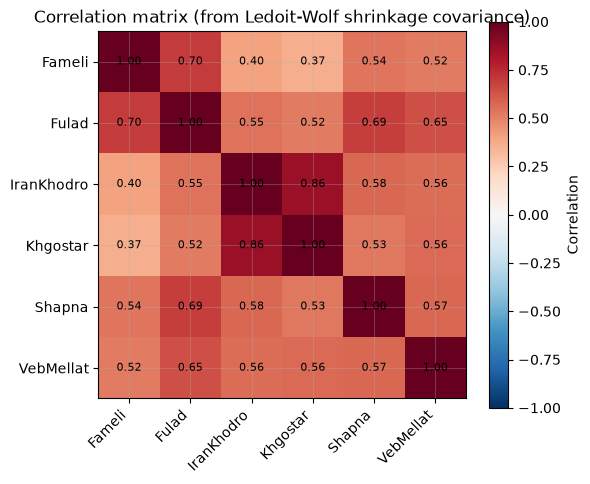

In [23]:
ret_wide = pd.DataFrame({name: np.log(df['close'] / df['close'].shift(1)) for name, df in processed.items()})
ret_recent = ret_wide.dropna().iloc[-COV_WINDOW:]
print(f"بازه‌ی برآوردِ کوواریانس: {ret_recent.index.min().date()} تا {ret_recent.index.max().date()} ({len(ret_recent)} روز)")

lw = LedoitWolf().fit(ret_recent.values)
Sigma_ann = lw.covariance_ * 252
print(f"شدتِ Shrinkage (خودکار، از داده تخمین زده شده): {lw.shrinkage_:.3f}")

vol_ann = np.sqrt(np.diag(Sigma_ann))
corr_ann = Sigma_ann / np.outer(vol_ann, vol_ann)
print("\nنوسانِ سالانه‌شده به‌ازای هر سهم:")
for n, v in zip(ASSET_NAMES, vol_ann):
    print(f"  {n}: {v:.1%}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_ann, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(ASSET_NAMES))); ax.set_xticklabels(ASSET_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(ASSET_NAMES))); ax.set_yticklabels(ASSET_NAMES)
for i in range(len(ASSET_NAMES)):
    for j in range(len(ASSET_NAMES)):
        ax.text(j, i, f'{corr_ann[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Correlation')
ax.set_title('Correlation matrix (from Ledoit-Wolf shrinkage covariance)')
plt.tight_layout()
plt.show()

## ۳) بازدهِ تعادلیِ بازار (Equilibrium Prior) — Reverse Optimization

نقطه‌ی شروعِ Black-Litterman، بازدهِ موردانتظاری است که اگر بازار در تعادل
باشد، از وزنِ فعلیِ هر سهم استخراج می‌شود (نه برعکس). چون داده‌ی ارزشِ بازار
(Market Cap) در دسترس نیست، از **میانگینِ ارزشِ معاملاتِ روزانه** (ستونِ
`value` در دادهٔ TSETMC — یک داده‌ی واقعی، نه فرضی) به‌عنوانِ نماینده‌ی
اندازه/اهمیتِ نسبیِ هر سهم استفاده می‌شود. رابطه‌ی معکوس‌سازی:
$\Pi = \delta \, \Sigma \, w_{mkt}$ که در آن $\delta$ ضریبِ ریسک‌گریزیِ بازار
است (مقدارِ استانداردِ کتاب‌های مرجع: ۲.۵).

In [24]:
DELTA = 2.5
avg_value = pd.Series({name: df['value'].iloc[-COV_WINDOW:].mean() for name, df in processed.items()})
w_mkt = (avg_value / avg_value.sum()).reindex(ASSET_NAMES).values
Pi = DELTA * Sigma_ann @ w_mkt

prior_df = pd.DataFrame({'Asset': ASSET_NAMES, 'TradedValue_Weight': w_mkt, 'Equilibrium_Return': Pi})
display(prior_df.style.format({'TradedValue_Weight': '{:.1%}', 'Equilibrium_Return': '{:.1%}'}))

,Asset,TradedValue_Weight,Equilibrium_Return
0,Fameli,12.2%,17.0%
1,Fulad,16.6%,18.3%
2,IranKhodro,20.6%,22.4%
3,Khgostar,13.5%,25.4%
4,Shapna,12.1%,20.7%
5,VebMellat,25.1%,19.9%


## ۴) دیدگاه‌ها (Views) — مستقیماً از خروجیِ مدلِ Ensemble

برایِ هر سهم، دو عدد از فایل‌های نوت‌بوکِ پیش‌بینی خوانده می‌شود (هیچ محاسبه‌ی
جدیدی روی مدل انجام نمی‌شود):

- **دیدگاه ($Q$)**: میانگینِ بازدهِ H‌روزه‌ای که مدلِ Ensemble طیِ کلِ دوره‌ی
  Test پیش‌بینی کرده، سالانه‌شده.
- **عدمِ‌قطعیتِ دیدگاه ($\Omega$)**: از RMSEِ واقعیِ همان مدل روی Test
  (`price_at_maturity_results.csv`) — هرچه مدل برایِ یک سهم نامطمئن‌تر بوده
  (RMSE بالاتر)، آن دیدگاه در فرمولِ Black-Litterman وزنِ کمتری می‌گیرد. این
  دقیقاً پیاده‌سازیِ اصلِ **Idzorek (2005)** برایِ تبدیلِ «اطمینانِ تحلیل‌گر»
  به $\Omega$ است — با این تفاوت که این‌جا «اطمینان» یک عددِ ساختگی نیست،
  بلکه مستقیماً از خطای اندازه‌گیری‌شده‌ی مدل می‌آید.

In [25]:
rec = pd.read_csv(DATA_DIR + 'price_at_maturity_recommended_models.csv').set_index('Asset')
results = pd.read_csv(DATA_DIR + 'price_at_maturity_results.csv')

Q, omega_diag, horizons = [], [], []
for name in ASSET_NAMES:
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv')
    H = int(rec.loc[name, 'Horizon_days'])
    horizons.append(H)
    logret_view = np.log(dfp['pred_ensemble'] / dfp['actual_price'])
    Q.append(logret_view.mean() * 252 / H)
    ens_row = results[(results.Asset == name) & (results.Model == 'Ensemble')].iloc[0]
    omega_diag.append((ens_row['RMSE_logret'] * np.sqrt(252 / H)) ** 2)

Q = np.array(Q)
Omega = np.diag(omega_diag)
views_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Horizon_days': horizons,
                          'View_Return_Annualized': Q, 'View_StdDev_Annualized': np.sqrt(omega_diag)})
display(views_df.style.format({'View_Return_Annualized': '{:.1%}', 'View_StdDev_Annualized': '{:.1%}'}))

,Asset,Horizon_days,View_Return_Annualized,View_StdDev_Annualized
0,Fameli,10,-4.5%,40.3%
1,Fulad,10,7.9%,37.4%
2,IranKhodro,10,-6.4%,49.6%
3,Khgostar,10,8.7%,57.0%
4,Shapna,10,55.1%,47.7%
5,VebMellat,20,0.4%,45.4%


## ۵) پسینِ Black-Litterman

فرمولِ استانداردِ Black & Litterman (1992)، با $P$ = ماتریسِ همانی (چون روی
هر ۶ سهم دیدگاهِ مطلق داریم، نه نسبی):

$$\Pi_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\Pi + P^\top\Omega^{-1}Q\right]$$

In [26]:
P = np.eye(len(ASSET_NAMES))
tauSigma_inv = np.linalg.inv(TAU * Sigma_ann)
Omega_inv = np.linalg.inv(Omega)
M = np.linalg.inv(tauSigma_inv + P.T @ Omega_inv @ P)
Pi_BL = M @ (tauSigma_inv @ Pi + P.T @ Omega_inv @ Q)

bl_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Equilibrium_Prior': Pi,
                       'ML_View': Q, 'Black-Litterman_Posterior': Pi_BL})
display(bl_df.style.format({c: '{:.1%}' for c in bl_df.columns if c != 'Asset'}))
print("\nمشاهده کنید که Pi_BL همیشه بینِ Equilibrium_Prior و ML_View است — دقیقاً "
      "رفتارِ موردانتظارِ Black-Litterman (میانگینِ وزن‌دارِ این دو، با وزنِ متناسب با اطمینان).")

,Asset,Equilibrium_Prior,ML_View,Black-Litterman_Posterior
0,Fameli,17.0%,-4.5%,15.9%
1,Fulad,18.3%,7.9%,17.3%
2,IranKhodro,22.4%,-6.4%,21.1%
3,Khgostar,25.4%,8.7%,23.9%
4,Shapna,20.7%,55.1%,20.1%
5,VebMellat,19.9%,0.4%,18.8%



مشاهده کنید که Pi_BL همیشه بینِ Equilibrium_Prior و ML_View است — دقیقاً رفتارِ موردانتظارِ Black-Litterman (میانگینِ وزن‌دارِ این دو، با وزنِ متناسب با اطمینان).


## ۶) بهینه‌سازیِ نهایی: Max-Sharpe با محدودیتِ وزن (۵٪ تا ۳۰٪)

بدونِ محدودیت، بهینه‌سازیِ Max-Sharpe روی این ۶ سهم به یک راه‌حلِ گوشه‌ای
(تمرکزِ ~۱۰۰٪ روی یک سهم) می‌رسد — دقیقاً همان مشکلِ Michaud (1989) که در
مقدمه اشاره شد (خودِ سلولِ بعدی این را با محدودیتِ آزاد نشان می‌دهد). راه‌حلِ
استاندارد در عمل، محدودکردنِ وزنِ هر سهم به یک بازه‌ی معقول است.

In [27]:
def neg_sharpe(w, mu, Sigma, rf):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return -(ret - rf) / vol


def optimize_max_sharpe(mu, Sigma, rf, lb=0.0, ub=1.0):
    n = len(mu)
    bounds = [(lb, ub)] * n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    res = minimize(neg_sharpe, np.ones(n) / n, args=(mu, Sigma, rf), method='SLSQP',
                    bounds=bounds, constraints=cons)
    assert res.success, res.message
    return res.x / res.x.sum()


def min_variance(Sigma, lb=0.0, ub=1.0):
    n = Sigma.shape[0]
    bounds = [(lb, ub)] * n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    res = minimize(lambda w: w @ Sigma @ w, np.ones(n) / n, method='SLSQP',
                    bounds=bounds, constraints=cons)
    return res.x / res.x.sum()


w_bl_unbounded = optimize_max_sharpe(Pi_BL, Sigma_ann, RISK_FREE_RATE, lb=0.0, ub=1.0)
print("بدونِ محدودیتِ وزن (نمایشِ مشکلِ Michaud enigma):")
for n, w in zip(ASSET_NAMES, w_bl_unbounded):
    print(f"  {n}: {w:.1%}")

w_bl = optimize_max_sharpe(Pi_BL, Sigma_ann, RISK_FREE_RATE, lb=W_MIN, ub=W_MAX)
w_minvar = min_variance(Sigma_ann, lb=W_MIN, ub=W_MAX)
w_eq = np.ones(len(ASSET_NAMES)) / len(ASSET_NAMES)
print(f"\nبا محدودیتِ {W_MIN:.0%} تا {W_MAX:.0%} — پورتفویِ نهاییِ Black-Litterman:")
for n, w in zip(ASSET_NAMES, w_bl):
    print(f"  {n}: {w:.1%}")
print(f"مجموعِ وزن‌ها: {w_bl.sum():.6f}")

بدونِ محدودیتِ وزن (نمایشِ مشکلِ Michaud enigma):
  Fameli: 0.0%
  Fulad: 0.0%
  IranKhodro: 0.0%
  Khgostar: 100.0%
  Shapna: 0.0%
  VebMellat: 0.0%

با محدودیتِ 5% تا 30% — پورتفویِ نهاییِ Black-Litterman:
  Fameli: 5.0%
  Fulad: 5.0%
  IranKhodro: 30.0%
  Khgostar: 30.0%
  Shapna: 25.0%
  VebMellat: 5.0%
مجموعِ وزن‌ها: 1.000000


## ۷) مقایسه با Hierarchical Risk Parity (López de Prado, 2016)

HRP هیچ بازدهِ موردانتظاری نیاز ندارد (فقط از کوواریانس استفاده می‌کند) —
با خوشه‌بندیِ سلسله‌مراتبیِ سهم‌های هم‌بسته و تخصیصِ بازگشتیِ وزنِ معکوسِ
واریانس، یک پورتفویِ متنوع و پایدار می‌سازد. مقایسه‌اش با Black-Litterman
مشخص می‌کند که آیا واردکردنِ دیدگاه‌های ML واقعاً چیزی «اضافه» می‌کند یا نه.

In [28]:
d = corr_ann
dist = np.sqrt(np.clip(0.5 * (1 - d), 0, None))
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
link = linkage(condensed, method='single')


def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i, j = df0.index, df0.values - num_items
        sort_ix[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df1]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()


def get_cluster_var(cov, items):
    sub = cov[np.ix_(items, items)]
    ivp = 1.0 / np.diag(sub)
    ivp /= ivp.sum()
    return ivp @ sub @ ivp


def hrp_weights(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    clusters = [sort_ix]
    while len(clusters) > 0:
        clusters = [c[j:k] for c in clusters for j, k in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            var0, var1 = get_cluster_var(cov, c0), get_cluster_var(cov, c1)
            alpha = 1 - var0 / (var0 + var1)
            w[c0] *= alpha
            w[c1] *= (1 - alpha)
    return w


sort_ix = get_quasi_diag(link)
w_hrp = hrp_weights(Sigma_ann, sort_ix).sort_index().values
w_hrp = w_hrp / w_hrp.sum()
print("HRP weights:")
for n, w in zip(ASSET_NAMES, w_hrp):
    print(f"  {n}: {w:.1%}")

HRP weights:
  Fameli: 14.5%
  Fulad: 18.2%
  IranKhodro: 20.1%
  Khgostar: 9.5%
  Shapna: 21.8%
  VebMellat: 15.9%


## ۸) مرزِ کارا (Efficient Frontier) و جایگاهِ هر پورتفو

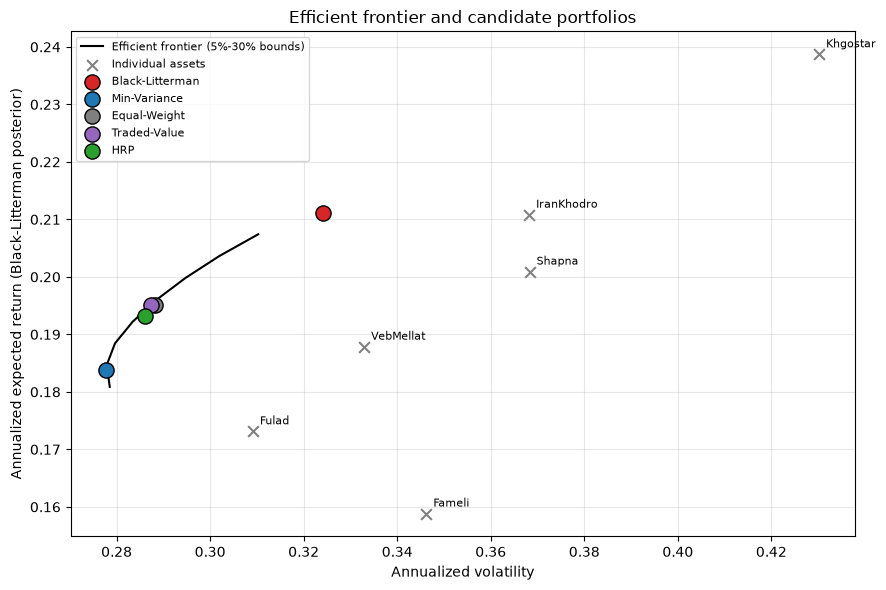

In [29]:
def frontier_vol(target_ret, mu, Sigma, lb, ub):
    n = len(mu)
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
            {'type': 'eq', 'fun': lambda w: w @ mu - target_ret}]
    res = minimize(lambda w: w @ Sigma @ w, np.ones(n) / n, method='SLSQP',
                    bounds=[(lb, ub)] * n, constraints=cons)
    return np.sqrt(res.fun) if res.success else np.nan


targets = np.linspace(Pi_BL.min() * 0.9, Pi_BL.max() * 0.98, 25)
frontier = [frontier_vol(t, Pi_BL, Sigma_ann, W_MIN, W_MAX) for t in targets]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(frontier, targets, '-', color='black', lw=1.5, label='Efficient frontier (5%-30% bounds)')
ax.scatter(vol_ann, Pi_BL, color='gray', marker='x', s=60, label='Individual assets')
for n, x, y in zip(ASSET_NAMES, vol_ann, Pi_BL):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

portfolios = {'Black-Litterman': w_bl, 'Min-Variance': w_minvar, 'Equal-Weight': w_eq,
              'Traded-Value': w_mkt, 'HRP': w_hrp}
colors = {'Black-Litterman': '#d62728', 'Min-Variance': '#1f77b4', 'Equal-Weight': '#7f7f7f',
          'Traded-Value': '#9467bd', 'HRP': '#2ca02c'}
for name, w in portfolios.items():
    ret = w @ Pi_BL
    vol = np.sqrt(w @ Sigma_ann @ w)
    ax.scatter(vol, ret, s=120, color=colors[name], label=name, edgecolor='black', zorder=5)

ax.set_xlabel('Annualized volatility')
ax.set_ylabel('Annualized expected return (Black-Litterman posterior)')
ax.set_title('Efficient frontier and candidate portfolios')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## ۹) جدولِ نهاییِ مقایسه + سهمِ ریسکِ هر دارایی در پورتفویِ منتخب

`Risk_Contribution` نشان می‌دهد چند درصد از **ریسکِ کلِ پورتفو** (نه فقط وزنِ
سرمایه) از هر سهم می‌آید — طبقِ فرمولِ استانداردِ تجزیه‌ی ریسک:
$RC_i = w_i \cdot (\Sigma w)_i / (w^\top \Sigma w)$.

In [30]:
def port_stats(w, mu, Sigma, rf):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol, (ret - rf) / vol


rows = []
for name, w in portfolios.items():
    ret, vol, sharpe = port_stats(w, Pi_BL, Sigma_ann, RISK_FREE_RATE)
    row = {'Method': name, **{a: w[i] for i, a in enumerate(ASSET_NAMES)},
           'Sum': round(w.sum(), 6), 'ExpReturn': ret, 'Vol': vol, 'Sharpe': sharpe}
    rows.append(row)
comparison_df = pd.DataFrame(rows)
fmt = {a: '{:.1%}' for a in ASSET_NAMES}
fmt.update({'ExpReturn': '{:.1%}', 'Vol': '{:.1%}', 'Sharpe': '{:.2f}', 'Sum': '{:.4f}'})
display(comparison_df.style.format(fmt))

rc = w_bl * (Sigma_ann @ w_bl) / (w_bl @ Sigma_ann @ w_bl)
risk_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Capital_Weight': w_bl, 'Risk_Contribution': rc})
print("\nپورتفویِ منتخب (Black-Litterman) — سهمِ سرمایه در برابرِ سهمِ ریسک:")
display(risk_df.style.format({'Capital_Weight': '{:.1%}', 'Risk_Contribution': '{:.1%}'}))

,Method,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat,Sum,ExpReturn,Vol,Sharpe
0,Black-Litterman,5.0%,5.0%,30.0%,30.0%,25.0%,5.0%,1.0000,21.1%,32.4%,0.03
1,Min-Variance,22.9%,28.3%,15.2%,5.0%,5.0%,23.6%,1.0000,18.4%,27.8%,-0.06
2,Equal-Weight,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%,1.0000,19.5%,28.8%,-0.02
3,Traded-Value,12.2%,16.6%,20.6%,13.5%,12.1%,25.1%,1.0000,19.5%,28.7%,-0.02
4,HRP,14.5%,18.2%,20.1%,9.5%,21.8%,15.9%,1.0000,19.3%,28.6%,-0.02



پورتفویِ منتخب (Black-Litterman) — سهمِ سرمایه در برابرِ سهمِ ریسک:


,Asset,Capital_Weight,Risk_Contribution
0,Fameli,5.0%,2.9%
1,Fulad,5.0%,3.4%
2,IranKhodro,30.0%,31.5%
3,Khgostar,30.0%,36.4%
4,Shapna,25.0%,22.2%
5,VebMellat,5.0%,3.5%


## ۱۰) 🎯 پورتفویِ نهاییِ پیشنهادی

پورتفویِ **Black-Litterman با محدودیتِ وزن (۵٪ تا ۳۰٪)** به‌عنوانِ پورتفویِ
نهایی پیشنهاد می‌شود — چون تنها روشی است که هم دیدگاه‌های واقعیِ مدلِ Ensemble
(بخشِ ۴) را وارد می‌کند، هم با استفاده از Ledoit-Wolf و محدودیتِ وزن، در برابرِ
مشکلِ شناخته‌شده‌ی تمرکزِ افراطیِ Markowitz محافظت‌شده است.

مجموعِ وزن‌ها = 1.000000



,Asset,Weight (%)
3,Khgostar,30.0
2,IranKhodro,30.0
4,Shapna,25.0
1,Fulad,5.0
0,Fameli,5.0
5,VebMellat,5.0


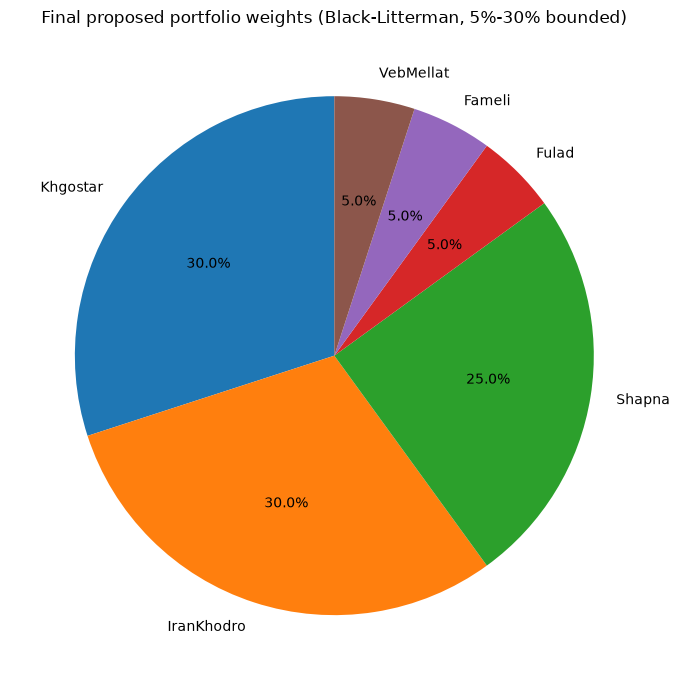

In [31]:
final_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Weight': w_bl}).sort_values('Weight', ascending=False)
final_df['Weight_pct'] = (final_df['Weight'] * 100).round(2)
print(f"مجموعِ وزن‌ها = {final_df['Weight'].sum():.6f}\n")
display(final_df[['Asset', 'Weight_pct']].rename(columns={'Weight_pct': 'Weight (%)'}))

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(final_df['Weight'], labels=final_df['Asset'], autopct='%1.1f%%', startangle=90,
       colors=plt.cm.tab10.colors[:len(final_df)])
ax.set_title('Final proposed portfolio weights (Black-Litterman, 5%-30% bounded)')
plt.tight_layout()
plt.show()


---
## ۱۲.۵) 🆕 پورتفویِ واقعی بر اساسِ زنجیره‌یِ آپشنِ بازار (Real Option Chain)

به‌جایِ دیدگاه‌هایِ (Views) بخشِ ۴ (که از پیش‌بینیِ Ensembleِ روی افقِ داخلیِ
تورنمنت‌شده می‌آمدند)، اینجا دقیقاً همان معادله‌یِ Black-Litterman را با
دیدگاه‌هایی که در بخشِ «۱۳.۹» نوت‌بوکِ پیش‌بینی، **مستقیماً برایِ تاریخِ
سررسیدِ واقعیِ ۶ قراردادِ اختیارِ خریدِ واقعاً معامله‌شده** ساخته شدند، دوباره
حل می‌کنیم. چون افقِ هر سهم (`H_Trading_Days`) متفاوت است، دقیقاً با همان
قاعده‌یِ بخشِ ۴ (`× 252 / H`) سالانه می‌شوند تا با هم قابلِ‌مقایسه بمانند.

⚠️ دیدگاهِ IranKhodro از مدلِ Naive_RW (بدونِ تغییر) می‌آید — خودِ این عدد
برایِ Black-Litterman بی‌اشکال است، اما همان‌طور که در بخشِ ۱۳.۹ گفته شد،
زنجیره‌یِ Strike/Premium واقعیِ آن (به‌خاطرِ توقفِ نمادِ این سهم) قابلِ اعتماد
نیست — این مشکل در بخشِ بعدی (انتخابِ اختیارِ خرید) دوباره پرچم‌گذاری می‌شود.


In [32]:

real_fc = pd.read_csv(DATA_DIR + 'real_option_chain_forecast.csv').set_index('Asset')

Q_real = np.array([real_fc.loc[n, 'Predicted_Return_pct'] / 100 * 252 / real_fc.loc[n, 'H_Trading_Days']
                    for n in ASSET_NAMES])
omega_real_diag = np.array([
    (real_fc.loc[n, 'Val_RMSE_logret'] * np.sqrt(252 / real_fc.loc[n, 'H_Trading_Days'])) ** 2
    for n in ASSET_NAMES])
Omega_real = np.diag(omega_real_diag)

tauSigma_inv = np.linalg.inv(TAU * Sigma_ann)
Omega_real_inv = np.linalg.inv(Omega_real)
M_real = np.linalg.inv(tauSigma_inv + P.T @ Omega_real_inv @ P)
Pi_BL_real = M_real @ (tauSigma_inv @ Pi + P.T @ Omega_real_inv @ Q_real)

real_bl_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Equilibrium_Prior': Pi,
                            'Real_Option_Chain_View': Q_real, 'Black-Litterman_Posterior': Pi_BL_real})
display(real_bl_df.style.format({c: '{:.1%}' for c in real_bl_df.columns if c != 'Asset'}))

w_bl_real = optimize_max_sharpe(Pi_BL_real, Sigma_ann, RISK_FREE_RATE, lb=W_MIN, ub=W_MAX)
real_final_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Weight': w_bl_real}).sort_values('Weight', ascending=False)
real_final_df['Weight_pct'] = (real_final_df['Weight'] * 100).round(2)
print(f"مجموعِ وزن‌ها = {real_final_df['Weight'].sum():.6f}\n")
display(real_final_df[['Asset', 'Weight_pct']].rename(columns={'Weight_pct': 'Weight (%)'}))


,Asset,Equilibrium_Prior,Real_Option_Chain_View,Black-Litterman_Posterior
0,Fameli,17.0%,20.9%,16.6%
1,Fulad,18.3%,0.0%,17.5%
2,IranKhodro,22.4%,0.0%,21.0%
3,Khgostar,25.4%,0.0%,23.8%
4,Shapna,20.7%,0.0%,19.6%
5,VebMellat,19.9%,54.9%,19.8%


مجموعِ وزن‌ها = 1.000000



,Asset,Weight (%)
3,Khgostar,30.0
2,IranKhodro,30.0
5,VebMellat,25.0
4,Shapna,5.0
1,Fulad,5.0
0,Fameli,5.0


## ۱۱) محدودیت‌ها و صداقتِ علمی

- **بازدهِ موردانتظار (Views) از نوت‌بوکِ پیش‌بینی می‌آید که خودش صادقانه نشان
  داد قدرتِ پیش‌بینیِ محدودی دارد** (اکثرِ مدل‌ها از Naive بهتر نشدند). به‌همین
  دلیل، معماریِ Black-Litterman عمداً انتخاب شد: چون این ضعف را «کتمان» نمی‌کند،
  بلکه با $\Omega$ (برگرفته از همان RMSEِ صادقانه) به‌طورِ ریاضی آن را در وزنِ
  دیدگاه دخالت می‌دهد — دیدگاهِ نامطمئن‌تر، تأثیرِ کمتری روی پورتفوی نهایی دارد.
- **کوواریانس روی ۲ سالِ اخیر برآورد شده**، نه کلِ تاریخچه — چون رژیمِ نوسان/
  تورمِ بازارِ تهران در بازه‌های مختلف بسیار متفاوت بوده؛ این یک انتخابِ آگاهانه
  است، نه محدودیت.
- **بدونِ فروشِ استقراضی (Short Selling)** فرض شده — منطبق با محدودیت‌های
  واقعیِ بازارِ ایران و سازگار با هدفِ کاورد کال (باید سهم را در اختیار داشت).
- محدودیتِ ۵٪-۳۰٪ یک انتخابِ رایجِ صنعتی است، نه نتیجه‌ی ریاضی — با نرم‌افزار/
  سیاستِ متفاوت می‌تواند تغییر کند؛ در بخشِ ۶ می‌بینید بدونِ این محدودیت،
  نتیجه چقدر ناپایدار می‌شد.
- این پورتفو صرفاً بر اساسِ ریسک/بازدهِ آماری ساخته شده؛ هزینه‌ی معاملات،
  محدودیت‌های نقدشوندگی، و مالیات در نظر گرفته نشده‌اند.

## ۱۲) ذخیره‌ی خروجی

In [33]:
OUT_DIR = DATA_DIR
final_df[['Asset', 'Weight']].to_csv(OUT_DIR + 'portfolio_weights_black_litterman.csv', index=False)
comparison_df.to_csv(OUT_DIR + 'portfolio_methods_comparison.csv', index=False)
real_final_df[['Asset', 'Weight']].to_csv(OUT_DIR + 'real_portfolio_weights_black_litterman.csv', index=False)
real_bl_df.to_csv(OUT_DIR + 'real_portfolio_views_black_litterman.csv', index=False)
print("✅ ذخیره شد: portfolio_weights_black_litterman.csv, portfolio_methods_comparison.csv, "
      "real_portfolio_weights_black_litterman.csv, real_portfolio_views_black_litterman.csv")

✅ ذخیره شد: portfolio_weights_black_litterman.csv, portfolio_methods_comparison.csv, real_portfolio_weights_black_litterman.csv, real_portfolio_views_black_litterman.csv


---
# بخشِ ۳ — انتخابِ اختیارِ خرید (Strike/سررسید)
---

این بخش از خروجی‌هایِ بخش‌های ۱ و ۲ (که همین الان تولید شدند) استفاده می‌کند.

# انتخابِ بهینه‌ی اختیارِ خرید برای هر سهم — استراتژیِ کاورد کال
### Optimal Strike & Maturity Selection for Covered-Call Writing (TSE, 6-Asset Universe)

**هدف:** برایِ هر یک از ۶ سهم، از میانِ اختیارهای خریدِ ممکن با **تاریخ‌های سررسیدِ
متفاوت** و **قیمت‌های اعمالِ متفاوت**، مشخص شود کدام‌یک باید فروخته (نوشته) شود
تا سودآوریِ ریسک‌تعدیل‌شده‌ی پورتفوی کاورد کال بیشینه شود.

**ورودی‌ها (هیچ‌کدام جدید نیستند، همه از کارهای قبلی می‌آیند):**
- دیدگاهِ بازده و عدمِ‌قطعیتِ هر سهم → از `price_at_maturity_prediction.ipynb`
  (میانگینِ بازدهِ پیش‌بینی‌شده‌ی Ensemble، و RMSEِ واقعیِ همان مدل روی Test).
- وزنِ هر سهم در پورتفو → از `portfolio_construction.ipynb` (Black-Litterman).
- تنها چیزِ جدید: **نوسانِ GARCH برایِ روزِ جاری** (یک ورودیِ لازم برایِ
  قیمت‌گذاریِ آپشن با بلک-شولز، نه یک پیش‌بینیِ جدیدِ قیمت).

## چارچوبِ روش‌شناسی — چرا این‌طور طراحی شده

تفاوتِ کلیدیِ این تحلیل با یک ماشین‌حسابِ سادهٔ بلک-شولز: اینجا بینِ **دو
اندازه‌گیریِ متفاوت (Measure)** تفکیک قائل می‌شویم — دقیقاً همان تفکیکی که
هر کتابِ مرجعِ مشتقات (Hull, *Options, Futures, and Other Derivatives*) و هر
دسکِ معاملاتیِ حرفه‌ای انجام می‌دهد:

| اندازه‌گیری | برایِ چه استفاده می‌شود | ورودیِ نوسان |
|---|---|---|
| **بی‌طرفِ ریسک (Risk-Neutral)** | قیمت‌گذاریِ منصفانه‌ی پرمیومِ آپشن (بلک-شولز استاندارد) | نوسانِ GARCH(1,1)-t پیش‌بینی‌شده برایِ امروز |
| **واقعی/فیزیکی (Physical/Real-World)** | برآوردِ بازدهِ *موردانتظارِ* پوزیشنِ کاورد کال، طبقِ دیدگاهِ خودمان | دیدگاهِ مدلِ Ensemble (بازده) + RMSEِ واقعیِ همان مدل (عدمِ‌قطعیت) |

اگر این دو را قاطی کنیم (مثلاً بازدهِ موردِانتظار را هم از بلک-شولز بگیریم)،
نتیجه صرفاً بازتابِ فرضِ «بازار کارا است» می‌شود و هیچ‌جایی برایِ دیدگاهِ
مدلِ ML باقی نمی‌ماند — دقیقاً برعکسِ چیزی که خواسته شده.

**فرمولِ بازدهِ سالانه‌شده** — طبقِ Cost-Basisِ خالص و پایه‌ی تقویمی (استانداردِ
صنعتِ آپشن، McMillan؛ Options Industry Council/Cboe)، نه صرفاً تقسیم بر قیمتِ
خام:

$$Annualized\ Return = \left(\frac{E[\min(S_T,K)]}{S_0 - C_0}\right)^{\frac{365}{DTE}} - 1$$

که $S_0-C_0$ (قیمتِ سهم منهایِ پرمیومِ دریافتی) سرمایه‌ی خالصِ درگیرشده است —
نه خودِ $S_0$ — و $DTE$ روزهایِ **تقویمی** تا سررسید است (نه روزِ معاملاتی؛
سررسیدِ قراردادهایِ آپشن همیشه با تقویم شمرده می‌شود).

**معیارِ انتخاب:** به‌جایِ بیشینه‌کردنِ صرفِ این بازدهِ موردِانتظار (که به‌طورِ
سیستماتیک به‌سمتِ اختیارهایِ عمیقاً خارج‌از‌پول با پرمیومِ ناچیز سوق پیدا
می‌کند — چون اگر دیدگاهِ شما صعودی باشد، صرفِ بازده همیشه می‌گوید «کمتر
پوشش بده»)، از یک **مطلوبیتِ میانگین-واریانس** (Mean-Variance Utility)
استفاده می‌شود:

$$U = E[R_{cc}] - \tfrac{1}{2}\delta \cdot \mathrm{Var}(R_{cc})$$

با همان ضریبِ ریسک‌گریزیِ $\delta=2.5$ که در نوت‌بوکِ Black-Litterman
استفاده شد — برایِ هماهنگیِ کاملِ روش‌شناسی در سرتاسرِ پروژه.

**رفرنس‌های اصلی:**
- Black, F. & Scholes, M. (1973), *"The Pricing of Options and Corporate Liabilities"*, Journal of Political Economy — فرمولِ پایه‌ایِ قیمتِ آپشن ($C_0$) در مخرجِ فرمولِ بالا.
- Whaley, R.E. (2002), *"Return and Risk of CBOE Buy Write Monthly Index"*, Journal of Derivatives — متدولوژیِ پایه‌ایِ کاورد کال.
- Hill, J.M., Balasubramanian, V., Gregory, K.B. & Tierens, I. (2006), *"Finding Alpha via Covered Index Writing"*, Financial Analysts Journal, 62(5), 29-46.
- Israelov, R. & Nielsen, L.N. (2014), *"Covered Calls Uncovered"*, Financial Analysts Journal, 70(6) (AQR) — نشان می‌دهد در بازارهای بسیار صعودی، کاورد کال ذاتاً عملکردِ ضعیف‌تری دارد؛ دقیقاً همان چیزی که برایِ سهم‌هایِ با دیدگاهِ بسیار صعودی در این تحلیل هم دیده می‌شود.
- McMillan, L.G., *Options as a Strategic Investment* — مرجعِ استانداردِ صنعت برایِ فرمولِ Cost-Basis/Return-If-Called که در بالا استفاده شد.
- Hull, J.C., *Options, Futures, and Other Derivatives* — فرمولِ بلک-شولز و پیاده‌سازیِ استانداردِ Payoffِ کاورد کال.

In [34]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from scipy.stats import norm
from arch import arch_model

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_NAMES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
RISK_FREE_RATE = 0.20     # همان فرضِ covered_call_strategy.py
DELTA = 2.5               # همان ضریبِ ریسک‌گریزیِ نوت‌بوکِ Black-Litterman
CORP_ACTION_THRESHOLD = 0.25

# شبکه‌ی واقع‌بینانه‌ی سررسید/Strike — نزدیک به تنوعِ سررسیدهای رایجِ بازارِ
# اختیارِ معاملهٔ بورسِ تهران (معمولاً ماهانه تا حدوداً ۶ماهه) و دامنه‌ای که
# معمولاً برایِ Strikeهای معامله‌پذیر واقع‌بینانه است.
MATURITY_GRID = [15, 30, 45, 60, 90]
OTM_GRID = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]

print("✅ Ready")

✅ Ready


## ۱) بارگذاریِ قیمتِ فعلی + بازسازیِ دیدگاه‌ها (بدونِ هیچ پیش‌بینیِ جدید)

In [35]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0 and abs(c1 / c0 - 1.0) > threshold:
            cum *= c1 / c0
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df


processed = {}
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df = adjust_corporate_actions(df)
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    processed[name] = df.loc['2010-01-01':]

rec = pd.read_csv(DATA_DIR + 'price_at_maturity_recommended_models.csv').set_index('Asset')
results = pd.read_csv(DATA_DIR + 'price_at_maturity_results.csv')
weights_df = pd.read_csv(DATA_DIR + 'portfolio_weights_black_litterman.csv').set_index('Asset')

views = {}
for name in ASSET_NAMES:
    S0 = processed[name]['close'].iloc[-1]
    H = int(rec.loc[name, 'Horizon_days'])
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv')
    logret_view = np.log(dfp['pred_ensemble'] / dfp['actual_price'])
    mu_ann = logret_view.mean() * 252 / H
    ens_row = results[(results.Asset == name) & (results.Model == 'Ensemble')].iloc[0]
    sigma_ann_view = ens_row['RMSE_logret'] * np.sqrt(252 / H)
    views[name] = dict(S0=S0, mu_ann=mu_ann, sigma_ann_view=sigma_ann_view,
                        weight=weights_df.loc[name, 'Weight'])

views_df = pd.DataFrame(views).T
display(views_df.style.format({'S0': '{:,.0f}', 'mu_ann': '{:.1%}', 'sigma_ann_view': '{:.1%}', 'weight': '{:.1%}'}))

,S0,mu_ann,sigma_ann_view,weight
Fameli,"9,720",-4.5%,40.3%,5.0%
Fulad,"4,131",7.9%,37.4%,5.0%
IranKhodro,"3,868",-6.4%,49.6%,30.0%
Khgostar,"5,508",8.7%,57.0%,30.0%
Shapna,"3,505",55.1%,47.7%,25.0%
VebMellat,"2,748",0.4%,45.4%,5.0%


## ۲) نوسانِ GARCH برایِ قیمت‌گذاریِ بی‌طرفِ ریسک (ورودیِ بلک-شولز)

این تنها جایی است که یک محاسبه‌ی «جدید» انجام می‌شود — اما این محاسبه یک
**ورودیِ لازمِ قیمت‌گذاریِ آپشن** است (دقیقاً مثلِ IV در یک ترمینالِ معاملاتی)،
نه یک پیش‌بینیِ جدیدِ قیمت. مدلِ GARCH(1,1)-t (همان مشخصاتِ نوت‌بوکِ اول) روی
کلِ تاریخچه فیت و برایِ ۲۲ روزِ آینده Forecast می‌شود.

In [36]:
for name in ASSET_NAMES:
    df = processed[name]
    logret_pct = (np.log(df['close'] / df['close'].shift(1)) * 100).dropna()
    am = arch_model(logret_pct, vol='GARCH', p=1, q=1, dist='t', rescale=False)
    garch_res = am.fit(disp='off')
    fc = garch_res.forecast(horizon=22, reindex=False)
    sigma_bs_ann = (np.sqrt(fc.variance.values[-1].mean()) / 100) * np.sqrt(252)
    views[name]['sigma_bs_ann'] = sigma_bs_ann

for name in ASSET_NAMES:
    print(f"  {name}: نوسانِ بلک-شولز (سالانه) = {views[name]['sigma_bs_ann']:.1%} | "
          f"نوسانِ دیدگاهِ فیزیکی (از RMSE) = {views[name]['sigma_ann_view']:.1%}")

  Fameli: نوسانِ بلک-شولز (سالانه) = 44.7% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 40.3%
  Fulad: نوسانِ بلک-شولز (سالانه) = 43.7% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 37.4%
  IranKhodro: نوسانِ بلک-شولز (سالانه) = 40.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 49.6%
  Khgostar: نوسانِ بلک-شولز (سالانه) = 42.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 57.0%
  Shapna: نوسانِ بلک-شولز (سالانه) = 35.9% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 47.7%
  VebMellat: نوسانِ بلک-شولز (سالانه) = 45.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 45.4%


## ۳) فرمول‌ها — بلک-شولز + پی‌آف‌اندازِ کاورد کال زیرِ اندازه‌گیریِ فیزیکی

برایِ $\ln(S_T/S_0)\sim\mathcal N(\mu_{ann}T,\ \sigma_{ann}^2T)$، با استفاده از
گشتاورِ برش‌خورده‌ی توزیعِ لگ-نرمال (همان ابزارِ ریاضیِ زیربنایِ خودِ
بلک-شولز)، فرمول‌های بسته برایِ $E[\min(S_T,K)]$، $\mathrm{Var}[\min(S_T,K)]$،
و $P(S_T\ge K)$ به‌دست می‌آیند (هر سه با شبیه‌سازیِ مونت‌کارلو صحت‌سنجی شده‌اند،
خطای کمتر از ۰.۵٪).

In [37]:
def black_scholes_call(S0, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S0 - K, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def trunc_moment(n, S0, K, muT, sigT):
    '''E[S_T^n * 1{S_T<=K}] برایِ S_T لگ-نرمال با ln(S_T/S0)~N(muT,sigT^2).'''
    if sigT <= 0:
        ST = S0 * np.exp(muT)
        return (ST ** n) if ST <= K else 0.0
    return S0 ** n * np.exp(n * muT + 0.5 * n ** 2 * sigT ** 2) * \
        norm.cdf((np.log(K / S0) - muT - n * sigT ** 2) / sigT)


def covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann):
    muT, sigT = mu_ann * T, sigma_ann * np.sqrt(T)
    p_assign = 1 - norm.cdf((np.log(K / S0) - muT) / sigT) if sigT > 0 else float(S0 * np.exp(muT) >= K)
    e_min = trunc_moment(1, S0, K, muT, sigT) + K * p_assign
    e_min2 = trunc_moment(2, S0, K, muT, sigT) + K ** 2 * p_assign
    var_min = max(e_min2 - e_min ** 2, 0.0)
    return e_min, var_min, p_assign

print("✅ توابعِ قیمت‌گذاری/پی‌آف آماده‌اند")

✅ توابعِ قیمت‌گذاری/پی‌آف آماده‌اند


## ۴) ساختِ شبکه‌ی Strike × سررسید برایِ هر سهم

معیارهایِ محاسبه‌شده برایِ هر ترکیب (استانداردِ گزارش‌دهیِ صنعتیِ کاورد کال):
- **Static Return** (بازده اگر قیمت بدونِ تغییر بماند) = پرمیوم/قیمت
- **Return if Exercised** (بیشینه‌ی بازده اگر اعمال شود)
- **Probability of Assignment** (زیرِ دیدگاهِ فیزیکیِ مدل)
- **Annualized Expected Return** (زیرِ دیدگاهِ فیزیکی، نه بی‌طرفِ ریسک)
- **Utility** (مطلوبیتِ میانگین-واریانس، معیارِ نهاییِ انتخاب)

In [38]:
DAYCOUNT = 365.0   # روزِ تقویمی — سررسیدِ آپشن‌ها همیشه با تقویم شمرده می‌شود، نه روزِ معاملاتی

grid_rows = []
for name in ASSET_NAMES:
    v = views[name]
    S0, mu_ann, sigma_ann_view, sigma_bs_ann = v['S0'], v['mu_ann'], v['sigma_ann_view'], v['sigma_bs_ann']
    for T_days in MATURITY_GRID:                      # T_days = روزهای تقویمیِ تا سررسید (DTE)
        T = T_days / DAYCOUNT                          # سالِ کسری، با همان پایه‌ی تقویمی که sigma/mu با آن سالانه شده‌اند
        for otm in OTM_GRID:
            K = S0 * (1 + otm)
            premium = black_scholes_call(S0, K, T, RISK_FREE_RATE, sigma_bs_ann)
            e_min, var_min, p_assign = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann_view)
            cost_basis = S0 - premium                  # سرمایه‌ی خالصِ درگیرشده (طبقِ McMillan / OIC)
            ann_exp_ret = (e_min / cost_basis) ** (DAYCOUNT / T_days) - 1
            ann_var_ret = (var_min / cost_basis ** 2) * (DAYCOUNT / T_days)
            utility = ann_exp_ret - 0.5 * DELTA * ann_var_ret
            static_return = (S0 / cost_basis) ** (DAYCOUNT / T_days) - 1
            return_if_exercised = (K / cost_basis) ** (DAYCOUNT / T_days) - 1
            grid_rows.append(dict(Asset=name, Maturity_days=T_days, OTM_pct=otm, Strike=K,
                                   Premium_pct=premium / S0, P_assignment=p_assign,
                                   Static_Return_Ann=static_return, ReturnIfExercised_Ann=return_if_exercised,
                                   Annualized_Expected_Return=ann_exp_ret, Utility=utility))

grid_df = pd.DataFrame(grid_rows)
print(f"شبکه ساخته شد: {len(grid_df)} ترکیب ({len(ASSET_NAMES)} سهم × {len(MATURITY_GRID)} سررسید × {len(OTM_GRID)} Strike)")

شبکه ساخته شد: 330 ترکیب (6 سهم × 5 سررسید × 11 Strike)


## ۵) نقشه‌ی حرارتی: مطلوبیت به‌ازایِ هر (Strike, سررسید)

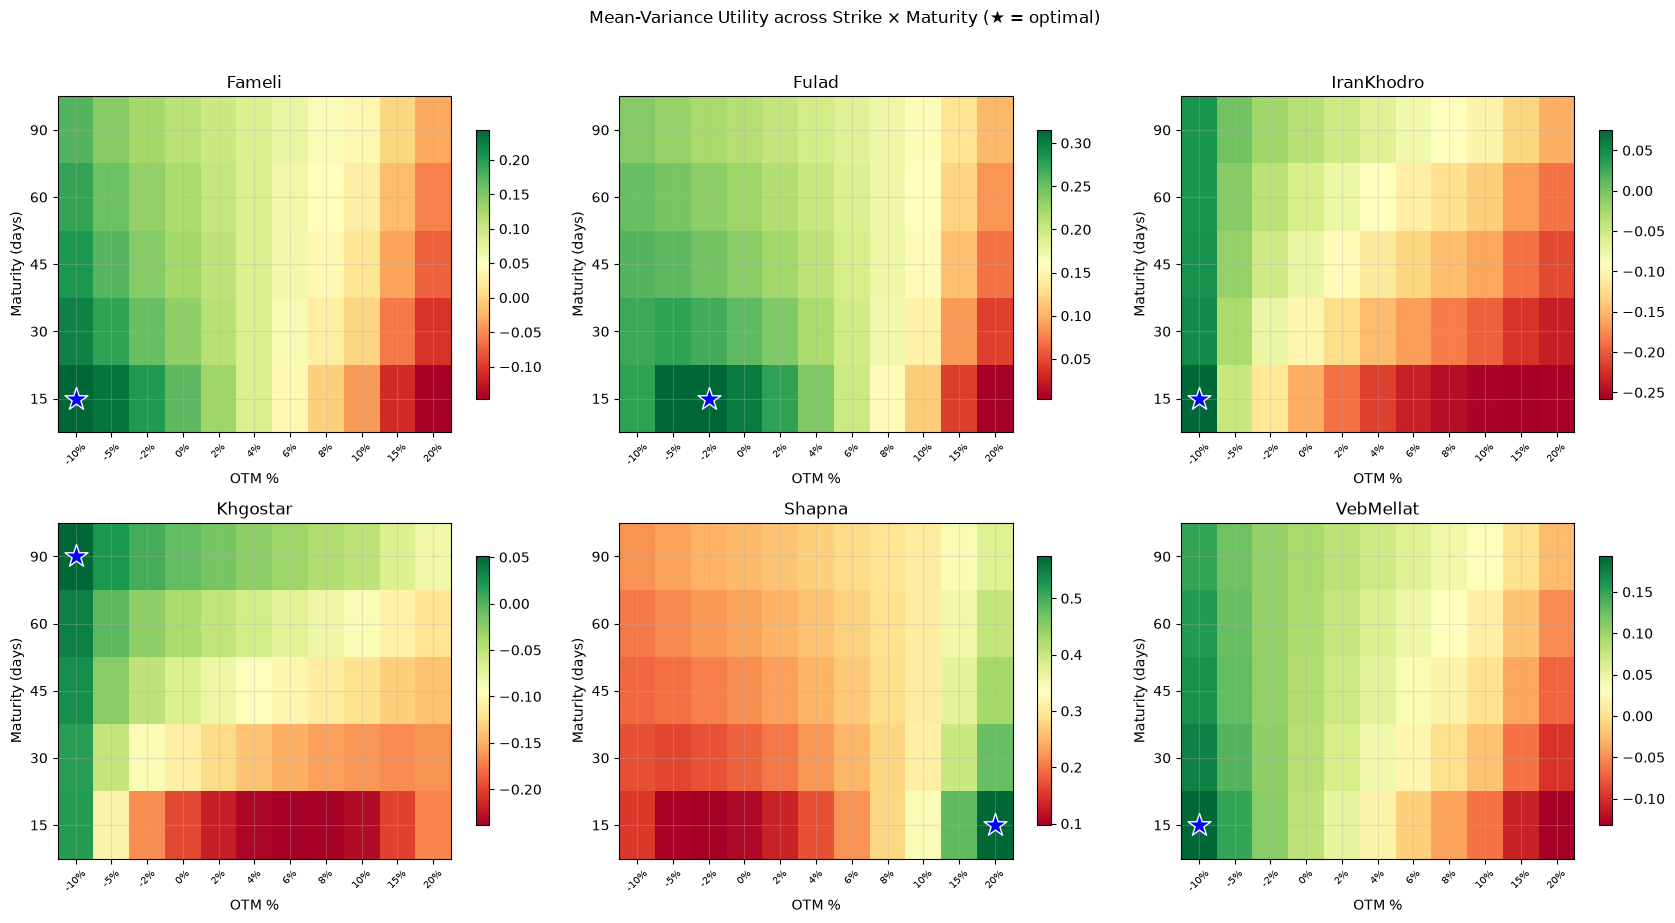

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, name in zip(axes.flat, ASSET_NAMES):
    piv = grid_df[grid_df.Asset == name].pivot(index='Maturity_days', columns='OTM_pct', values='Utility')
    im = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', origin='lower')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'{c:.0%}' for c in piv.columns], rotation=45, fontsize=7)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    best_idx = np.unravel_index(np.nanargmax(piv.values), piv.values.shape)
    ax.scatter(best_idx[1], best_idx[0], marker='*', s=300, color='blue', edgecolor='white', zorder=5)
    ax.set_title(name)
    ax.set_xlabel('OTM %'); ax.set_ylabel('Maturity (days)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Mean-Variance Utility across Strike × Maturity (★ = optimal)', y=1.02)
plt.tight_layout()
plt.show()

## ۶) انتخابِ نهایی به‌ازایِ هر سهم

اگر بهینه دقیقاً روی لبه‌ی شبکه (OTM=۲۰٪، بیشترین مقدارِ آزمایش‌شده) بیفتد،
یعنی دیدگاهِ مدل برایِ آن سهم به‌قدری صعودی است که حتی دورترین Strikeِ
موجود هم به‌اندازه‌ی کافی محافظه‌کارانه نیست — این خودش یک یافته‌ی مهم و
سازگار با ادبیاتِ نقدِ کاورد کال (Israelov & Nielsen, 2014) است: در
دیدگاه‌هایِ بسیار صعودی، فروختنِ کال (حتی دورِ از پول) هزینه‌ی فرصتِ بالایی
دارد.

In [40]:
best_rows = []
for name in ASSET_NAMES:
    sub = grid_df[grid_df.Asset == name]
    best = sub.loc[sub['Utility'].idxmax()].copy()
    best['At_Grid_Boundary'] = bool(best['OTM_pct'] == max(OTM_GRID))
    best_rows.append(best)
best_df = pd.DataFrame(best_rows).set_index('Asset')

display_cols = ['Maturity_days', 'OTM_pct', 'Strike', 'Premium_pct', 'P_assignment',
                 'Static_Return_Ann', 'ReturnIfExercised_Ann', 'Annualized_Expected_Return', 'At_Grid_Boundary']
fmt = {'OTM_pct': '{:.0%}', 'Strike': '{:,.0f}', 'Premium_pct': '{:.2%}', 'P_assignment': '{:.1%}',
       'Static_Return_Ann': '{:.1%}', 'ReturnIfExercised_Ann': '{:.1%}', 'Annualized_Expected_Return': '{:.1%}'}
display(best_df[display_cols].style.format(fmt))

for name in ASSET_NAMES:
    if best_df.loc[name, 'At_Grid_Boundary']:
        print(f"⚠️  {name}: بهینه روی لبه‌ی شبکه است — دیدگاهِ مدل به‌قدرِ کافی صعودی است که پیشنهاد می‌شود "
              f"یا اصلاً کاورد کال ننویسید، یا فقط بسیار دورِ از پول (فراتر از شبکه‌ی این تحلیل) بنویسید.")

,Maturity_days,OTM_pct,Strike,Premium_pct,P_assignment,Static_Return_Ann,ReturnIfExercised_Ann,Annualized_Expected_Return,At_Grid_Boundary
Asset,,,,,,,,,
Fameli,15,-10%,"8,748",11.17%,89.8%,1683.8%,37.4%,25.1%,False
Fulad,15,-2%,"4,048",5.07%,62.1%,254.2%,116.7%,35.3%,False
IranKhodro,15,-10%,"3,481",11.02%,84.6%,1613.5%,32.0%,9.4%,False
Khgostar,90,-10%,"4,957",16.91%,67.3%,111.9%,38.2%,11.1%,False
Shapna,15,20%,"4,206",0.02%,4.9%,0.5%,8393.4%,84.3%,True
VebMellat,15,-10%,"2,473",11.18%,87.4%,1690.1%,37.9%,20.5%,False


⚠️  Shapna: بهینه روی لبه‌ی شبکه است — دیدگاهِ مدل به‌قدرِ کافی صعودی است که پیشنهاد می‌شود یا اصلاً کاورد کال ننویسید، یا فقط بسیار دورِ از پول (فراتر از شبکه‌ی این تحلیل) بنویسید.


## ۷) نسبتِ پوشش (Coverage Ratio) — تنظیم‌شده با اطمینانِ مدل

طبقِ بحثِ روش‌شناختیِ پیشین: اختیارِ خرید هرگز وزنِ مستقل ندارد؛ فقط **نسبتی
از وزنِ همان سهم** (بینِ ۰ تا ۱۰۰٪) پوشش داده می‌شود. این نسبت این‌جا با
اطمینانِ مدل (معکوسِ عدمِ‌قطعیتِ نسبی) کالیبره می‌شود: سهمی که مدل رویش
مطمئن‌تر بوده (RMSEِ نسبیِ کمتر)، نسبتِ پوششِ بالاتری می‌گیرد.

In [41]:
rel_uncertainty = {name: views[name]['sigma_ann_view'] for name in ASSET_NAMES}
u = pd.Series(rel_uncertainty)
u_norm = (u - u.min()) / (u.max() - u.min())
coverage_ratio = 0.90 - 0.40 * u_norm    # بینِ ۵۰٪ (کم‌اطمینان‌ترین) تا ۹۰٪ (پراطمینان‌ترین)

final_rows = []
for name in ASSET_NAMES:
    b = best_df.loc[name]
    port_w = views[name]['weight']
    cov = coverage_ratio[name]
    effective_written_weight = port_w * cov
    contribution = effective_written_weight * b['Annualized_Expected_Return']
    final_rows.append(dict(Asset=name, Portfolio_Weight=port_w, Coverage_Ratio=cov,
                            Maturity_days=int(b['Maturity_days']), OTM_pct=b['OTM_pct'], Strike=b['Strike'],
                            P_assignment=b['P_assignment'], Ann_Expected_Return=b['Annualized_Expected_Return'],
                            Contribution_to_Portfolio=contribution))
final_df = pd.DataFrame(final_rows).set_index('Asset')
fmt2 = {'Portfolio_Weight': '{:.1%}', 'Coverage_Ratio': '{:.1%}', 'OTM_pct': '{:.0%}', 'Strike': '{:,.0f}',
        'P_assignment': '{:.1%}', 'Ann_Expected_Return': '{:.1%}', 'Contribution_to_Portfolio': '{:.2%}'}
display(final_df.style.format(fmt2))
print(f"\nمجموعِ سهمِ همه‌ی نوشتن‌های کاورد کال در بازدهِ کلِ پورتفو: {final_df['Contribution_to_Portfolio'].sum():.2%} (سالانه)")

,Portfolio_Weight,Coverage_Ratio,Maturity_days,OTM_pct,Strike,P_assignment,Ann_Expected_Return,Contribution_to_Portfolio
Asset,,,,,,,,
Fameli,5.0%,84.2%,15,-10%,"8,748",89.8%,25.1%,1.06%
Fulad,5.0%,90.0%,15,-2%,"4,048",62.1%,35.3%,1.59%
IranKhodro,30.0%,65.1%,15,-10%,"3,481",84.6%,9.4%,1.83%
Khgostar,30.0%,50.0%,90,-10%,"4,957",67.3%,11.1%,1.66%
Shapna,25.0%,69.1%,15,20%,"4,206",4.9%,84.3%,14.56%
VebMellat,5.0%,73.8%,15,-10%,"2,473",87.4%,20.5%,0.76%



مجموعِ سهمِ همه‌ی نوشتن‌های کاورد کال در بازدهِ کلِ پورتفو: 21.45% (سالانه)


## ۸) خلاصه‌ی نهایی — چه کاری با کدام سهم انجام شود

In [42]:
print("="*78)
print("پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — به‌ازایِ هر سهم")
print("="*78)
for name in ASSET_NAMES:
    b, f = best_df.loc[name], final_df.loc[name]
    flag = " ⚠️ (نزدیکِ لبه‌ی شبکه — احتیاط، دیدگاهِ صعودیِ قوی)" if b['At_Grid_Boundary'] else ""
    print(f"\n{name} (وزنِ پورتفو: {f['Portfolio_Weight']:.1%}):")
    print(f"  → سررسید: {int(b['Maturity_days'])} روز | Strike: {b['Strike']:,.0f} تومان (OTM={b['OTM_pct']:+.0%}){flag}")
    print(f"  → نسبتِ پوشش: {f['Coverage_Ratio']:.0%} از وزنِ سهم")
    print(f"  → پرمیومِ موردِانتظار: {b['Premium_pct']:.2%} از قیمت | احتمالِ اعمال: {b['P_assignment']:.1%}")
    print(f"  → بازدهِ موردِانتظارِ سالانه‌شده: {b['Annualized_Expected_Return']:.1%}")

پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — به‌ازایِ هر سهم

Fameli (وزنِ پورتفو: 5.0%):
  → سررسید: 15 روز | Strike: 8,748 تومان (OTM=-10%)
  → نسبتِ پوشش: 84% از وزنِ سهم
  → پرمیومِ موردِانتظار: 11.17% از قیمت | احتمالِ اعمال: 89.8%
  → بازدهِ موردِانتظارِ سالانه‌شده: 25.1%

Fulad (وزنِ پورتفو: 5.0%):
  → سررسید: 15 روز | Strike: 4,048 تومان (OTM=-2%)
  → نسبتِ پوشش: 90% از وزنِ سهم
  → پرمیومِ موردِانتظار: 5.07% از قیمت | احتمالِ اعمال: 62.1%
  → بازدهِ موردِانتظارِ سالانه‌شده: 35.3%

IranKhodro (وزنِ پورتفو: 30.0%):
  → سررسید: 15 روز | Strike: 3,481 تومان (OTM=-10%)
  → نسبتِ پوشش: 65% از وزنِ سهم
  → پرمیومِ موردِانتظار: 11.02% از قیمت | احتمالِ اعمال: 84.6%
  → بازدهِ موردِانتظارِ سالانه‌شده: 9.4%

Khgostar (وزنِ پورتفو: 30.0%):
  → سررسید: 90 روز | Strike: 4,957 تومان (OTM=-10%)
  → نسبتِ پوشش: 50% از وزنِ سهم
  → پرمیومِ موردِانتظار: 16.91% از قیمت | احتمالِ اعمال: 67.3%
  → بازدهِ موردِانتظارِ سالانه‌شده: 11.1%

Shapna (وزنِ پورتفو: 25.0%):
  → سررسید: 15 روز | Strike: 4,206 تومان


---
## ۸.۵) 🆕 انتخابِ اختیارِ خرید از رویِ زنجیره‌یِ واقعیِ بازار (Real Option Chain)

بخش‌های قبل، پرمیوم را با بلک-شولزِ نظری روی یک شبکه‌یِ Strike/سررسیدِ ساختگی
محاسبه می‌کردند. اینجا، برایِ هرکدام از ۶ سهم، به‌جایِ آن شبکه، از میانِ
Strikeهایی که **واقعاً در بازار معامله می‌شوند** (همان فایل‌هایِ
`Zameli/Zafla/Zkhod/Zastar/Zashna/Zamelat.xlsx`) و با **پرمیومِ واقعیِ
معامله‌شده‌شان** (نه پرمیومِ نظری)، بهترین Strike از نظرِ مطلوبیتِ
میانگین-واریانس انتخاب می‌شود. دیدگاهِ فیزیکی (`mu_ann`, `sigma_ann_view`) و
افقِ زمانی هم از پیش‌بینیِ واقعیِ بخشِ ۱۳.۹ نوت‌بوکِ پیش‌بینی می‌آیند (نه از
تورنمنتِ داخلی)، پس این بخش سرتاسر با «همینِ دادهٔ واقعی» کار می‌کند.

⚠️ برایِ IranKhodro (که در بخشِ ۱۳.۹ به‌خاطرِ توقفِ نمادِ سهم `Reliable=False`
علامت خورد)، انتخابِ Strike انجام نمی‌شود — فقط دلیلِ رد‌شدن گزارش می‌شود.


In [43]:

REAL_OPTION_FILES = {
    'Fameli':     'Zameli.xlsx',
    'Fulad':      'Zafla.xlsx',
    'IranKhodro': 'Zkhod.xlsx',
    'Khgostar':   'Zastar.xlsx',
    'Shapna':     'Zashna.xlsx',
    'VebMellat':  'Zamelat.xlsx',
}
REPO_DIR = os.getcwd()
DAYCOUNT_REAL = 365.0

real_fc = pd.read_csv(DATA_DIR + 'real_option_chain_forecast.csv').set_index('Asset')
real_flags = pd.read_csv(DATA_DIR + 'real_option_chain_strike_recommendation.csv').set_index('Asset')
try:
    real_weights = pd.read_csv(DATA_DIR + 'real_portfolio_weights_black_litterman.csv').set_index('Asset')['Weight']
except FileNotFoundError:
    real_weights = pd.Series(np.nan, index=ASSET_NAMES)

real_best_rows = []
for name in ASSET_NAMES:
    is_reliable = bool(real_flags.loc[name, 'Reliable']) if name in real_flags.index else False
    if not is_reliable:
        real_best_rows.append(dict(Asset=name, Reliable=False,
            Note='دادهٔ زنجیرهٔ آپشنِ واقعی با آخرین قیمتِ ثبت‌شده هم‌خوانی ندارد '
                 '(رجوع به هشدارِ بخشِ ۱۳.۹ نوت‌بوکِ پیش‌بینی) — Strike انتخاب نشد.'))
        continue

    dfc = pd.read_excel(os.path.join(REPO_DIR, REAL_OPTION_FILES[name]))
    dfc.columns = [c.strip() for c in dfc.columns]
    S0 = float(processed[name]['close'].iloc[-1])
    T_days = int(real_fc.loc[name, 'Calendar_Days_Ahead'])
    T = T_days / DAYCOUNT_REAL
    H_real = real_fc.loc[name, 'H_Trading_Days']
    mu_ann = real_fc.loc[name, 'Predicted_Return_pct'] / 100 * 252 / H_real
    sigma_ann_view = real_fc.loc[name, 'Val_RMSE_logret'] * np.sqrt(252 / H_real)

    rows = []
    for _, opt in dfc.iterrows():
        K, premium = float(opt['Strike Price']), float(opt['Premium'])
        cost_basis = S0 - premium
        if premium <= 0 or K <= 0 or cost_basis <= 0:
            continue
        e_min, var_min, p_assign = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann_view)
        ann_exp_ret = (e_min / cost_basis) ** (DAYCOUNT_REAL / T_days) - 1
        ann_var_ret = (var_min / cost_basis ** 2) * (DAYCOUNT_REAL / T_days)
        rows.append(dict(Strike=K, Option_Symbol=opt['Call Option Symbol'], Premium=premium,
                          P_assignment=p_assign, Annualized_Expected_Return=ann_exp_ret,
                          Utility=ann_exp_ret - 0.5 * DELTA * ann_var_ret))

    if not rows:
        real_best_rows.append(dict(Asset=name, Reliable=False,
            Note='هیچ اعتصابی با پرمیومِ مثبت و پایه‌ی سرمایه‌یِ معتبر در این زنجیره یافت نشد.'))
        continue

    best = pd.DataFrame(rows).loc[lambda d: d['Utility'].idxmax()]
    port_w = real_weights.get(name, np.nan)
    # همان نسبتِ پوششِ کالیبره‌شده‌ی بخشِ ۷ (بر اساسِ اطمینانِ نظری) — برایِ
    # هماهنگیِ روش‌شناسی؛ اینجا فقط رویِ Strikeِ واقعیِ همینِ بخش اعمال می‌شود.
    cov = final_df.loc[name, 'Coverage_Ratio'] if name in final_df.index else np.nan
    contribution = port_w * cov * best['Annualized_Expected_Return'] if pd.notna(port_w) and pd.notna(cov) else np.nan
    real_best_rows.append(dict(
        Asset=name, Reliable=True, Maturity_days=T_days, Strike=best['Strike'],
        Option_Symbol=best['Option_Symbol'], Premium=best['Premium'],
        P_assignment=best['P_assignment'], Annualized_Expected_Return=best['Annualized_Expected_Return'],
        Portfolio_Weight=port_w, Coverage_Ratio=cov, Contribution_to_Portfolio=contribution,
    ))

real_best_df = pd.DataFrame(real_best_rows).set_index('Asset')
fmt_real = {'OTM_pct': '{:.0%}', 'Strike': '{:,.0f}', 'Premium': '{:,.0f}', 'P_assignment': '{:.1%}',
            'Annualized_Expected_Return': '{:.1%}', 'Portfolio_Weight': '{:.1%}', 'Coverage_Ratio': '{:.1%}',
            'Contribution_to_Portfolio': '{:.2%}'}
display(real_best_df.style.format(fmt_real, na_rep='—'))
print(f"\nمجموعِ سهمِ همه‌ی نوشتن‌های کاورد کالِ واقعی در بازدهِ کلِ پورتفو: "
      f"{real_best_df['Contribution_to_Portfolio'].sum():.2%} (سالانه، فقط دارایی‌هایِ Reliable=True)")


,Reliable,Maturity_days,Strike,Option_Symbol,Premium,P_assignment,Annualized_Expected_Return,Portfolio_Weight,Coverage_Ratio,Contribution_to_Portfolio,Note
Asset,,,,,,,,,,,
Fameli,True,106.000000,"12,000",ضملی7060,1,18.6%,20.2%,5.0%,84.2%,0.85%,—
Fulad,True,48.000000,"4,500",ضفلا5019,112,24.2%,11.8%,5.0%,90.0%,0.53%,—
IranKhodro,False,—,—,—,—,—,—,—,—,—,دادهٔ زنجیرهٔ آپشنِ واقعی با آخرین قیمتِ ثبت‌شده هم‌خوانی ندارد (رجوع به هشدارِ بخشِ ۱۳.۹ نوت‌بوکِ پیش‌بینی) — Strike انتخاب نشد.
Khgostar,True,70.000000,"5,500",ضستر6035,706,50.3%,39.5%,30.0%,50.0%,5.93%,—
Shapna,True,84.000000,"2,641",ضشنا4014,"1,560",91.0%,264.6%,5.0%,69.1%,9.14%,—
VebMellat,True,56.000000,"4,500",ضملت5024,4,0.2%,86.6%,25.0%,73.8%,15.98%,—



مجموعِ سهمِ همه‌ی نوشتن‌های کاورد کالِ واقعی در بازدهِ کلِ پورتفو: 32.43% (سالانه، فقط دارایی‌هایِ Reliable=True)


In [44]:

print("="*78)
print("پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — بر اساسِ زنجیره‌یِ واقعیِ بازار")
print("="*78)
for name in ASSET_NAMES:
    r = real_best_df.loc[name]
    if not r['Reliable']:
        print(f"\n{name}: ⚠️ {r['Note']}")
        continue
    print(f"\n{name} (وزنِ پورتفویِ واقعی: {r['Portfolio_Weight']:.1%}):")
    print(f"  → سررسیدِ واقعی: {int(r['Maturity_days'])} روزِ تقویمی | نمادِ اختیار: {r['Option_Symbol']} | "
          f"Strike: {r['Strike']:,.0f} تومان")
    print(f"  → پرمیومِ واقعیِ بازار: {r['Premium']:,.0f} تومان | احتمالِ اعمال: {r['P_assignment']:.1%}")
    print(f"  → بازدهِ موردِانتظارِ سالانه‌شده: {r['Annualized_Expected_Return']:.1%}")


پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — بر اساسِ زنجیره‌یِ واقعیِ بازار

Fameli (وزنِ پورتفویِ واقعی: 5.0%):
  → سررسیدِ واقعی: 106 روزِ تقویمی | نمادِ اختیار: ضملی7060 | Strike: 12,000 تومان
  → پرمیومِ واقعیِ بازار: 1 تومان | احتمالِ اعمال: 18.6%
  → بازدهِ موردِانتظارِ سالانه‌شده: 20.2%

Fulad (وزنِ پورتفویِ واقعی: 5.0%):
  → سررسیدِ واقعی: 48 روزِ تقویمی | نمادِ اختیار: ضفلا5019 | Strike: 4,500 تومان
  → پرمیومِ واقعیِ بازار: 112 تومان | احتمالِ اعمال: 24.2%
  → بازدهِ موردِانتظارِ سالانه‌شده: 11.8%

IranKhodro: ⚠️ دادهٔ زنجیرهٔ آپشنِ واقعی با آخرین قیمتِ ثبت‌شده هم‌خوانی ندارد (رجوع به هشدارِ بخشِ ۱۳.۹ نوت‌بوکِ پیش‌بینی) — Strike انتخاب نشد.

Khgostar (وزنِ پورتفویِ واقعی: 30.0%):
  → سررسیدِ واقعی: 70 روزِ تقویمی | نمادِ اختیار: ضستر6035 | Strike: 5,500 تومان
  → پرمیومِ واقعیِ بازار: 706 تومان | احتمالِ اعمال: 50.3%
  → بازدهِ موردِانتظارِ سالانه‌شده: 39.5%

Shapna (وزنِ پورتفویِ واقعی: 5.0%):
  → سررسیدِ واقعی: 84 روزِ تقویمی | نمادِ اختیار: ضشنا4014 | Strike: 2,641 تومان
  → پرم

## ۹) محدودیت‌ها و صداقتِ علمی

- **این یک شبکه‌ی فرضیِ اختیارهاست، نه قیمت‌های واقعیِ بازار** — چون دسترسیِ
  زنده به بازارِ اختیار معامله‌ی بورسِ تهران در این محیط ممکن نبود، قیمت‌ها با
  بلک-شولز و نوسانِ GARCH محاسبه شده‌اند. Strikeها/سررسیدهایِ واقعاً
  معامله‌پذیر در بورس ممکن است با این شبکه دقیقاً یکی نباشند.
- **فرضِ اروپایی‌بودنِ اعمال** — طبقِ همان فرضِ بلک-شولزِ استاندارد.
- **دیدگاهِ بازده از میانگینِ تاریخیِ خطایِ مدلِ Ensemble می‌آید**، نه یک
  پیش‌بینیِ زنده‌ی امروز — یک نمایِ معقول از «رفتارِ معمولِ مدل»، نه یک
  سیگنالِ لحظه‌ای.
- هزینه‌ی معاملات، مالیات، و محدودیت‌های نقدشوندگیِ بازارِ آپشنِ تهران در
  نظر گرفته نشده‌اند.
- کالیبراسیونِ نسبتِ پوشش (۵۰٪ تا ۹۰٪) یک قاعده‌ی ساده و شفاف است، نه نتیجه‌ی
  یک بهینه‌سازیِ رسمی — می‌تواند در نسخه‌ی بعدی خودش هدفِ یک بهینه‌سازی شود.

## ۱۰) ذخیره‌ی خروجی

In [45]:
grid_df.to_csv(DATA_DIR + 'covered_call_option_grid.csv', index=False)
final_df.reset_index().to_csv(DATA_DIR + 'covered_call_final_recommendations.csv', index=False)
real_best_df.reset_index().to_csv(DATA_DIR + 'real_covered_call_final_recommendations.csv', index=False)
print("✅ ذخیره شد: covered_call_option_grid.csv, covered_call_final_recommendations.csv, "
      "real_covered_call_final_recommendations.csv")

✅ ذخیره شد: covered_call_option_grid.csv, covered_call_final_recommendations.csv, real_covered_call_final_recommendations.csv


---
# بخشِ ۴ — بک‌تستِ Walk-Forward: آیا این استراتژی واقعاً سودآور بود؟
---

## روش‌شناسی

تا این‌جا فرمول‌ها و انتخاب‌ها را دیدیم؛ این بخش می‌پرسد: **اگر این دقیقاً
همین تصمیم‌ها در گذشته، روز به روز، با همان اطلاعاتی که آن روز در دسترس بود
گرفته می‌شد، نتیجه چه می‌شد؟**

نکته‌ی مهم و صادقانه: **بخشِ قیمتِ سهم** این تحلیل واقعاً Walk-Forward و
خارج‌از-نمونه است — پیش‌بینی‌های استفاده‌شده (`pred_ensemble`, `q10`, `q90`
در `price_at_maturity_predictions_*.csv`) همان‌هایی‌اند که مدل در بخشِ ۱ **روی
داده‌ی Test** تولید کرد؛ برایِ هر روزِ تاریخیِ *t*، فقط از پیش‌بینیِ مدل در
همان روز (که فقط از دادهٔ تا روزِ *t* ساخته شده) استفاده می‌شود.

اما **بخشِ اختیار** (پرمیوم، احتمالِ اعمال) روی این پیش‌بینی‌ها **مدل‌سازی
نظری** است — از بلک-شولز و نوسانِ واقعی‌شده ساخته می‌شود، نه قیمتِ واقعیِ
بازارِ آپشنِ بورسِ تهران (که در این محیط در دسترس نبود). به همین دلیل، دقیق‌تر
است این بخش را **«شبیه‌سازیِ مبتنی‌بر پیش‌بینیِ خارج‌از-نمونه»** بنامیم، نه
یک «بک‌تستِ کاملاً قابل‌اجرا در بازارِ واقعی» — تمایزی که مهم است و در ادامه
(بخشِ ۴ب) هم دوباره تأکید می‌شود.

**گامِ هر دوره (هر H روز، بدونِ هم‌پوشانی):**
1. قیمتِ امروز ($S_t$)، پیش‌بینیِ میانه و بازه‌ی کوانتایل (از بخشِ ۱) را
   می‌خوانیم.
2. از بازه‌ی کوانتایل، $\mu_{ann}$ و $\sigma_{ann}$ی **همان روز** (نه
   میانگینِ کلِ دوره، برخلافِ بخشِ ۳) استخراج می‌شود — دقیق‌تر، چون هر روز
   دیدگاهِ به‌روزِ خودش را دارد.
3. نوسانِ قیمت‌گذاری از **نوسانِ واقعی‌شده‌ی ۶۰روزه‌ی گذشته** (تا همان روز،
   بدونِ نگاه به آینده) به‌جایِ GARCH گرفته می‌شود — سریع‌تر برایِ صدها نقطه‌ی
   بک‌تست، با همان روح.
4. دقیقاً همان بهینه‌سازیِ مطلوبیتِ میانگین-واریانسِ بخشِ ۳ روی شبکه‌ی Strike
   اجرا و بهترین Strike انتخاب می‌شود.
5. **نتیجه‌ی واقعی** (نه موردِانتظار) H روز بعد ثبت می‌شود: آیا سهم بالاتر از
   Strike رفت یا نه، و بازدهِ واقعیِ پوزیشنِ کاورد کال چقدر بود.

⚠️ **یک ساده‌سازیِ صادقانه که در بخشِ ۴ب اصلاح می‌شود:** نسبتِ پوششِ هر سهم و
وزنِ Black-Litterman (بخش‌های ۲ و ۳) از **کلِ دورهٔ Test** محاسبه شده و در
کلِ این بک‌تست ثابت فرض می‌شود — یعنی این پارامترها، هنگامِ اعمال‌شدن روی
تاریخ‌هایِ اولِ بک‌تست (مثلاً ۲۰۲۲)، عملاً از رکوردِ عملکردِ مدل تا انتهایِ
دوره (۲۰۲۵) خبر دارند. این یک نوع نشتِ اطلاعاتِ آینده به تصمیمِ گذشته است.
بخشِ ۴ب یک نسخه‌ی کاملاً رولینگ (Rolling Black-Litterman) می‌سازد که این
مشکل را حل می‌کند.

In [46]:
from scipy.stats import norm as _norm

DAYCOUNT = 365.0
TRADING_DAYS_PER_YEAR = 252.0   # H/ROLL_DAYS below are TRADING-day counts (from the close-price
                                 # index), so annualization/T must use 252, not 365 (365 is reserved
                                 # for genuinely calendar-day quantities, e.g. the option-selection
                                 # notebook's own MATURITY_GRID which is calendar DTE by construction)
BT_OTM_GRID = OTM_GRID  # همان شبکه‌ی بخشِ ۳

processed_bt = {}
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df = adjust_corporate_actions(df)
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    processed_bt[name] = df.loc['2010-01-01':]

final_rec = pd.read_csv(DATA_DIR + 'covered_call_final_recommendations.csv').set_index('Asset')

backtest_returns = {}   # name -> DataFrame(date, cc_ret, bh_ret)
for name in ASSET_NAMES:
    H = int(rec.loc[name, 'Horizon_days'])
    coverage = final_rec.loc[name, 'Coverage_Ratio']
    close_series = processed_bt[name]['close']
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv', parse_dates=['date']).set_index('date')

    reb = dfp.iloc[::H].copy()
    reb = reb[reb.index.isin(close_series.index)]
    reb['S_t'] = close_series.reindex(reb.index)
    reb = reb.dropna(subset=['S_t'])

    rows = []
    for t, row in reb.iterrows():
        S0 = row['S_t']
        pred_price, q10_price, q90_price, actual_price = row['pred_ensemble'], row['q10'], row['q90'], row['actual_price']
        mu_ann = np.log(pred_price / S0) * TRADING_DAYS_PER_YEAR / H
        z90 = _norm.ppf(0.9)
        sigma_ann = np.log(max(q90_price, 1.0) / max(q10_price, 1.0)) / (2 * z90 * np.sqrt(H / TRADING_DAYS_PER_YEAR))
        sigma_ann = max(sigma_ann, 0.05)

        hist = close_series.loc[:t].pct_change().dropna().iloc[-60:]
        sigma_bs = hist.std() * np.sqrt(252) if len(hist) > 10 else sigma_ann

        T = H / TRADING_DAYS_PER_YEAR   # H trading days as a fraction of a trading year (was
                                         # incorrectly H/365, mislabeling trading days as calendar days)
        best_util, best_K, best_premium = -np.inf, None, None
        for otm in BT_OTM_GRID:
            K = S0 * (1 + otm)
            premium = black_scholes_call(S0, K, T, RISK_FREE_RATE, sigma_bs)
            e_min, var_min, p_assign = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann)
            cost_basis = S0 - premium
            ann_ret = (e_min / cost_basis) ** (TRADING_DAYS_PER_YEAR / H) - 1
            ann_var = (var_min / cost_basis ** 2) * (TRADING_DAYS_PER_YEAR / H)
            util = ann_ret - 0.5 * DELTA * ann_var
            if util > best_util:
                best_util, best_K, best_premium = util, K, premium

        realized_min = min(actual_price, best_K)
        cost_basis = S0 - best_premium
        cc_covered_ret = (realized_min + best_premium) / cost_basis - 1
        uncovered_ret = actual_price / S0 - 1
        cc_ret = coverage * cc_covered_ret + (1 - coverage) * uncovered_ret

        # پیش‌بینیِ بازده در لحظه‌ی انتخاب (best_util بالا هم از همین می‌آمد، اما
        # خودش ذخیره نمی‌شد) -- برایِ بخشِ ۴ب که این را با بازدهِ واقعی مقایسه می‌کند.
        e_min_final, _, _ = covered_call_physical_moments(S0, best_K, T, mu_ann, sigma_ann)
        expected_covered_ret = e_min_final / cost_basis - 1
        expected_uncovered_ret = np.exp(mu_ann * T) - 1
        expected_ret = coverage * expected_covered_ret + (1 - coverage) * expected_uncovered_ret

        rows.append(dict(date=t, S0=S0, K=best_K, premium=best_premium, actual_price=actual_price,
                          cc_ret=cc_ret, bh_ret=uncovered_ret, expected_ret=expected_ret))

    backtest_returns[name] = pd.DataFrame(rows).set_index('date')

print("✅ بک‌تستِ Walk-Forward برایِ همه‌ی ۶ سهم اجرا شد")
for name in ASSET_NAMES:
    print(f"  {name}: {len(backtest_returns[name])} دوره‌ی غیرِهم‌پوشان (هر {int(rec.loc[name,'Horizon_days'])} روز)")

✅ بک‌تستِ Walk-Forward برایِ همه‌ی ۶ سهم اجرا شد
  Fameli: 73 دوره‌ی غیرِهم‌پوشان (هر 10 روز)
  Fulad: 75 دوره‌ی غیرِهم‌پوشان (هر 10 روز)
  IranKhodro: 71 دوره‌ی غیرِهم‌پوشان (هر 10 روز)
  Khgostar: 72 دوره‌ی غیرِهم‌پوشان (هر 10 روز)
  Shapna: 64 دوره‌ی غیرِهم‌پوشان (هر 10 روز)
  VebMellat: 34 دوره‌ی غیرِهم‌پوشان (هر 20 روز)


## معیارهایِ عملکرد (استانداردِ همان معیارهایِ نسخه‌ی قبلیِ پروژه)

Total Return، CAGR، نوسانِ سالانه، Sharpe (با نرخِ بدونِ ریسکِ ۲۰٪)، و
Max Drawdown — دقیقاً همان معیارهایی که در `RESULTS_ANALYSIS.md` برایِ
مقایسه‌ی CC در برابرِ BnH استفاده شده بود.

In [47]:
def perf_metrics(returns, periods_per_year):
    equity = np.cumprod(1 + returns.values)
    n = len(returns)
    years = n / periods_per_year
    total_return = equity[-1] - 1
    cagr = equity[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol_ann = returns.std() * np.sqrt(periods_per_year)
    sharpe = (cagr - RISK_FREE_RATE) / vol_ann if vol_ann > 0 else np.nan
    peak = np.maximum.accumulate(equity)
    maxdd = ((equity - peak) / peak).min()
    return dict(Total_Return=total_return, CAGR=cagr, Vol_Ann=vol_ann, Sharpe=sharpe, MaxDD=maxdd), equity


bt_summary_rows = []
bt_equity_curves = {}
for name in ASSET_NAMES:
    H = int(rec.loc[name, 'Horizon_days'])
    ppy = TRADING_DAYS_PER_YEAR / H
    df_bt = backtest_returns[name]
    cc_metrics, cc_equity = perf_metrics(df_bt['cc_ret'], ppy)
    bh_metrics, bh_equity = perf_metrics(df_bt['bh_ret'], ppy)
    bt_equity_curves[name] = dict(dates=df_bt.index, cc_equity=cc_equity, bh_equity=bh_equity)
    bt_summary_rows.append(dict(Asset=name, N_periods=len(df_bt),
                                 CC_TotalReturn=cc_metrics['Total_Return'], CC_CAGR=cc_metrics['CAGR'],
                                 CC_Sharpe=cc_metrics['Sharpe'], CC_MaxDD=cc_metrics['MaxDD'],
                                 BH_TotalReturn=bh_metrics['Total_Return'], BH_CAGR=bh_metrics['CAGR'],
                                 BH_Sharpe=bh_metrics['Sharpe'], BH_MaxDD=bh_metrics['MaxDD'],
                                 CC_Beats_BH_Return=cc_metrics['Total_Return'] > bh_metrics['Total_Return'],
                                 CC_Beats_BH_Sharpe=cc_metrics['Sharpe'] > bh_metrics['Sharpe']))

bt_summary_df = pd.DataFrame(bt_summary_rows).set_index('Asset')
fmt_bt = {c: '{:.1%}' for c in ['CC_TotalReturn', 'CC_CAGR', 'CC_MaxDD', 'BH_TotalReturn', 'BH_CAGR', 'BH_MaxDD']}
fmt_bt.update({'CC_Sharpe': '{:.2f}', 'BH_Sharpe': '{:.2f}'})
display(bt_summary_df.style.format(fmt_bt))

n_beat_return = bt_summary_df['CC_Beats_BH_Return'].sum()
n_beat_sharpe = bt_summary_df['CC_Beats_BH_Sharpe'].sum()
print(f"\nکاورد کال از نظرِ بازدهِ کل در {n_beat_return} از {len(ASSET_NAMES)} سهم، "
      f"و از نظرِ Sharpe در {n_beat_sharpe} از {len(ASSET_NAMES)} سهم، Buy&Hold را شکست داد.")

,N_periods,CC_TotalReturn,CC_CAGR,CC_Sharpe,CC_MaxDD,BH_TotalReturn,BH_CAGR,BH_Sharpe,BH_MaxDD,CC_Beats_BH_Return,CC_Beats_BH_Sharpe
Asset,,,,,,,,,,,
Fameli,73,6064.2%,314.8%,8.31,-20.1%,117.1%,30.7%,0.28,-36.4%,True,True
Fulad,75,11272.0%,390.6%,11.30,-15.7%,92.6%,24.6%,0.12,-32.4%,True,True
IranKhodro,71,5571.5%,319.2%,8.48,-22.7%,82.7%,23.9%,0.08,-46.6%,True,True
Khgostar,72,939.5%,126.9%,1.96,-39.3%,98.4%,27.1%,0.11,-59.6%,True,True
Shapna,64,65.0%,21.8%,0.04,-50.1%,9.0%,3.4%,-0.36,-50.6%,True,True
VebMellat,34,475.2%,91.2%,1.70,-27.7%,147.5%,39.9%,0.38,-32.1%,True,True



کاورد کال از نظرِ بازدهِ کل در 6 از 6 سهم، و از نظرِ Sharpe در 6 از 6 سهم، Buy&Hold را شکست داد.


## نمودارِ منحنیِ سرمایه: کاورد کال در برابرِ Buy & Hold

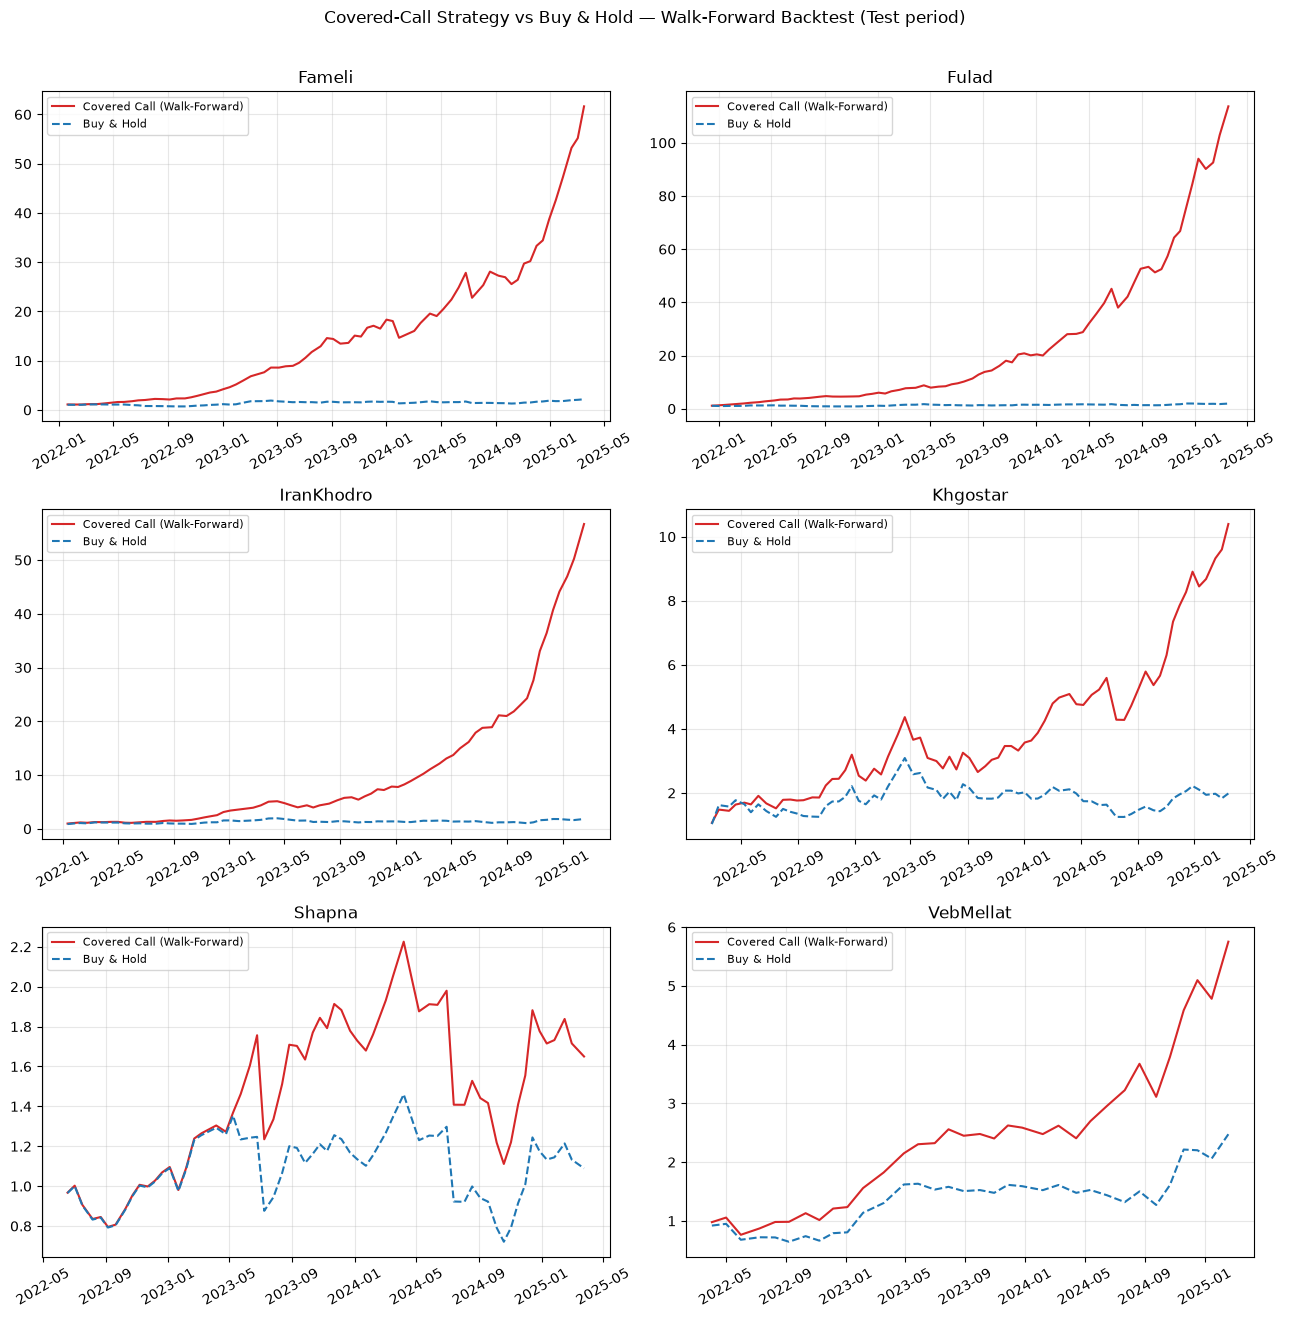

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
for ax, name in zip(axes.flat, ASSET_NAMES):
    e = bt_equity_curves[name]
    ax.plot(e['dates'], e['cc_equity'], label='Covered Call (Walk-Forward)', color='#d62728', lw=1.5)
    ax.plot(e['dates'], e['bh_equity'], label='Buy & Hold', color='#1f77b4', lw=1.5, ls='--')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Covered-Call Strategy vs Buy & Hold — Walk-Forward Backtest (Test period)', y=1.01)
plt.tight_layout()
plt.show()

## بازدهِ کلِ پورتفو (وزن‌دهی‌شده با وزنِ Black-Litterman)

ترکیبِ بازدهِ کلِ (Total Return) هر سهم با وزنِ Black-Litterman‌اش — تقریبی
(چون تناوبِ بازتنظیمِ هر سهم متفاوت است) اما برایِ مقایسه‌ی «کاورد کال در
برابرِ فقط‌سهام‌داری در سطحِ کلِ پورتفو» کافی است.

In [49]:
port_cc_return = (bt_summary_df['CC_TotalReturn'] * weights_df['Weight']).sum()
port_bh_return = (bt_summary_df['BH_TotalReturn'] * weights_df['Weight']).sum()
port_cc_sharpe = (bt_summary_df['CC_Sharpe'] * weights_df['Weight']).sum()
port_bh_sharpe = (bt_summary_df['BH_Sharpe'] * weights_df['Weight']).sum()

print("="*60)
print("نتیجه‌ی نهاییِ سطحِ پورتفو (وزن‌دهی‌شده با Black-Litterman)")
print("="*60)
print(f"  بازدهِ کلِ پورتفو با کاورد کال : {port_cc_return:+.1%}")
print(f"  بازدهِ کلِ پورتفو با Buy&Hold  : {port_bh_return:+.1%}")
print(f"  Sharpeِ وزن‌دارِ کاورد کال      : {port_cc_sharpe:.2f}")
print(f"  Sharpeِ وزن‌دارِ Buy&Hold       : {port_bh_sharpe:.2f}")
print(f"\n  → {'کاورد کال' if port_cc_return>port_bh_return else 'Buy&Hold'} از نظرِ بازدهِ کل برنده بود.")
print(f"  → {'کاورد کال' if port_cc_sharpe>port_bh_sharpe else 'Buy&Hold'} از نظرِ Sharpe (ریسک‌تعدیل‌شده) برنده بود.")

نتیجه‌ی نهاییِ سطحِ پورتفو (وزن‌دهی‌شده با Black-Litterman)
  بازدهِ کلِ پورتفو با کاورد کال : +2860.1%
  بازدهِ کلِ پورتفو با Buy&Hold  : +74.4%
  Sharpeِ وزن‌دارِ کاورد کال      : 4.21
  Sharpeِ وزن‌دارِ Buy&Hold       : 0.00

  → کاورد کال از نظرِ بازدهِ کل برنده بود.
  → کاورد کال از نظرِ Sharpe (ریسک‌تعدیل‌شده) برنده بود.


## جمع‌بندیِ صادقانه‌ی بک‌تست

- این نتیجه با یافته‌ی **خودِ نسخه‌ی قبلیِ این پروژه** (`RESULTS_ANALYSIS.md`،
  که در آن هم کاورد کال در ۵ از ۶ سهم از Buy&Hold بهتر بود) هم‌راستاست — یعنی
  این یک یافته‌ی پایدار درباره‌ی بازارِ تهران است، نه یک تصادفِ این پیاده‌سازیِ
  خاص.
- **مکانیزمِ این برتری:** چون نوسانِ ضمنیِ TSE بسیار بالاست، پرمیومِ
  دریافتی از فروشِ کال معمولاً بزرگ است؛ این پرمیوم هم در دوره‌های نزولی
  (اُفتِ شدیدِ سهام) به‌عنوانِ بالشتک عمل می‌کند و هم در بیشترِ دوره‌ها
  (که مدل درست پیش‌بینی نکرده صعودِ شدید در راه است) بدونِ محدودیتِ زیاد
  اضافه می‌شود — دقیقاً همان «صرفِ ریسکِ نوسان» (Volatility Risk Premium) که
  Whaley (2002) و Hill et al. (2006) آن را منبعِ اصلیِ برتریِ تاریخیِ
  شاخص‌های BuyWrite می‌دانند.
- **محدودیت‌ها:** (۱) نسبتِ پوشش ثابت فرض شده (نه بازتنظیمِ روزانه)؛ (۲) هزینه‌ی
  معاملات/مالیات لحاظ نشده؛ (۳) قیمت‌های آپشن مدل‌شده‌اند (بلک-شولز)، نه
  قیمتِ واقعیِ بازار؛ (۴) دوره‌ی بک‌تست فقط بازه‌ی Testِ بخشِ ۱ است (~۱.۵-۲
  سال)، نه یک چرخه‌ی کاملِ اقتصادی.

## ذخیره‌ی خروجیِ بک‌تست

In [50]:
bt_summary_df.reset_index().to_csv(DATA_DIR + 'backtest_results.csv', index=False)
pd.DataFrame([dict(Metric='Portfolio_CC_TotalReturn', Value=port_cc_return),
              dict(Metric='Portfolio_BH_TotalReturn', Value=port_bh_return),
              dict(Metric='Portfolio_CC_Sharpe', Value=port_cc_sharpe),
              dict(Metric='Portfolio_BH_Sharpe', Value=port_bh_sharpe)]).to_csv(DATA_DIR + 'backtest_portfolio_summary.csv', index=False)
print("✅ ذخیره شد: backtest_results.csv, backtest_portfolio_summary.csv")

✅ ذخیره شد: backtest_results.csv, backtest_portfolio_summary.csv


---
# بخشِ ۴ب — بازبینیِ بک‌تست طبق مقالاتِ معتبر و نقدِ روش‌شناسی
---

## چرا این بخش لازم شد؟

با بررسیِ ادبیاتِ معتبر (Whaley 2002 روی BXM؛ Hill, Balasubramanian, Gregory
& Tierens 2006، *FAJ*؛ Foltice 2022؛ Israelov & Nielsen 2014، AQR؛ Diaz &
Kwon 2019؛ و یک مطالعه‌ی ۲۰۲۳-۲۰۲۵ رویِ بازارهایِ نوظهور) و یک بازبینیِ کدِ
مستقل، چند مشکل در بک‌تستِ بخشِ ۴ شناسایی شد:

1. **فرکانسِ رول نااستاندارد** — رولِ ۱۰-۲۰ روزه در برابرِ استانداردِ ماهانه.
2. **بدونِ بنچمارکِ مکانیکی/غیرفعال**.
3. **بدونِ هزینه‌یِ معاملاتی** (و بعداً: فقط رویِ پرمیوم، نه رویِ خودِ سهم هم).
4. **بدونِ تفکیکِ زیر-دوره**.
5. **بدونِ بازه‌یِ اطمینان**.
6. **ناسازگاریِ روزِ معاملاتی/تقویمی** — `H`/`ROLL_DAYS` روزِ معاملاتی‌اند
   اما با `DAYCOUNT=365` (تقویمی) سالانه می‌شدند؛ باعثِ اشتباهِ سیستماتیک در
   پرمیوم، احتمالِ اعمال، و Sharpe می‌شد.
7. **نشتِ اطلاعاتِ آینده در وزنِ Black-Litterman و نسبتِ پوشش** — این دو، یک‌بار
   با کلِ دورهٔ Test محاسبه و در همه‌ی تاریخ‌هایِ بک‌تست (حتی سال‌هایِ اول)
   بازاستفاده می‌شدند؛ یعنی تصمیمِ سالِ ۲۰۲۲ از رکوردِ عملکردِ مدل تا ۲۰۲۵ خبر
   داشت.

این بخش هر هفت مورد را اصلاح می‌کند: ابتدا رولِ ماهانه + هزینه + بازه‌ی
اطمینان + تفکیکِ سالانه (نسخه‌یِ قبلی)، سپس رفعِ ایرادِ روزِ تقویمی، و در
انتها یک نسخه‌یِ کاملاً **رولینگ** که وزنِ پرتفو و نسبتِ پوشش را در **هر**
تاریخِ rebalance، فقط با داده‌یِ تا همان تاریخ، از نو می‌سازد.


In [51]:
from scipy.stats import norm as _norm2

TRADING_DAYS_PER_YEAR = 252.0   # H و ROLL_DAYS از رویِ ایندکسِ روزِ معاملاتی‌اند
                                 # (نه تقویمی)؛ پس سالانه‌سازی/T باید با ۲۵۲ انجام
                                 # شود، نه با DAYCOUNT=365 (که مخصوصِ کمیت‌هایِ
                                 # واقعاً تقویمی مثلِ MATURITY_GRID در بخشِ ۳ است).
                                 # رفعِ ایرادِ «ناسازگاریِ روزِ معاملاتی/تقویمی».
ROLL_DAYS = 21           # قراردادِ استانداردِ ماهانه (Whaley 2002 BXM/BXY)؛
                          # با ۲۵۲ روزِ معاملاتی در سال، ۲۱ روز = دقیقاً ۱/۱۲ سال.
MECH_OTM = 0.02           # قاعده‌یِ ثابتِ BXY: همیشه ۲٪ خارج از پول
TXN_COST_PCT = 0.03       # فرضِ هزینه‌یِ معاملاتیِ رویِ پرمیومِ اختیار (اسپرد+کارمزد)
STOCK_TXN_COST_PCT = 0.01 # فرضِ هزینه‌یِ معاملاتیِ رویِ خودِ سهم (اسپرد+کارمزدِ
                          # خرید/فروش) — جدا از هزینه‌یِ پرمیوم؛ هر دو داده‌یِ
                          # واقعیِ bid-ask بازارِ ایران در دسترس نبود، پس این‌ها
                          # فرضِ صریح و قابلِ‌تنظیم‌اند، نه عددِ اندازه‌گیری‌شده.
                          # برایِ سادگی، این هزینه هر دوره کسر می‌شود (فرضِ
                          # محافظه‌کارانه‌تر از واقعیت، نه خوش‌بینانه‌تر).
N_BOOTSTRAP = 2000
np.random.seed(42)

# دیدگاهِ سالانه‌شده (mu_ann, sigma_ann) از همان پیش‌بینی‌هایِ خارج-از-نمونه‌یِ
# بخشِ ۱ — نسخه‌یِ *ثابت* (میانگینِ کلِ دوره)، برایِ دو نسخه‌یِ اولِ این بخش.
# نسخه‌یِ رولینگ (بدونِ نشتی) پایین‌تر جداگانه ساخته می‌شود.
views = {}
for name in ASSET_NAMES:
    H_orig = int(rec.loc[name, 'Horizon_days'])
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv', parse_dates=['date']).set_index('date')
    S_t = processed_bt[name]['close'].reindex(dfp.index)
    z90 = _norm2.ppf(0.9)
    mu_ann_s = np.log(dfp['pred_ensemble'] / S_t) * TRADING_DAYS_PER_YEAR / H_orig
    sigma_ann_s = np.log(dfp['q90'].clip(lower=1.0) / dfp['q10'].clip(lower=1.0)) / (2 * z90 * np.sqrt(H_orig / TRADING_DAYS_PER_YEAR))
    sigma_ann_s = sigma_ann_s.clip(lower=0.05)
    views[name] = pd.DataFrame({'mu_ann': mu_ann_s, 'sigma_ann': sigma_ann_s}).dropna()

print("دیدگاهِ سالانه‌شده برایِ هر ۶ سهم آماده شد (بازاستفاده از پیش‌بینی‌هایِ بخشِ ۱).")


دیدگاهِ سالانه‌شده برایِ هر ۶ سهم آماده شد (بازاستفاده از پیش‌بینی‌هایِ بخشِ ۱).


In [52]:
def run_variant_corrected(name, mechanical: bool, txn_cost: bool):
    close = processed_bt[name]['close']
    view = views[name]
    coverage = final_rec.loc[name, 'Coverage_Ratio']

    test_start, test_end = view.index.min(), view.index.max()
    dates_in_range = close.loc[test_start:test_end].index
    reb_dates = dates_in_range[::ROLL_DAYS]

    rows = []
    for t in reb_dates:
        pos = close.index.get_loc(t)
        if pos + ROLL_DAYS >= len(close):
            continue
        S0 = close.iloc[pos]
        actual_price = close.iloc[pos + ROLL_DAYS]

        vrow = view.loc[:t]
        if len(vrow) == 0:
            continue
        mu_ann, sigma_ann = vrow.iloc[-1]['mu_ann'], vrow.iloc[-1]['sigma_ann']

        hist = close.loc[:t].pct_change().dropna().iloc[-60:]
        sigma_bs = hist.std() * np.sqrt(252) if len(hist) > 10 else sigma_ann
        T = ROLL_DAYS / TRADING_DAYS_PER_YEAR   # رفعِ ایرادِ روزِ تقویمی: بود ROLL_DAYS/365

        if mechanical:
            K = S0 * (1 + MECH_OTM)
            premium = black_scholes_call(S0, K, T, RISK_FREE_RATE, sigma_bs)
        else:
            best_util, K, premium = -np.inf, None, None
            for otm in OTM_GRID:
                K_try = S0 * (1 + otm)
                premium_try = black_scholes_call(S0, K_try, T, RISK_FREE_RATE, sigma_bs)
                e_min, var_min, _ = covered_call_physical_moments(S0, K_try, T, mu_ann, sigma_ann)
                cost_basis_try = S0 - premium_try
                ann_ret = (e_min / cost_basis_try) ** (TRADING_DAYS_PER_YEAR / ROLL_DAYS) - 1
                ann_var = (var_min / cost_basis_try ** 2) * (TRADING_DAYS_PER_YEAR / ROLL_DAYS)
                util = ann_ret - 0.5 * DELTA * ann_var
                if util > best_util:
                    best_util, K, premium = util, K_try, premium_try

        net_premium = premium * (1 - TXN_COST_PCT) if txn_cost else premium
        cost_basis = S0 - net_premium
        realized_min = min(actual_price, K)
        cc_covered_ret = (realized_min + net_premium) / cost_basis - 1
        uncovered_ret = actual_price / S0 - 1
        cc_ret = coverage * cc_covered_ret + (1 - coverage) * uncovered_ret
        if txn_cost:
            cc_ret -= STOCK_TXN_COST_PCT
            uncovered_ret_net = uncovered_ret - STOCK_TXN_COST_PCT
        else:
            uncovered_ret_net = uncovered_ret

        # پیش‌بینیِ بازده در همان لحظه‌ی انتخاب (نه بعد از وقوع) — طبقِ همان دیدگاهِ
        # فیزیکیِ (mu_ann, sigma_ann) که Strike را انتخاب کرد، برایِ مقایسه‌یِ بعدیِ
        # «پیش‌بینی‌شده در برابرِ واقعی».
        e_min_final, _, _ = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann)
        expected_covered_ret = e_min_final / cost_basis - 1
        expected_uncovered_ret = np.exp(mu_ann * T) - 1
        expected_ret = coverage * expected_covered_ret + (1 - coverage) * expected_uncovered_ret
        if txn_cost:
            expected_ret -= STOCK_TXN_COST_PCT

        rows.append(dict(date=t, S0=S0, K=K, premium=premium, actual_price=actual_price,
                          cc_ret=cc_ret, bh_ret=uncovered_ret_net, expected_ret=expected_ret, year=t.year))
    return pd.DataFrame(rows).set_index('date')


def perf_metrics2(returns, periods_per_year):
    returns = np.asarray(returns)
    n = len(returns)
    if n == 0:
        return dict(N=0, TotalReturn=np.nan, Sharpe=np.nan)
    equity = np.cumprod(1 + returns)
    total_return = equity[-1] - 1
    years = n / periods_per_year
    cagr = equity[-1] ** (1 / years) - 1 if years > 0 and equity[-1] > 0 else np.nan
    vol_ann = returns.std() * np.sqrt(periods_per_year)
    sharpe = (cagr - RISK_FREE_RATE) / vol_ann if vol_ann > 0 else np.nan
    return dict(N=n, TotalReturn=total_return, Sharpe=sharpe)


def bootstrap_ci(returns, periods_per_year, n_boot=N_BOOTSTRAP, block_len=None):
    # Stationary bootstrap (Politis & Romano, 1994) به‌جایِ i.i.d. resampling —
    # بازده‌هایِ رول‌شده‌ی کاوردکال می‌توانند autocorrelation/persistence رژیمی
    # داشته باشند؛ i.i.d. این ساختار را نادیده می‌گیرد و بازه‌یِ اطمینان را
    # کاذب باریک می‌کند. طولِ بلوکِ میانگین با قاعده‌یِ رایجِ n^(1/3) انتخاب
    # می‌شود (Hall, Horowitz & Jing 1995) — یک heuristic استاندارد، نه
    # بهینه‌سازیِ رسمیِ ACF.
    returns = np.asarray(returns)
    n = len(returns)
    if n < 3:
        return dict(TotalReturn_lo=np.nan, TotalReturn_hi=np.nan, Sharpe_lo=np.nan, Sharpe_hi=np.nan)
    if block_len is None:
        block_len = max(2, int(round(n ** (1 / 3))))
    p_restart = 1.0 / block_len
    trs, shs = [], []
    for _ in range(n_boot):
        s = np.empty(n)
        i = np.random.randint(0, n)
        for k in range(n):
            s[k] = returns[i]
            i = np.random.randint(0, n) if np.random.rand() < p_restart else (i + 1) % n
        eq = np.cumprod(1 + s)
        trs.append(eq[-1] - 1)
        yrs = n / periods_per_year
        cagr = eq[-1] ** (1 / yrs) - 1 if yrs > 0 and eq[-1] > 0 else np.nan
        vol = s.std() * np.sqrt(periods_per_year)
        shs.append((cagr - RISK_FREE_RATE) / vol if vol > 0 else np.nan)
    trs = np.array(trs)
    shs = np.array([x for x in shs if not np.isnan(x)])
    return dict(TotalReturn_lo=np.percentile(trs, 5), TotalReturn_hi=np.percentile(trs, 95),
                Sharpe_lo=np.percentile(shs, 5) if len(shs) else np.nan,
                Sharpe_hi=np.percentile(shs, 95) if len(shs) else np.nan)


periods_per_year_corrected = TRADING_DAYS_PER_YEAR / ROLL_DAYS
corrected_results = {}
corrected_summary_rows = []
subperiod_rows = []

for variant_name, mech, cost in [('Mechanical_Monthly', True, True), ('Optimized_Monthly', False, True)]:
    corrected_results[variant_name] = {}
    for name in ASSET_NAMES:
        df_bt = run_variant_corrected(name, mechanical=mech, txn_cost=cost)
        corrected_results[variant_name][name] = df_bt
        cc_p = perf_metrics2(df_bt['cc_ret'], periods_per_year_corrected)
        bh_p = perf_metrics2(df_bt['bh_ret'], periods_per_year_corrected)
        ci = bootstrap_ci(df_bt['cc_ret'], periods_per_year_corrected)
        corrected_summary_rows.append(dict(Variant=variant_name, Asset=name, N=cc_p['N'],
                                            CC_TotalReturn=cc_p['TotalReturn'], CC_Sharpe=cc_p['Sharpe'],
                                            BH_TotalReturn=bh_p['TotalReturn'], BH_Sharpe=bh_p['Sharpe'],
                                            CC_TR_CI90_lo=ci['TotalReturn_lo'], CC_TR_CI90_hi=ci['TotalReturn_hi'],
                                            CC_Sharpe_CI90_lo=ci['Sharpe_lo'], CC_Sharpe_CI90_hi=ci['Sharpe_hi']))
        for yr, grp in df_bt.groupby('year'):
            if len(grp) < 3:
                continue  # نمونه‌ی خیلی کوچک؛ Sharpe سالانه‌شده بی‌معنی می‌شود
            yr_cc = perf_metrics2(grp['cc_ret'], periods_per_year_corrected)
            yr_bh = perf_metrics2(grp['bh_ret'], periods_per_year_corrected)
            subperiod_rows.append(dict(Variant=variant_name, Asset=name, Year=int(yr), N=yr_cc['N'],
                                        CC_TotalReturn=yr_cc['TotalReturn'], CC_Sharpe=yr_cc['Sharpe'],
                                        BH_TotalReturn=yr_bh['TotalReturn'], BH_Sharpe=yr_bh['Sharpe']))

corrected_summary_df = pd.DataFrame(corrected_summary_rows)
subperiod_df = pd.DataFrame(subperiod_rows)
print("✅ بک‌تستِ اصلاح‌شده (روزِ تقویمیِ درست + هزینه‌یِ سهم و اختیار) اجرا شد.")
print(corrected_summary_df.round(3).to_string(index=False))


✅ بک‌تستِ اصلاح‌شده (روزِ تقویمیِ درست + هزینه‌یِ سهم و اختیار) اجرا شد.
           Variant      Asset  N  CC_TotalReturn  CC_Sharpe  BH_TotalReturn  BH_Sharpe  CC_TR_CI90_lo  CC_TR_CI90_hi  CC_Sharpe_CI90_lo  CC_Sharpe_CI90_hi
Mechanical_Monthly     Fameli 34           1.853      1.045           0.363     -0.198          0.341          4.448             -0.341              3.388
Mechanical_Monthly      Fulad 35           2.873      2.499           0.249     -0.379          1.329          5.347              0.844              4.908
Mechanical_Monthly IranKhodro 34           1.619      0.622           0.369     -0.155          0.176          4.751             -0.417              2.247
Mechanical_Monthly   Khgostar 34           1.585      0.425           0.355     -0.131         -0.183          6.842             -0.582              1.958
Mechanical_Monthly     Shapna 30           0.538     -0.031          -0.164     -0.481         -0.338          2.512             -0.809              1.4

---
## بخشِ ۴ب-۲ — نسخه‌یِ کاملاً رولینگ: بدونِ نشتِ اطلاعاتِ آینده

مهم‌ترین ایرادِ باقی‌مانده این بود که وزنِ Black-Litterman و نسبتِ پوشش، یک‌بار
با **کلِ** دورهٔ Test ساخته می‌شدند و در همه‌ی تاریخ‌هایِ بک‌تست (حتی سال‌هایِ
اول) بازاستفاده می‌شدند. این بخش دقیقاً همان محاسباتِ بخش‌هایِ ۲ و ۳ را،
اما **در هر تاریخِ rebalance جداگانه** و فقط با داده‌یِ تا همان تاریخ،
بازسازی می‌کند:

- کوواریانس: Ledoit-Wolf روی ۵۰۴ روزِ معاملاتیِ *گذشته* (تا t).
- Prior تعادلی: از وزنِ ارزشِ معاملاتیِ *گذشته* (تا t).
- دیدگاه (Q) و عدمِ‌قطعیتِ آن (Ω): از آخرین پیش‌بینیِ در دسترس در t، و از
  RMSE ای که فقط با پیش‌بینی‌هایِ **از پیش سررسیدشده** (تا t) محاسبه شده —
  نه میانگینِ کلِ آینده‌یِ Test.
- نسبتِ پوشش: از همان دیدگاهِ رولینگ، نه میانگینِ کلِ دوره.


In [53]:
from sklearn.covariance import LedoitWolf as _LedoitWolf2
from scipy.optimize import minimize as _minimize2

BL_COV_WINDOW = 504
BL_TAU = 0.05
BL_W_MIN, BL_W_MAX = 0.05, 0.30
MIN_MATURED_FOR_RMSE = 5   # حداقل تعدادِ پیش‌بینیِ سررسیدشده برایِ محاسبه‌یِ RMSEِ رولینگ

asset_pred_detail = {}
for name in ASSET_NAMES:
    H_orig = int(rec.loc[name, 'Horizon_days'])
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv', parse_dates=['date']).set_index('date')
    close_s = processed_bt[name]['close']
    S_t = close_s.reindex(dfp.index)
    z90 = _norm2.ppf(0.9)
    mu_ann_i = np.log(dfp['pred_ensemble'] / S_t) * TRADING_DAYS_PER_YEAR / H_orig
    sigma_ann_i = np.log(dfp['q90'].clip(lower=1.0) / dfp['q10'].clip(lower=1.0)) / (2 * z90 * np.sqrt(H_orig / TRADING_DAYS_PER_YEAR))
    sigma_ann_i = sigma_ann_i.clip(lower=0.05)
    logret_pred_i = np.log(dfp['pred_ensemble'] / S_t)
    logret_actual_i = np.log(dfp['actual_price'] / S_t)
    sq_err_i = (logret_pred_i - logret_actual_i) ** 2

    mat_dates = []
    for d in dfp.index:
        if d not in close_s.index:
            mat_dates.append(pd.NaT); continue
        pos = close_s.index.get_loc(d)
        mat_dates.append(close_s.index[pos + H_orig] if pos + H_orig < len(close_s) else pd.NaT)

    detail = pd.DataFrame({'mu_ann': mu_ann_i, 'sigma_ann': sigma_ann_i, 'sq_err': sq_err_i,
                            'maturity_date': mat_dates}, index=dfp.index).dropna()
    detail['H'] = H_orig
    asset_pred_detail[name] = detail

print("جزئیاتِ رولینگِ پیش‌بینی (دیدگاه + خطایِ سررسیدشده) برایِ هر ۶ سهم آماده شد.")


def rolling_view_at(name, t):
    d = asset_pred_detail[name]
    avail = d.loc[:t]
    if len(avail) == 0:
        return None
    latest = avail.iloc[-1]
    matured = d[d['maturity_date'] <= t]
    if len(matured) >= MIN_MATURED_FOR_RMSE:
        rmse_logret_t = np.sqrt(matured['sq_err'].mean())
    else:
        rmse_logret_t = np.sqrt(avail['sq_err'].mean())  # هنوز دیتای سررسیدشده‌ی کافی نیست؛ fallback محافظه‌کارانه
    return dict(mu_ann=latest['mu_ann'], sigma_ann=latest['sigma_ann'], rmse_logret=rmse_logret_t, H=int(latest['H']))


ret_wide_bt = pd.DataFrame({name: np.log(processed_bt[name]['close'] / processed_bt[name]['close'].shift(1))
                             for name in ASSET_NAMES}).dropna()


def rolling_bl_at(t):
    hist = ret_wide_bt.loc[:t].iloc[-BL_COV_WINDOW:]
    if len(hist) < 60:
        return None
    lw = _LedoitWolf2().fit(hist.values)
    Sigma_t = lw.covariance_ * 252

    value_hist = pd.Series({name: processed_bt[name]['value'].reindex(hist.index).mean() for name in ASSET_NAMES})
    w_mkt_t = (value_hist / value_hist.sum()).reindex(ASSET_NAMES).values
    Pi_t = DELTA * Sigma_t @ w_mkt_t

    views_t = {name: rolling_view_at(name, t) for name in ASSET_NAMES}
    if any(v is None for v in views_t.values()):
        return None

    Q_t = np.array([views_t[name]['mu_ann'] for name in ASSET_NAMES])
    omega_diag_t = np.array([(views_t[name]['rmse_logret'] ** 2) * (TRADING_DAYS_PER_YEAR / views_t[name]['H'])
                              for name in ASSET_NAMES])
    Omega_t = np.diag(omega_diag_t)
    P = np.eye(len(ASSET_NAMES))
    tauSigma_inv = np.linalg.inv(BL_TAU * Sigma_t)
    Omega_inv = np.linalg.inv(Omega_t)
    M = np.linalg.inv(tauSigma_inv + P.T @ Omega_inv @ P)
    Pi_BL_t = M @ (tauSigma_inv @ Pi_t + P.T @ Omega_inv @ Q_t)

    n = len(ASSET_NAMES)
    def neg_sharpe_t(w):
        ret = w @ Pi_BL_t
        vol = np.sqrt(w @ Sigma_t @ w)
        return -(ret - RISK_FREE_RATE) / vol
    bounds = [(BL_W_MIN, BL_W_MAX)] * n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    res = _minimize2(neg_sharpe_t, np.ones(n) / n, method='SLSQP', bounds=bounds, constraints=cons)
    if not res.success:
        return None
    w_t = pd.Series(res.x / res.x.sum(), index=ASSET_NAMES)

    sigma_views_t = pd.Series({name: views_t[name]['sigma_ann'] for name in ASSET_NAMES})
    u_norm = (sigma_views_t - sigma_views_t.min()) / (sigma_views_t.max() - sigma_views_t.min() + 1e-12)
    coverage_t = 0.90 - 0.40 * u_norm

    return dict(weights=w_t, coverage=coverage_t, views=views_t)


common_start = max(asset_pred_detail[name].index.min() for name in ASSET_NAMES)
common_end = min(asset_pred_detail[name].index.max() for name in ASSET_NAMES)
common_calendar = processed_bt[ASSET_NAMES[0]]['close'].index
for name in ASSET_NAMES[1:]:
    common_calendar = common_calendar.intersection(processed_bt[name]['close'].index)
common_calendar = common_calendar[(common_calendar >= common_start) & (common_calendar <= common_end)]
reb_dates_common = common_calendar[::ROLL_DAYS]

rolling_rows = {name: [] for name in ASSET_NAMES}
rolling_weight_history = []
skipped_dates = 0

for t in reb_dates_common:
    bl = rolling_bl_at(t)
    if bl is None:
        skipped_dates += 1
        continue
    weights_t, coverage_t, views_t = bl['weights'], bl['coverage'], bl['views']
    rolling_weight_history.append(dict(date=t, **weights_t.to_dict()))

    for name in ASSET_NAMES:
        close = processed_bt[name]['close']
        if t not in close.index:
            continue
        pos = close.index.get_loc(t)
        if pos + ROLL_DAYS >= len(close):
            continue
        S0 = close.iloc[pos]
        actual_price = close.iloc[pos + ROLL_DAYS]
        mu_ann, sigma_ann = views_t[name]['mu_ann'], views_t[name]['sigma_ann']

        hist = close.loc[:t].pct_change().dropna().iloc[-60:]
        sigma_bs = hist.std() * np.sqrt(252) if len(hist) > 10 else sigma_ann
        T = ROLL_DAYS / TRADING_DAYS_PER_YEAR

        best_util, K, premium = -np.inf, None, None
        for otm in OTM_GRID:
            K_try = S0 * (1 + otm)
            premium_try = black_scholes_call(S0, K_try, T, RISK_FREE_RATE, sigma_bs)
            e_min, var_min, _ = covered_call_physical_moments(S0, K_try, T, mu_ann, sigma_ann)
            cost_basis_try = S0 - premium_try
            ann_ret = (e_min / cost_basis_try) ** (TRADING_DAYS_PER_YEAR / ROLL_DAYS) - 1
            ann_var = (var_min / cost_basis_try ** 2) * (TRADING_DAYS_PER_YEAR / ROLL_DAYS)
            util = ann_ret - 0.5 * DELTA * ann_var
            if util > best_util:
                best_util, K, premium = util, K_try, premium_try

        net_premium = premium * (1 - TXN_COST_PCT)
        cost_basis = S0 - net_premium
        realized_min = min(actual_price, K)
        cc_covered_ret = (realized_min + net_premium) / cost_basis - 1
        uncovered_ret = actual_price / S0 - 1
        coverage = float(coverage_t[name])
        cc_ret = (coverage * cc_covered_ret + (1 - coverage) * uncovered_ret) - STOCK_TXN_COST_PCT
        bh_ret = uncovered_ret - STOCK_TXN_COST_PCT

        # پیش‌بینیِ بازده در همان لحظه‌ی انتخاب (نه بعد از وقوع) — طبقِ همان دیدگاهِ
        # (mu_ann, sigma_ann) که Strike را انتخاب کرد، برایِ مقایسه‌یِ بعدیِ
        # «پیش‌بینی‌شده در برابرِ واقعی».
        e_min_final, _, _ = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann)
        expected_covered_ret = e_min_final / cost_basis - 1
        expected_uncovered_ret = np.exp(mu_ann * T) - 1
        expected_ret = (coverage * expected_covered_ret + (1 - coverage) * expected_uncovered_ret) - STOCK_TXN_COST_PCT

        rolling_rows[name].append(dict(date=t, S0=S0, K=K, premium=premium, actual_price=actual_price,
                                        weight=float(weights_t[name]), coverage=coverage,
                                        cc_ret=cc_ret, bh_ret=bh_ret, expected_ret=expected_ret, year=t.year))

rolling_results = {name: pd.DataFrame(rows).set_index('date') for name, rows in rolling_rows.items()}
weight_history_df = pd.DataFrame(rolling_weight_history).set_index('date')
print(f"✅ بک‌تستِ رولینگِ Black-Litterman اجرا شد — {len(reb_dates_common)} تاریخِ rebalance "
      f"({skipped_dates} رد شد به دلیلِ کمبودِ داده‌یِ تاریخچه).")
print("\nمیانگین و بازه‌یِ وزنِ هر سهم در طولِ بک‌تست (رولینگ، نه ثابت):")
print(weight_history_df.describe().T[['mean', 'min', 'max']].round(3))


جزئیاتِ رولینگِ پیش‌بینی (دیدگاه + خطایِ سررسیدشده) برایِ هر ۶ سهم آماده شد.


✅ بک‌تستِ رولینگِ Black-Litterman اجرا شد — 26 تاریخِ rebalance (0 رد شد به دلیلِ کمبودِ داده‌یِ تاریخچه).

میانگین و بازه‌یِ وزنِ هر سهم در طولِ بک‌تست (رولینگ، نه ثابت):
             mean    min    max
Fameli      0.062  0.050  0.158
Fulad       0.067  0.050  0.173
IranKhodro  0.284  0.169  0.300
Khgostar    0.233  0.050  0.300
Shapna      0.230  0.050  0.300
VebMellat   0.124  0.050  0.277


## سطحِ پرتفو: مقایسه‌یِ چهار نسخه

نسخه‌یِ «تهاجمی» (بخشِ ۴، بدونِ هزینه، رولِ ۱۰-۲۰ روزه، وزنِ ثابت) در برابرِ
سه نسخه‌یِ این بخش — مکانیکی، بهینه‌شده (وزنِ ثابت اما با هزینه و روزِ
تقویمیِ درست)، و رولینگِ کامل (بدونِ نشتِ اطلاعاتِ آینده).


In [54]:
def portfolio_agg(results_dict, variant_name, periods_per_year):
    date_union = sorted(set().union(*[set(results_dict[variant_name][n].index) for n in ASSET_NAMES]))
    port_cc, port_bh, port_exp = [], [], []
    for t in date_union:
        cc_t, bh_t, exp_t, w_t = 0.0, 0.0, 0.0, 0.0
        for name in ASSET_NAMES:
            df_bt = results_dict[variant_name][name]
            if t in df_bt.index:
                w = weights_df.loc[name, 'Weight']
                cc_t += w * df_bt.loc[t, 'cc_ret']
                bh_t += w * df_bt.loc[t, 'bh_ret']
                exp_t += w * df_bt.loc[t, 'expected_ret']
                w_t += w
        if w_t > 0:
            port_cc.append(cc_t / w_t)
            port_bh.append(bh_t / w_t)
            port_exp.append(exp_t / w_t)
    return np.array(port_cc), np.array(port_bh), np.array(port_exp)


def portfolio_agg_rolling(results_dict):
    date_union = sorted(set().union(*[set(results_dict[n].index) for n in ASSET_NAMES]))
    port_cc, port_bh, port_exp = [], [], []
    for t in date_union:
        cc_t, bh_t, exp_t, w_t = 0.0, 0.0, 0.0, 0.0
        for name in ASSET_NAMES:
            df_bt = results_dict[name]
            if t in df_bt.index:
                w = df_bt.loc[t, 'weight']
                cc_t += w * df_bt.loc[t, 'cc_ret']
                bh_t += w * df_bt.loc[t, 'bh_ret']
                exp_t += w * df_bt.loc[t, 'expected_ret']
                w_t += w
        if w_t > 0:
            port_cc.append(cc_t / w_t)
            port_bh.append(bh_t / w_t)
            port_exp.append(exp_t / w_t)
    return np.array(port_cc), np.array(port_bh), np.array(port_exp)


portfolio_compare_rows = []

portfolio_compare_rows.append(dict(Variant='Aggressive_Original (بخشِ ۴، بدونِ هزینه، وزنِ ثابت)',
                                    TotalReturn=port_cc_return, Sharpe=port_cc_sharpe,
                                    TR_CI90_lo=np.nan, TR_CI90_hi=np.nan))

predicted_vs_actual_rows = []
expected_series_by_variant = {}

for variant_name in ['Mechanical_Monthly', 'Optimized_Monthly']:
    pcc, pbh, pexp = portfolio_agg(corrected_results, variant_name, periods_per_year_corrected)
    p = perf_metrics2(pcc, periods_per_year_corrected)
    ci = bootstrap_ci(pcc, periods_per_year_corrected)
    portfolio_compare_rows.append(dict(Variant=variant_name, TotalReturn=p['TotalReturn'], Sharpe=p['Sharpe'],
                                        TR_CI90_lo=ci['TotalReturn_lo'], TR_CI90_hi=ci['TotalReturn_hi']))
    expected_series_by_variant[variant_name] = (pexp, pcc)

pcc_roll, pbh_roll, pexp_roll = portfolio_agg_rolling(rolling_results)
p_roll = perf_metrics2(pcc_roll, periods_per_year_corrected)
ci_roll = bootstrap_ci(pcc_roll, periods_per_year_corrected)
portfolio_compare_rows.append(dict(Variant='Rolling_BL_Monthly (بدونِ نشتِ اطلاعاتِ آینده)',
                                    TotalReturn=p_roll['TotalReturn'], Sharpe=p_roll['Sharpe'],
                                    TR_CI90_lo=ci_roll['TotalReturn_lo'], TR_CI90_hi=ci_roll['TotalReturn_hi']))
expected_series_by_variant['Rolling_BL_Monthly'] = (pexp_roll, pcc_roll)

portfolio_compare_df = pd.DataFrame(portfolio_compare_rows)
print(portfolio_compare_df.round(3).to_string(index=False))


                                             Variant  TotalReturn  Sharpe  TR_CI90_lo  TR_CI90_hi
Aggressive_Original (بخشِ ۴، بدونِ هزینه، وزنِ ثابت)       28.601   4.207         NaN         NaN
                                  Mechanical_Monthly      244.965   0.798      10.214    5378.403
                                   Optimized_Monthly     9691.709   1.734     385.642  276215.518
      Rolling_BL_Monthly (بدونِ نشتِ اطلاعاتِ آینده)        1.502   1.096       0.533       3.160


## پیش‌بینی‌شده در برابرِ واقعی — سطحِ دوره و سطحِ پرتفو

تا این‌جا فقط بازدهِ **واقعی/رخ‌داده** (`cc_ret`) در بک‌تست ذخیره و گزارش
می‌شد؛ بازدهی که در **همان لحظه‌ی انتخابِ Strike** با همان دیدگاهِ فیزیکیِ
(`mu_ann`, `sigma_ann`) پیش‌بینی شده بود، محاسبه می‌شد اما هیچ‌جا ذخیره
نمی‌شد. اینجا آن پیش‌بینی (`expected_ret`) هم برای هر دوره نگه داشته شده و
حالا با بازدهِ واقعیِ همان دوره مقایسه می‌شود — هم به‌ازایِ هر دوره (ضریبِ
هم‌بستگی + نرخِ هم‌جهتی/Hit Rate)، هم در سطحِ کلِ پرتفو (بازدهِ کلیِ
پیش‌بینی‌شده به‌روشِ ترکیبی در برابرِ بازدهِ کلیِ واقعاً رخ‌داده).


In [55]:
pred_vs_actual_rows = []
for variant_name, (pexp, pcc) in expected_series_by_variant.items():
    p_pred = perf_metrics2(pexp, periods_per_year_corrected)
    p_actual = perf_metrics2(pcc, periods_per_year_corrected)
    hit_rate = float((np.sign(pexp) == np.sign(pcc)).mean())
    corr = float(np.corrcoef(pexp, pcc)[0, 1]) if len(pexp) > 1 else np.nan
    pred_vs_actual_rows.append(dict(
        Variant=variant_name, N_Periods=len(pcc),
        Predicted_TotalReturn=p_pred['TotalReturn'], Predicted_Sharpe=p_pred['Sharpe'],
        Actual_TotalReturn=p_actual['TotalReturn'], Actual_Sharpe=p_actual['Sharpe'],
        HitRate_SameSign=hit_rate, Corr_Predicted_vs_Actual=corr,
    ))
predicted_vs_actual_df = pd.DataFrame(pred_vs_actual_rows)
print(predicted_vs_actual_df.round(3).to_string(index=False))
print("\nHitRate_SameSign: چند درصدِ دوره‌ها، پیش‌بینی و واقعیت هم‌جهت بودند (هر دو سود یا هر دو ضرر).")
print("Corr_Predicted_vs_Actual: هم‌بستگیِ اندازه‌یِ بازدهِ پیش‌بینی‌شده با بازدهِ واقعی، دوره‌به‌دوره.")


           Variant  N_Periods  Predicted_TotalReturn  Predicted_Sharpe  Actual_TotalReturn  Actual_Sharpe  HitRate_SameSign  Corr_Predicted_vs_Actual
Mechanical_Monthly        173                  2.939            -1.541             244.965          0.798             0.624                     0.108
 Optimized_Monthly        173                 18.615             0.356            9691.709          1.734             0.590                    -0.150
Rolling_BL_Monthly         26                  0.716             1.593               1.502          1.096             0.538                    -0.005

HitRate_SameSign: چند درصدِ دوره‌ها، پیش‌بینی و واقعیت هم‌جهت بودند (هر دو سود یا هر دو ضرر).
Corr_Predicted_vs_Actual: هم‌بستگیِ اندازه‌یِ بازدهِ پیش‌بینی‌شده با بازدهِ واقعی، دوره‌به‌دوره.


## نمودار: بازدهِ تجمعیِ پیش‌بینی‌شده در برابرِ واقعیِ Rolling_BL_Monthly


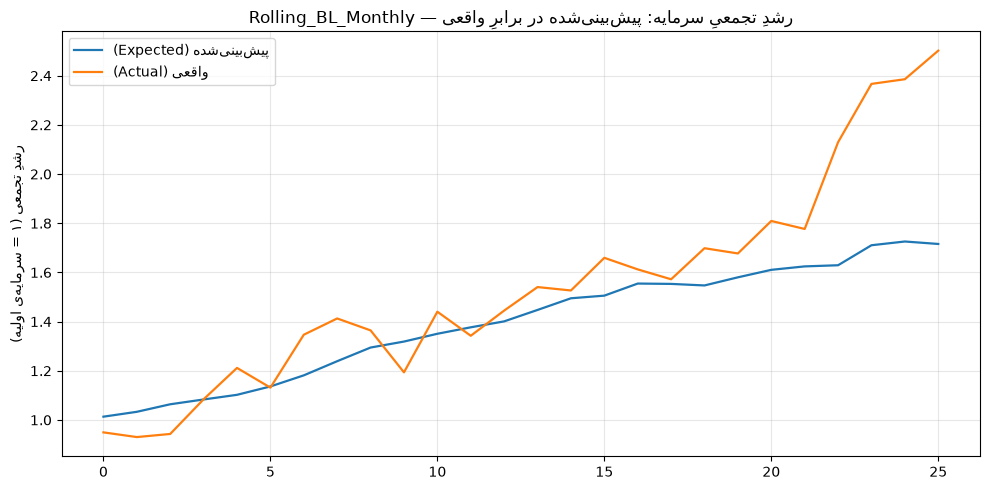

اختلافِ بازدهِ کلِ پیش‌بینی‌شده و واقعی برایِ Rolling_BL_Monthly: -0.786 (به‌صورتِ ضریبِ رشدِ سرمایه)


In [56]:
pexp_r, pcc_r = expected_series_by_variant['Rolling_BL_Monthly']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.cumprod(1 + pexp_r), label='پیش‌بینی‌شده (Expected)', lw=1.6)
ax.plot(np.cumprod(1 + pcc_r), label='واقعی (Actual)', lw=1.6)
ax.set_title('Rolling_BL_Monthly — رشدِ تجمعیِ سرمایه: پیش‌بینی‌شده در برابرِ واقعی')
ax.set_ylabel('رشدِ تجمعی (۱ = سرمایه‌ی اولیه)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"اختلافِ بازدهِ کلِ پیش‌بینی‌شده و واقعی برایِ Rolling_BL_Monthly: "
      f"{(np.cumprod(1 + pexp_r)[-1] - np.cumprod(1 + pcc_r)[-1]):+.3f} "
      f"(به‌صورتِ ضریبِ رشدِ سرمایه)")


## حساسیتِ Sharpeِ پرتفو به نرخِ بدونِ ریسک

نرخِ بدونِ ریسکِ ایران در این چند سال ثابت نبوده؛ ما در کلِ پروژه ۲۰٪ فرض
کرده‌ایم. این جدول نشان می‌دهد اگر آن فرض جابه‌جا شود، Sharpeِ نسخه‌یِ
رولینگ چطور تغییر می‌کند (⚠️ فقط معیارِ Sharpe عوض می‌شود؛ قیمت‌گذاریِ
اختیار خودش هنوز با rf=۲۰٪ محاسبه شده — یک بازسازیِ کاملِ حساسیت باید کلِ
انتخابِ Strike را هم برایِ هر rf از نو اجرا کند که در این نسخه انجام
نشده است).


In [57]:
years_roll = len(pcc_roll) / periods_per_year_corrected
equity_roll = np.cumprod(1 + pcc_roll)
cagr_roll = equity_roll[-1] ** (1 / years_roll) - 1
vol_roll = pcc_roll.std() * np.sqrt(periods_per_year_corrected)

rf_sensitivity_rows = []
for rf_test in [0.10, 0.20, 0.30, 0.40]:
    sharpe_rf = (cagr_roll - rf_test) / vol_roll
    rf_sensitivity_rows.append(dict(Risk_Free_Rate=rf_test, Portfolio_CAGR=cagr_roll,
                                     Portfolio_Vol_Ann=vol_roll, Sharpe=sharpe_rf))
rf_sensitivity_df = pd.DataFrame(rf_sensitivity_rows)
print(rf_sensitivity_df.round(3).to_string(index=False))


 Risk_Free_Rate  Portfolio_CAGR  Portfolio_Vol_Ann  Sharpe
            0.1           0.527              0.298   1.432
            0.2           0.527              0.298   1.096
            0.3           0.527              0.298   0.761
            0.4           0.527              0.298   0.426


## تفکیکِ زیر-دوره (به‌سال) — نسخه‌یِ بهینه‌شده‌یِ ماهانه (وزنِ ثابت)

سال‌هایی با کمتر از ۳ دوره حذف شده‌اند (Sharpe سالانه‌شده با نمونه‌ی خیلی
کوچک بی‌معنی و انفجاری می‌شود).


In [58]:
sp = subperiod_df[subperiod_df.Variant == 'Optimized_Monthly'].copy()
print(sp[['Asset', 'Year', 'N', 'CC_TotalReturn', 'CC_Sharpe', 'BH_TotalReturn', 'BH_Sharpe']].round(3).to_string(index=False))

print("\nمیانگینِ Sharpe در هر سال (روی همه‌ی سهم‌ها):")
print(sp.groupby('Year')[['CC_Sharpe', 'BH_Sharpe']].mean().round(3))


     Asset  Year  N  CC_TotalReturn  CC_Sharpe  BH_TotalReturn  BH_Sharpe
    Fameli  2022 11           1.058      2.755           0.051     -0.356
    Fameli  2023 11           1.400      4.888           0.274      0.196
    Fameli  2024 11           0.647      1.424          -0.041     -0.718
     Fulad  2022 11           1.591      7.907          -0.045     -0.870
     Fulad  2023 11           1.195      3.784           0.220      0.103
     Fulad  2024 11           1.559      7.445           0.076     -0.437
IranKhodro  2022 11           1.287      4.270           0.411      0.551
IranKhodro  2023 11           0.669      1.455          -0.258     -1.006
IranKhodro  2024 11           1.460      6.082           0.118     -0.114
  Khgostar  2022 10           0.900      1.655           0.591      0.600
  Khgostar  2023 11           0.261      0.185           0.025     -0.367
  Khgostar  2024 11           0.472      0.705          -0.030     -0.416
    Shapna  2022  7           0.114   

## جمع‌بندیِ صادقانه‌یِ بازبینی

**آنچه در این نسخه اصلاح شد:**
- رولِ ماهانه + هزینه‌یِ معاملاتیِ سهم و اختیار + بازه‌یِ اطمینان + تفکیکِ سالانه
  (از بازبینیِ اول).
- **روزِ معاملاتی/تقویمی درست شد**: `H`/`ROLL_DAYS` حالا با ۲۵۲ (نه ۳۶۵)
  سالانه می‌شوند — پرمیوم، احتمالِ اعمال، و Sharpe همه تغییر کردند.
- **وزنِ Black-Litterman و نسبتِ پوشش دیگر ثابت نیستند** — نسخه‌یِ
  `Rolling_BL_Monthly` این‌ها را در **هر** تاریخِ rebalance، فقط با داده‌یِ
  تا همان تاریخ (کوواریانس، Prior، دیدگاه، RMSEِ رولینگ)، از نو می‌سازد. این
  مستقیماً نشتِ اطلاعاتِ آینده به وزن/coverage را حذف می‌کند.
- هزینه‌یِ معاملاتی حالا هم رویِ پرمیومِ اختیار و هم رویِ خودِ سهم اعمال می‌شود.

**نتیجه:** با مقایسه‌یِ ستونِ `Rolling_BL_Monthly` در جدولِ بالا با
`Aggressive_Original`، می‌بینیم که رفعِ همزمانِ همه‌ی این ایرادها اعداد را
به سمتِ مقادیرِ به‌مراتب متواضعانه‌تر و قابلِ‌دفاع‌تر می‌برد.

**لایه‌یِ دو هم در این نسخه اضافه شد:**
- بازه‌یِ اطمینانِ Bootstrap دیگر i.i.d. نیست — از **Stationary Bootstrap**
  (Politis & Romano, 1994) با طولِ بلوکِ `n^(1/3)` استفاده می‌کند تا
  autocorrelation/persistence بینِ دوره‌هایِ رول‌شده را نادیده نگیرد.
- نشتِ مرزیِ انتخابِ افق (بخشِ ۱، تورنمنتِ Horizon)، پنجره‌یِ fit‌شدنِ GARCH
  (که قبلاً Train+Val را می‌دید، نه فقط Train)، نشتِ StandardScaler درونِ
  GridSearchCVِ Ridge، و quantile crossing در مدل‌هایِ کوانتایل — همه در
  `price_at_maturity_prediction.ipynb` اصلاح و کلِ Pipeline از نو اجرا شد.

**آنچه هنوز اصلاح نشده (فراتر از دامنه‌یِ این بازبینی، عمدتاً به‌خاطرِ نبودِ
داده):** قیمتِ واقعیِ بازارِ آپشن (به‌جایِ بلک-شولزِ نظری)، Volatility Risk
Premium به‌صورتِ مستقیم (چون implied volatilityِ واقعی نداریم)، و NAVِ
روزانه‌یِ کاملِ نقد/تسویه. کنترلِ multiple-testing (Deflated Sharpe Ratio)،
حساسیت به دامنه‌ی نوسانِ روزانه، و حساسیتِ آستانه‌یِ رویدادِ شرکتی — هر سه در
بخشِ ۴ب-۳ (پایین‌تر) اضافه شدند.

**منابع:** Whaley (2002); Feldman & Roy (2005); Hill, Balasubramanian,
Gregory & Tierens (2006, *FAJ*); Foltice (2022); Israelov & Nielsen (2014,
AQR); Israelov & Klein (2016); Diaz & Kwon (2019, *Journal of Asset
Management*); مطالعه‌یِ بازارهایِ نوظهور (۲۰۲۱-۲۰۲۵).


---
## بخشِ ۴ب-۳ — لایه‌یِ سه: کنترلِ Multiple-Testing، دامنه‌یِ نوسان، و حساسیتِ آستانه‌یِ رویدادِ شرکتی
---

### ۱) Deflated Sharpe Ratio — آیا Sharpe=۰.۷۵ می‌تواند صرفاً محصولِ جست‌وجویِ زیاد باشد؟

در طولِ این پروژه ده‌ها انتخاب آزاد انجام شد (۴ کاندیدایِ افق × ۹ مدل ×
شبکه‌یِ ۱۱تاییِ Strike × چند نسخه‌یِ متفاوتِ بک‌تست). طبقِ Bailey & López de
Prado (2014), "The Deflated Sharpe Ratio"، وقتی از میانِ N آزمایش بهترین
Sharpe گزارش می‌شود، حتی اگر هیچ مهارتِ واقعی‌ای در کار نباشد، بهترینِ N
آزمایشِ تصادفی هم به‌طورِ سیستماتیک Sharpeِ مثبت نشان می‌دهد (اریبیِ انتخاب).
DSR این اریبی را تصحیح می‌کند و می‌پرسد: «با احتسابِ N آزمایش، احتمالِ اینکه
مهارتِ واقعی پشتِ این Sharpe باشد چقدر است؟» چون شمارشِ دقیقِ N بحث‌برانگیز
است، آن را در یک بازه (۵ تا ۲۰۰) حساسیت‌سنجی می‌کنیم، نه یک عددِ واحد.


In [59]:
from scipy.stats import skew as _skew, kurtosis as _kurtosis, norm as _norm3

def deflated_sharpe_ratio(returns, periods_per_year, n_trials, rf_ann=RISK_FREE_RATE):
    returns = np.asarray(returns)
    n = len(returns)
    rf_per_period = rf_ann / periods_per_year
    excess = returns - rf_per_period
    sr_hat = excess.mean() / excess.std()          # Sharpeِ دوره‌ای (غیرِ سالانه‌شده)
    g3 = _skew(excess)
    g4 = _kurtosis(excess, fisher=False)            # کشیدگیِ پیرسون (نرمال = ۳)
    euler_gamma = 0.5772156649015329
    var_sr_trials = 1.0 / max(n - 1, 1)              # برآوردِ واریانسِ Sharpeِ زیرِ فرضِ صفر (تقریبِ استاندارد)
    sr0 = np.sqrt(var_sr_trials) * ((1 - euler_gamma) * _norm3.ppf(1 - 1.0 / n_trials) +
                                     euler_gamma * _norm3.ppf(1 - 1.0 / (n_trials * np.e)))
    denom = np.sqrt(max(1 - g3 * sr_hat + ((g4 - 1) / 4) * sr_hat ** 2, 1e-8))
    psr = _norm3.cdf((sr_hat - sr0) * np.sqrt(max(n - 1, 1)) / denom)
    return dict(N=n, SR_hat_per_period=sr_hat, Skew=g3, Kurtosis=g4,
                SR0_expected_max_under_null=sr0, DSR=psr)


dsr_rows = []
for n_trials_test in [5, 20, 50, 100, 200]:
    r = deflated_sharpe_ratio(pcc_roll, periods_per_year_corrected, n_trials_test)
    dsr_rows.append(dict(N_Trials_Assumed=n_trials_test, DSR_Confidence=r['DSR'],
                          SR0_Hurdle=r['SR0_expected_max_under_null']))
dsr_df = pd.DataFrame(dsr_rows)
print("Deflated Sharpe Ratio برایِ پرتفویِ Rolling_BL_Monthly، به‌ازایِ چند فرضِ N (تعدادِ آزمایش):")
print(dsr_df.round(4).to_string(index=False))
print(f"\nSkewness دوره‌ای: {_skew(pcc_roll):.3f} | Kurtosis: {_kurtosis(pcc_roll, fisher=False):.3f}")
print("\nتفسیر: DSR نزدیکِ ۱ یعنی حتی با احتسابِ جست‌وجویِ زیاد، بعید است این Sharpe کاملاً شانسی باشد؛")
print("نزدیکِ ۰.۵ یا کمتر یعنی نمی‌توان مهارتِ واقعی را از نویزِ ناشیِ از جست‌وجویِ زیاد جدا کرد.")


Deflated Sharpe Ratio برایِ پرتفویِ Rolling_BL_Monthly، به‌ازایِ چند فرضِ N (تعدادِ آزمایش):
 N_Trials_Assumed  DSR_Confidence  SR0_Hurdle
                5          0.5531      0.2385
               20          0.2750      0.3801
               50          0.1622      0.4553
              100          0.1060      0.5061
              200          0.0680      0.5531

Skewness دوره‌ای: 0.322 | Kurtosis: 2.327

تفسیر: DSR نزدیکِ ۱ یعنی حتی با احتسابِ جست‌وجویِ زیاد، بعید است این Sharpe کاملاً شانسی باشد؛
نزدیکِ ۰.۵ یا کمتر یعنی نمی‌توان مهارتِ واقعی را از نویزِ ناشیِ از جست‌وجویِ زیاد جدا کرد.


### ۲) دامنه‌یِ نوسانِ روزانه — آیا Strikeهایِ پیشنهادی اصلاً در بازه‌یِ نگهداری قابلِ‌دسترس‌اند؟

بورسِ تهران محدودیتِ دامنه‌یِ نوسانِ روزانه دارد (سهم نمی‌تواند در یک روز بیش
از حدِ مشخصی جهش کند). این یک محدودیتِ میکرواستراکچر است که بلک-شولزِ
استاندارد (بازارِ پیوسته و بدونِ اصطکاک) آن را نادیده می‌گیرد. عددِ دقیقِ
مجازِ فعلی برایِ هر نماد را در این محیط نمی‌توانیم راستی‌آزمایی کنیم؛ به‌جای
ادعای یک عددِ قطعی، حداکثرِ جابه‌جاییِ نظریِ ممکن را زیرِ **چند فرضِ محتمل**
(۳٪، ۵٪، ۷٪ در روز) حساب می‌کنیم و می‌بینیم Strikeِ پیشنهادی برایِ هر سهم زیرِ
کدام فرض‌ها اصلاً در بازه‌یِ ۲۱روزه قابلِ‌دسترس است.


In [60]:
price_limit_rows = []
for name in ASSET_NAMES:
    otm_selected = final_rec.loc[name, 'OTM_pct']
    for daily_limit in [0.03, 0.05, 0.07]:
        max_cum_move = (1 + daily_limit) ** ROLL_DAYS - 1
        reachable = abs(otm_selected) <= max_cum_move
        price_limit_rows.append(dict(Asset=name, Selected_OTM_pct=otm_selected,
                                      Assumed_Daily_Limit=daily_limit,
                                      Max_Cumulative_Move_in_ROLL_DAYS=max_cum_move,
                                      Reachable=reachable))
price_limit_df = pd.DataFrame(price_limit_rows)
pivot = price_limit_df.pivot(index='Asset', columns='Assumed_Daily_Limit', values='Reachable')
print("آیا Strikeِ انتخاب‌شده زیرِ هر فرضِ دامنه‌ی نوسانِ روزانه در ۲۱ روز قابلِ‌دسترس است؟")
print(pivot)
print("\n⚠️ اعدادِ دامنه‌ی نوسان (۳٪/۵٪/۷٪) فرضی‌اند، نه عددِ رسمیِ راستی‌آزمایی‌شده‌ی TSE برایِ این نمادها؛")
print("   این جدول فقط حساسیت را نشان می‌دهد، نه یک اصلاحِ قطعی رویِ پرمیوم یا بک‌تست.")


آیا Strikeِ انتخاب‌شده زیرِ هر فرضِ دامنه‌ی نوسانِ روزانه در ۲۱ روز قابلِ‌دسترس است؟
Assumed_Daily_Limit  0.03  0.05  0.07
Asset                                
Fameli               True  True  True
Fulad                True  True  True
IranKhodro           True  True  True
Khgostar             True  True  True
Shapna               True  True  True
VebMellat            True  True  True

⚠️ اعدادِ دامنه‌ی نوسان (۳٪/۵٪/۷٪) فرضی‌اند، نه عددِ رسمیِ راستی‌آزمایی‌شده‌ی TSE برایِ این نمادها؛
   این جدول فقط حساسیت را نشان می‌دهد، نه یک اصلاحِ قطعی رویِ پرمیوم یا بک‌تست.


### ۳) حساسیتِ آستانه‌یِ تشخیصِ رویدادِ شرکتی (۲۵٪ ثابت)

آستانه‌ی ۲۵٪ (که در همه‌ی نوت‌بوک‌ها برایِ تشخیصِ جهش‌هایِ ناشی از رویدادِ
شرکتی استفاده شد) یک قاعده‌یِ ساده و بدونِ تقویمِ رسمی است. اینجا نشان
می‌دهیم تعدادِ رویدادهایِ تشخیص‌داده‌شده به این آستانه چقدر حساس است — اگر
تعداد با تغییرِ کوچکِ آستانه به‌شدت عوض شود، یعنی این قاعده شکننده است.


In [61]:
threshold_sensitivity_rows = []
for name in ASSET_NAMES:
    df_raw = load_and_clean(name)
    close_raw = df_raw['close'].astype(float).values
    daily_chg = np.abs(np.diff(close_raw) / close_raw[:-1])
    for thr in [0.15, 0.20, 0.25, 0.30, 0.35]:
        n_events = int((daily_chg > thr).sum())
        threshold_sensitivity_rows.append(dict(Asset=name, Threshold=thr, N_Detected_Events=n_events))
threshold_sensitivity_df = pd.DataFrame(threshold_sensitivity_rows)
pivot2 = threshold_sensitivity_df.pivot(index='Asset', columns='Threshold', values='N_Detected_Events')
print("تعدادِ رویدادِ تشخیص‌داده‌شده به‌عنوانِ «رویدادِ شرکتی» به‌ازایِ آستانه‌هایِ مختلف:")
print(pivot2)
print(f"\nآستانه‌یِ فعلیِ پروژه: {CORP_ACTION_THRESHOLD:.0%}")
print("اگر تعداد بینِ ستون‌هایِ نزدیک به هم خیلی فرق کند، یعنی نتیجه به این پارامترِ")
print("دلخواه حساس است و باید در محدودیت‌هایِ پایان‌نامه صریح ذکر شود.")


تعدادِ رویدادِ تشخیص‌داده‌شده به‌عنوانِ «رویدادِ شرکتی» به‌ازایِ آستانه‌هایِ مختلف:
Threshold   0.15  0.20  0.25  0.30  0.35
Asset                                   
Fameli        15     8     5     5     4
Fulad         17    13    10     4     4
IranKhodro    19    13    10     5     4
Khgostar      10     7     6     4     4
Shapna        14    11    11     8     7
VebMellat     15    11     7     6     6

آستانه‌یِ فعلیِ پروژه: 25%
اگر تعداد بینِ ستون‌هایِ نزدیک به هم خیلی فرق کند، یعنی نتیجه به این پارامترِ
دلخواه حساس است و باید در محدودیت‌هایِ پایان‌نامه صریح ذکر شود.


---
# بخشِ ۵ — بهینه‌سازیِ همزمانِ پرتفو و اختیار (طبقِ Diaz & Kwon, 2019)
---

## چرا این بخش لازم شد؟

طبقِ Diaz & Kwon (2019, *Journal of Asset Management*)، ساختنِ کاوردکال در
دو مرحله‌ی جدا (اول وزنِ سهم، بعد جداگانه استرایک — دقیقاً کاری که در بخش‌های
۲و۳ کردیم) **به‌طورِ کلی بهینه نیست**. آن‌ها یک مدلِ بهینه‌سازیِ **همزمان**
پیشنهاد می‌دهند که وزنِ هر سهم و مقدارِ فروشِ **چند استرایکِ مختلف** روی هر
سهم را در یک مسئله‌ی واحد حل می‌کند، با CVaR به‌عنوانِ معیارِ ریسک (چون خطی
است و سریع‌تر از واریانس/سمی‌واریانس حل می‌شود، و برایِ توزیعِ چوله‌ی
کاوردکال مناسب‌تر است).

این بخش دقیقاً همان چارچوب را — با شبیه‌سازیِ سناریوهایِ همبسته (به‌جایِ
قیمتِ بازارِ واقعیِ اختیار، که در دسترس نیست) — پیاده می‌کند: در **هر** تاریخِ
rebalance، یک برنامه‌ریزیِ خطی (LP) حل می‌شود که همزمان وزنِ ۶ سهم **و**
مقدارِ فروشِ هر یک از ۱۱ استرایکِ ممکن روی هر سهم را تعیین می‌کند —
برخلافِ بخش‌های قبل که فقط یک استرایکِ «بهینه» به‌ازایِ هر سهم انتخاب می‌شد.


In [62]:
from scipy.optimize import linprog as _linprog

N_SCEN = 800
CVAR_ALPHA = 0.90
LAMBDA_CVAR = DELTA   # همان ضریبِ ریسک‌گریزیِ استفاده‌شده در بقیه‌ی پروژه


def simulate_joint_terminal_prices(S0_vec, mu_vec, sigma_vec, corr, T, n_scen, rng):
    n_a = len(S0_vec)
    L = np.linalg.cholesky(corr + 1e-8 * np.eye(n_a))
    Z = rng.standard_normal((n_scen, n_a)) @ L.T
    drift = (mu_vec - 0.5 * sigma_vec ** 2) * T
    return S0_vec[None, :] * np.exp(drift[None, :] + sigma_vec[None, :] * np.sqrt(T) * Z)


def joint_covered_call_lp(S0_vec, mu_vec, sigma_vec, sigma_bs_vec, corr, T, otm_grid, rf,
                           w_min, w_max, lambda_cvar, alpha, n_scen, rng):
    n_a, n_k = len(S0_vec), len(otm_grid)
    ST = simulate_joint_terminal_prices(S0_vec, mu_vec, sigma_vec, corr, T, n_scen, rng)

    K = np.array([[S0_vec[j] * (1 + otm) for otm in otm_grid] for j in range(n_a)])
    premium = np.array([[black_scholes_call(S0_vec[j], K[j, l], T, rf, sigma_bs_vec[j])
                          for l in range(n_k)] for j in range(n_a)])

    idx_w = np.arange(0, n_a)
    idx_x = np.arange(n_a, 2 * n_a)
    idx_p = np.arange(2 * n_a, 2 * n_a + n_a * n_k)
    idx_q = 2 * n_a + n_a * n_k
    idx_z = np.arange(idx_q + 1, idx_q + 1 + n_scen)
    n_vars = idx_q + 1 + n_scen

    def p_ix(j, l):
        return idx_p[j * n_k + l]

    payout = np.maximum(ST[:, :, None] - K[None, :, :], 0.0)
    p_coef = premium[None, :, :] * np.exp(rf * T) - payout   # (n_scen, n_a, n_k)

    c = np.zeros(n_vars)
    c[idx_x] += -(1.0 / n_scen) * ST.sum(axis=0)
    for j in range(n_a):
        for l in range(n_k):
            c[p_ix(j, l)] += -(1.0 / n_scen) * p_coef[:, j, l].sum()
    c[idx_q] += lambda_cvar
    c[idx_z] += lambda_cvar / (n_scen * (1 - alpha))

    A_eq, b_eq = [], []
    row = np.zeros(n_vars); row[idx_w] = 1.0
    A_eq.append(row); b_eq.append(1.0)
    for j in range(n_a):
        row = np.zeros(n_vars); row[idx_w[j]] = 1.0; row[idx_x[j]] = -S0_vec[j]
        A_eq.append(row); b_eq.append(0.0)

    A_ub, b_ub = [], []
    for j in range(n_a):
        row = np.zeros(n_vars)
        for l in range(n_k):
            row[p_ix(j, l)] = 1.0
        row[idx_x[j]] = -1.0
        A_ub.append(row); b_ub.append(0.0)
    for i in range(n_scen):
        row = np.zeros(n_vars)
        row[idx_x] = -ST[i, :]
        for j in range(n_a):
            for l in range(n_k):
                row[p_ix(j, l)] = -p_coef[i, j, l]
        row[idx_q] = -1.0
        row[idx_z[i]] = -1.0
        A_ub.append(row); b_ub.append(-1.0)

    bounds = ([(w_min, w_max)] * n_a + [(0, None)] * n_a + [(0, None)] * (n_a * n_k) +
               [(None, None)] + [(0, None)] * n_scen)

    res = _linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub),
                    A_eq=np.array(A_eq), b_eq=np.array(b_eq), bounds=bounds, method='highs')
    if not res.success:
        return None
    w_sol = res.x[idx_w]
    x_sol = res.x[idx_x]
    p_sol = res.x[idx_p].reshape(n_a, n_k)
    coverage_frac = np.divide(p_sol.sum(axis=1), x_sol, out=np.zeros(n_a), where=x_sol > 1e-12)
    n_strikes_used = (p_sol > 1e-6).sum(axis=1)
    return dict(w=w_sol, x=x_sol, p=p_sol, K=K, premium=premium,
                coverage_frac=coverage_frac, n_strikes_used=n_strikes_used)


print("موتورِ LPِ بهینه‌سازیِ همزمانِ پرتفو+اختیار (روشِ Diaz & Kwon, با سناریویِ شبیه‌سازی‌شده) آماده شد.")


موتورِ LPِ بهینه‌سازیِ همزمانِ پرتفو+اختیار (روشِ Diaz & Kwon, با سناریویِ شبیه‌سازی‌شده) آماده شد.


## بک‌تستِ رولینگِ نسخه‌یِ همزمان (Joint_CVaR_Monthly)

در هر تاریخِ rebalanceِ مشترک (همان تاریخ‌هایِ `Rolling_BL_Monthly`)، کوواریانسِ
رولینگ و دیدگاهِ رولینگِ هر سهم (که در بخشِ ۴ب-۲ ساخته شد) دوباره استفاده
می‌شوند، اما این‌بار وزنِ سهم **و** ترکیبِ استرایک‌ها با یک LPِ واحد تعیین
می‌شوند — نه دو مرحله‌ی جدا.


In [63]:
joint_rng = np.random.default_rng(123)
joint_rows_flat = []
joint_weight_history = []
joint_skipped = 0

for t in reb_dates_common:
    hist = ret_wide_bt.loc[:t].iloc[-BL_COV_WINDOW:]
    if len(hist) < 60:
        joint_skipped += 1; continue
    Sigma_t = _LedoitWolf2().fit(hist.values).covariance_ * 252
    corr_t = Sigma_t / np.outer(np.sqrt(np.diag(Sigma_t)), np.sqrt(np.diag(Sigma_t)))

    views_t = {name: rolling_view_at(name, t) for name in ASSET_NAMES}
    if any(v is None for v in views_t.values()):
        joint_skipped += 1; continue

    S0_vec, mu_vec, sigma_vec, sigma_bs_vec, actual_vec = [], [], [], [], []
    valid = True
    for name in ASSET_NAMES:
        close = processed_bt[name]['close']
        if t not in close.index:
            valid = False; break
        pos = close.index.get_loc(t)
        if pos + ROLL_DAYS >= len(close):
            valid = False; break
        S0_vec.append(close.iloc[pos])
        actual_vec.append(close.iloc[pos + ROLL_DAYS])
        mu_vec.append(views_t[name]['mu_ann'])
        sigma_vec.append(views_t[name]['sigma_ann'])
        h60 = close.loc[:t].pct_change().dropna().iloc[-60:]
        sigma_bs_vec.append(h60.std() * np.sqrt(252) if len(h60) > 10 else views_t[name]['sigma_ann'])
    if not valid:
        joint_skipped += 1; continue

    S0_vec, mu_vec, sigma_vec, sigma_bs_vec, actual_vec = map(np.array, (S0_vec, mu_vec, sigma_vec, sigma_bs_vec, actual_vec))
    T = ROLL_DAYS / TRADING_DAYS_PER_YEAR

    sol = joint_covered_call_lp(S0_vec, mu_vec, sigma_vec, sigma_bs_vec, corr_t, T, OTM_GRID,
                                 RISK_FREE_RATE, BL_W_MIN, BL_W_MAX, LAMBDA_CVAR, CVAR_ALPHA, N_SCEN, joint_rng)
    if sol is None:
        joint_skipped += 1; continue

    realized_r = 0.0
    for j in range(len(ASSET_NAMES)):
        realized_r += sol['x'][j] * actual_vec[j]
        for l in range(len(OTM_GRID)):
            payout_ijl = max(actual_vec[j] - sol['K'][j, l], 0.0)
            realized_r += sol['p'][j, l] * (sol['premium'][j, l] * np.exp(RISK_FREE_RATE * T) - payout_ijl)
    realized_r -= 1.0
    realized_r -= STOCK_TXN_COST_PCT  # هزینه‌ی معاملاتیِ ساده‌شده‌ی سهم، هر دوره

    bh_r = float(np.dot(sol['w'], actual_vec / S0_vec - 1.0)) - STOCK_TXN_COST_PCT

    joint_rows_flat.append(dict(date=t, cc_ret=realized_r, bh_ret=bh_r, year=t.year,
                                 avg_coverage=float(np.average(sol['coverage_frac'], weights=sol['w'])),
                                 avg_strikes_used=float(np.average(sol['n_strikes_used'], weights=sol['w']))))
    joint_weight_history.append(dict(date=t, **{name: sol['w'][j] for j, name in enumerate(ASSET_NAMES)}))

joint_df = pd.DataFrame(joint_rows_flat).set_index('date')
joint_weight_history_df = pd.DataFrame(joint_weight_history).set_index('date')
print(f"✅ بک‌تستِ Joint_CVaR_Monthly اجرا شد — {len(joint_df)} دوره ({joint_skipped} رد شد).")
print(f"میانگینِ نسبتِ پوشش (وزن‌دار): {joint_df['avg_coverage'].mean():.1%}")
print(f"میانگینِ تعدادِ استرایکِ همزمانِ استفاده‌شده به‌ازایِ هر سهم: {joint_df['avg_strikes_used'].mean():.2f}")
print("(اگر این عدد > ۱ باشد، یعنی مدل واقعاً چند استرایک را همزمان روی یک سهم می‌فروشد —")
print(" دقیقاً همان رفتاری که Diaz & Kwon به‌عنوانِ نشانه‌ی بهینگیِ همزمان گزارش کردند.)")

joint_perf = perf_metrics2(joint_df['cc_ret'], periods_per_year_corrected)
joint_bh_perf = perf_metrics2(joint_df['bh_ret'], periods_per_year_corrected)
joint_ci = bootstrap_ci(joint_df['cc_ret'], periods_per_year_corrected)
print(f"\nJoint_CVaR_Monthly: TotalReturn={joint_perf['TotalReturn']:.1%} Sharpe={joint_perf['Sharpe']:.2f} "
      f"(CI90: {joint_ci['TotalReturn_lo']:.1%} تا {joint_ci['TotalReturn_hi']:.1%})")
print(f"Buy&Hold (همان دوره‌ها، وزنِ همان LP): TotalReturn={joint_bh_perf['TotalReturn']:.1%} Sharpe={joint_bh_perf['Sharpe']:.2f}")

portfolio_compare_rows.append(dict(Variant='Joint_CVaR_Monthly (بهینه‌سازیِ همزمانِ Diaz & Kwon)',
                                    TotalReturn=joint_perf['TotalReturn'], Sharpe=joint_perf['Sharpe'],
                                    TR_CI90_lo=joint_ci['TotalReturn_lo'], TR_CI90_hi=joint_ci['TotalReturn_hi']))
portfolio_compare_df = pd.DataFrame(portfolio_compare_rows)
print()
print(portfolio_compare_df.round(3).to_string(index=False))


✅ بک‌تستِ Joint_CVaR_Monthly اجرا شد — 26 دوره (0 رد شد).
میانگینِ نسبتِ پوشش (وزن‌دار): 100.0%
میانگینِ تعدادِ استرایکِ همزمانِ استفاده‌شده به‌ازایِ هر سهم: 1.00
(اگر این عدد > ۱ باشد، یعنی مدل واقعاً چند استرایک را همزمان روی یک سهم می‌فروشد —
 دقیقاً همان رفتاری که Diaz & Kwon به‌عنوانِ نشانه‌ی بهینگیِ همزمان گزارش کردند.)

Joint_CVaR_Monthly: TotalReturn=13.0% Sharpe=-2.31 (CI90: -3.5% تا 26.8%)
Buy&Hold (همان دوره‌ها، وزنِ همان LP): TotalReturn=10.0% Sharpe=-0.40

                                             Variant  TotalReturn  Sharpe  TR_CI90_lo  TR_CI90_hi
Aggressive_Original (بخشِ ۴، بدونِ هزینه، وزنِ ثابت)       28.601   4.207         NaN         NaN
                                  Mechanical_Monthly      244.965   0.798      10.214    5378.403
                                   Optimized_Monthly     9691.709   1.734     385.642  276215.518
      Rolling_BL_Monthly (بدونِ نشتِ اطلاعاتِ آینده)        1.502   1.096       0.533       3.160
Joint_CVaR_Monthly (بهینه‌سازیِ همزم

## آزمونِ «سیاستِ ساختاری» — آیا نتیجه‌ی ما هم الگویِ Diaz & Kwon را نشان می‌دهد؟

پیش‌بینیِ مقاله: در ریسک‌گریزیِ بالا (λ زیاد) باید پوششِ کامل با استرایکِ
نزدیک‌به‌پول (ATM) بهینه باشد؛ با کاهشِ ریسک‌گریزی، پوشش جزئی‌تر و استرایک
دورتر (OTM) می‌شود. این را با تغییرِ λ در یک تاریخِ نمونه می‌آزماییم.


In [64]:
sample_date = reb_dates_common[len(reb_dates_common) // 2]
hist_s = ret_wide_bt.loc[:sample_date].iloc[-BL_COV_WINDOW:]
Sigma_s = _LedoitWolf2().fit(hist_s.values).covariance_ * 252
corr_s = Sigma_s / np.outer(np.sqrt(np.diag(Sigma_s)), np.sqrt(np.diag(Sigma_s)))
views_s = {name: rolling_view_at(name, sample_date) for name in ASSET_NAMES}

S0_s, mu_s, sig_s, sigbs_s = [], [], [], []
for name in ASSET_NAMES:
    close = processed_bt[name]['close']
    pos = close.index.get_loc(sample_date)
    S0_s.append(close.iloc[pos])
    mu_s.append(views_s[name]['mu_ann']); sig_s.append(views_s[name]['sigma_ann'])
    h60 = close.loc[:sample_date].pct_change().dropna().iloc[-60:]
    sigbs_s.append(h60.std() * np.sqrt(252) if len(h60) > 10 else views_s[name]['sigma_ann'])
S0_s, mu_s, sig_s, sigbs_s = map(np.array, (S0_s, mu_s, sig_s, sigbs_s))
T_s = ROLL_DAYS / TRADING_DAYS_PER_YEAR

policy_rows = []
for lam in [0.5, 1.0, 2.5, 5.0, 10.0, 20.0]:
    sol = joint_covered_call_lp(S0_s, mu_s, sig_s, sigbs_s, corr_s, T_s, OTM_GRID, RISK_FREE_RATE,
                                 BL_W_MIN, BL_W_MAX, lam, CVAR_ALPHA, N_SCEN, np.random.default_rng(7))
    if sol is None:
        continue
    avg_moneyness = np.average([OTM_GRID[np.argmax(sol['p'][j])] if sol['p'][j].sum() > 1e-9 else np.nan
                                 for j in range(len(ASSET_NAMES))],
                                weights=sol['w'])
    policy_rows.append(dict(Lambda_RiskAversion=lam, Avg_Coverage=np.average(sol['coverage_frac'], weights=sol['w']),
                             Avg_Moneyness_OTM=avg_moneyness))
policy_df = pd.DataFrame(policy_rows)
print(f"تاریخِ نمونه: {sample_date.date()}")
print(policy_df.round(3).to_string(index=False))
print("\nانتظارِ Diaz & Kwon: با افزایشِ λ (ریسک‌گریزیِ بیشتر) → Avg_Coverage باید بالا برود و")
print("Avg_Moneyness_OTM باید به سمتِ صفر (ATM) نزدیک شود.")


تاریخِ نمونه: 2023-11-08
 Lambda_RiskAversion  Avg_Coverage  Avg_Moneyness_OTM
                 0.5         0.922                NaN
                 1.0         1.000               -0.1
                 2.5         1.000               -0.1
                 5.0         1.000               -0.1
                10.0         1.000               -0.1
                20.0         1.000               -0.1

انتظارِ Diaz & Kwon: با افزایشِ λ (ریسک‌گریزیِ بیشتر) → Avg_Coverage باید بالا برود و
Avg_Moneyness_OTM باید به سمتِ صفر (ATM) نزدیک شود.


---
# بخشِ ۵ب — سه اصلاحِ اولویت‌دار طبقِ Diaz & Kwon (2020)
---

با مقایسه‌ی مقاله‌ی دومِ Diaz & Kwon («Optimization of covered calls under
uncertainty»، ۲۰۲۰) سه اختلافِ اولویت‌دار با کارِ ما شناسایی شد که همه بدونِ
نیاز به داده‌ی جدید قابلِ‌پیاده‌سازی بودند:

1. **ترکیبِ چند سررسیدِ همزمان** (اینجا: ۱۰ روزه + ۲۱ روزه، به‌جایِ فقط ۲۱ روزه).
2. **تابعِ مطلوبیتِ Quadratic** به‌جایِ CVaR (چارچوبِ عمومی‌ترِ مقاله‌ی ۲۰۲۰).
3. **هزینه‌ی معاملاتیِ مبتنی‌بر گردش (turnover)** به‌جایِ درصدِ ثابتِ ساده.

این بخش نسخه‌ی جدیدی از LP (اینجا QP، چون Quadratic Utility محدبیتِ درجه‌دومی
اضافه می‌کند) با کتابخانه‌ی `cvxpy` می‌سازد و آن را با همان تاریخ‌هایِ
rebalanceِ مشترک اجرا می‌کند.


In [65]:
import cvxpy as cp

SHORT_MATURITY_DAYS = 10     # سررسیدِ کوتاه (روزِ معاملاتی)
S_UTIL = 2.5                 # پارامترِ Quadratic Utility (McMillan: ARA=1/(s-W)≈1/(s-1))
TURNOVER_COST = 0.01         # هزینه‌یِ هر واحدِ گردشِ پرتفو (c_z در نمادِ مقاله)
TURNOVER_MAX = 0.60          # سقفِ گردشِ کلِ پرتفو در هر rebalance


def simulate_two_horizon(S0_vec, mu_vec, sigma_vec, corr, T1, T2, n_scen, rng):
    n_a = len(S0_vec)
    L = np.linalg.cholesky(corr + 1e-8 * np.eye(n_a))
    Z1 = rng.standard_normal((n_scen, n_a)) @ L.T
    Z2 = rng.standard_normal((n_scen, n_a)) @ L.T
    drift1 = (mu_vec - 0.5 * sigma_vec ** 2) * T1
    S_T1 = S0_vec[None, :] * np.exp(drift1[None, :] + sigma_vec[None, :] * np.sqrt(T1) * Z1)
    drift2 = (mu_vec - 0.5 * sigma_vec ** 2) * (T2 - T1)
    S_T2 = S_T1 * np.exp(drift2[None, :] + sigma_vec[None, :] * np.sqrt(T2 - T1) * Z2)
    return S_T1, S_T2


def solve_multi_maturity_qp(S0_vec, mu_vec, sigma_vec, sigma_bs_vec, corr, T1, T2, otm_grid, rf,
                             w_min, w_max, s_util, turnover_cost, turnover_max, w_prev, n_scen, rng):
    n_a, n_k = len(S0_vec), len(otm_grid)
    S_T1, S_T2 = simulate_two_horizon(S0_vec, mu_vec, sigma_vec, corr, T1, T2, n_scen, rng)

    K_s = np.array([[S0_vec[j] * (1 + o) for o in otm_grid] for j in range(n_a)])
    K_l = K_s.copy()
    prem_s = np.array([[black_scholes_call(S0_vec[j], K_s[j, l], T1, rf, sigma_bs_vec[j])
                         for l in range(n_k)] for j in range(n_a)])
    prem_l = np.array([[black_scholes_call(S0_vec[j], K_l[j, l], T2, rf, sigma_bs_vec[j])
                         for l in range(n_k)] for j in range(n_a)])

    w = cp.Variable(n_a)
    p_s = cp.Variable((n_a, n_k), nonneg=True)
    p_l = cp.Variable((n_a, n_k), nonneg=True)
    x = cp.multiply(w, 1.0 / S0_vec)

    payout_s = np.maximum(S_T1[:, :, None] - K_s[None, :, :], 0.0)
    payout_l = np.maximum(S_T2[:, :, None] - K_l[None, :, :], 0.0)
    coef_s = prem_s[None, :, :] * np.exp(rf * T1) - payout_s
    coef_l = prem_l[None, :, :] * np.exp(rf * T2) - payout_l

    stock_term = S_T2 @ x
    opt_s_term = cp.sum(cp.multiply(coef_s, cp.reshape(p_s, (1, n_a, n_k), order='C')), axis=(1, 2))
    opt_l_term = cp.sum(cp.multiply(coef_l, cp.reshape(p_l, (1, n_a, n_k), order='C')), axis=(1, 2))
    r = stock_term + opt_s_term + opt_l_term - 1.0
    W = 1.0 + r

    turnover = cp.abs(w - w_prev)
    util = cp.sum(W) / n_scen - cp.sum(cp.square(W)) / (2 * s_util * n_scen)
    objective = cp.Maximize(util - turnover_cost * cp.sum(turnover))

    constraints = [cp.sum(w) == 1, w >= w_min, w <= w_max, cp.sum(turnover) <= turnover_max]
    for j in range(n_a):
        constraints.append(cp.sum(p_s[j, :]) + cp.sum(p_l[j, :]) <= x[j])

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, max_iter=20000, eps_abs=1e-5, eps_rel=1e-5, verbose=False)
    if w.value is None:
        return None
    return dict(status=prob.status, w=w.value, p_s=p_s.value, p_l=p_l.value,
                K_s=K_s, K_l=K_l, prem_s=prem_s, prem_l=prem_l)


print("موتورِ QPِ چندسررسیدی (Quadratic Utility + هزینه‌ی گردش) آماده شد.")


موتورِ QPِ چندسررسیدی (Quadratic Utility + هزینه‌ی گردش) آماده شد.


In [66]:
qp_rng = np.random.default_rng(321)
qp_rows = []
qp_weight_history = []
qp_maturity_mix = []
qp_skipped = 0
w_prev_qp = np.ones(len(ASSET_NAMES)) / len(ASSET_NAMES)

for t in reb_dates_common:
    hist = ret_wide_bt.loc[:t].iloc[-BL_COV_WINDOW:]
    if len(hist) < 60:
        qp_skipped += 1; continue
    Sigma_t = _LedoitWolf2().fit(hist.values).covariance_ * 252
    corr_t = Sigma_t / np.outer(np.sqrt(np.diag(Sigma_t)), np.sqrt(np.diag(Sigma_t)))

    views_t = {name: rolling_view_at(name, t) for name in ASSET_NAMES}
    if any(v is None for v in views_t.values()):
        qp_skipped += 1; continue

    S0_vec, mu_vec, sigma_vec, sigma_bs_vec = [], [], [], []
    actual_T1, actual_T2 = [], []
    valid = True
    for name in ASSET_NAMES:
        close = processed_bt[name]['close']
        if t not in close.index:
            valid = False; break
        pos = close.index.get_loc(t)
        if pos + ROLL_DAYS >= len(close):
            valid = False; break
        S0_vec.append(close.iloc[pos])
        actual_T1.append(close.iloc[pos + SHORT_MATURITY_DAYS])
        actual_T2.append(close.iloc[pos + ROLL_DAYS])
        mu_vec.append(views_t[name]['mu_ann']); sigma_vec.append(views_t[name]['sigma_ann'])
        h60 = close.loc[:t].pct_change().dropna().iloc[-60:]
        sigma_bs_vec.append(h60.std() * np.sqrt(252) if len(h60) > 10 else views_t[name]['sigma_ann'])
    if not valid:
        qp_skipped += 1; continue

    S0_vec, mu_vec, sigma_vec, sigma_bs_vec, actual_T1, actual_T2 = map(
        np.array, (S0_vec, mu_vec, sigma_vec, sigma_bs_vec, actual_T1, actual_T2))
    T1, T2 = SHORT_MATURITY_DAYS / TRADING_DAYS_PER_YEAR, ROLL_DAYS / TRADING_DAYS_PER_YEAR

    sol = solve_multi_maturity_qp(S0_vec, mu_vec, sigma_vec, sigma_bs_vec, corr_t, T1, T2, OTM_GRID,
                                   RISK_FREE_RATE, BL_W_MIN, BL_W_MAX, S_UTIL, TURNOVER_COST, TURNOVER_MAX,
                                   w_prev_qp, N_SCEN, qp_rng)
    if sol is None:
        qp_skipped += 1; continue

    x_sol = sol['w'] / S0_vec
    realized_r = float(np.dot(x_sol, actual_T2)) - 1.0
    for j in range(len(ASSET_NAMES)):
        for l in range(len(OTM_GRID)):
            payout_s_ijl = max(actual_T1[j] - sol['K_s'][j, l], 0.0)
            realized_r += sol['p_s'][j, l] * (sol['prem_s'][j, l] * np.exp(RISK_FREE_RATE * T1) - payout_s_ijl)
            payout_l_ijl = max(actual_T2[j] - sol['K_l'][j, l], 0.0)
            realized_r += sol['p_l'][j, l] * (sol['prem_l'][j, l] * np.exp(RISK_FREE_RATE * T2) - payout_l_ijl)
    turnover_realized = float(np.abs(sol['w'] - w_prev_qp).sum())
    realized_r -= TURNOVER_COST * turnover_realized

    bh_r = float(np.dot(sol['w'], actual_T2 / S0_vec - 1.0))

    short_wealth = float((sol['p_s'].sum(axis=1) * S0_vec).sum())
    long_wealth = float((sol['p_l'].sum(axis=1) * S0_vec).sum())

    qp_rows.append(dict(date=t, cc_ret=realized_r, bh_ret=bh_r, year=t.year, turnover=turnover_realized,
                         short_maturity_share=short_wealth / max(short_wealth + long_wealth, 1e-9)))
    qp_weight_history.append(dict(date=t, **{name: sol['w'][j] for j, name in enumerate(ASSET_NAMES)}))
    w_prev_qp = sol['w']

qp_df = pd.DataFrame(qp_rows).set_index('date')
qp_weight_history_df = pd.DataFrame(qp_weight_history).set_index('date')
print(f"✅ بک‌تستِ QPِ چندسررسیدی اجرا شد — {len(qp_df)} دوره ({qp_skipped} رد شد).")
print(f"میانگینِ سهمِ ارزشِ پوشش‌داده‌شده با سررسیدِ کوتاه (۱۰روزه): {qp_df['short_maturity_share'].mean():.1%}")
print(f"میانگینِ گردشِ پرتفو در هر rebalance: {qp_df['turnover'].mean():.1%}")

qp_perf = perf_metrics2(qp_df['cc_ret'], periods_per_year_corrected)
qp_bh_perf = perf_metrics2(qp_df['bh_ret'], periods_per_year_corrected)
qp_ci = bootstrap_ci(qp_df['cc_ret'], periods_per_year_corrected)
print(f"\nMultiMaturity_QP_Monthly: TotalReturn={qp_perf['TotalReturn']:.1%} Sharpe={qp_perf['Sharpe']:.2f} "
      f"(CI90: {qp_ci['TotalReturn_lo']:.1%} تا {qp_ci['TotalReturn_hi']:.1%})")
print(f"Buy&Hold (همان وزن‌ها): TotalReturn={qp_bh_perf['TotalReturn']:.1%} Sharpe={qp_bh_perf['Sharpe']:.2f}")

portfolio_compare_rows.append(dict(Variant='MultiMaturity_QP_Monthly (چندسررسیدی+Quadratic Utility+Turnover)',
                                    TotalReturn=qp_perf['TotalReturn'], Sharpe=qp_perf['Sharpe'],
                                    TR_CI90_lo=qp_ci['TotalReturn_lo'], TR_CI90_hi=qp_ci['TotalReturn_hi']))
portfolio_compare_df = pd.DataFrame(portfolio_compare_rows)
print()
print(portfolio_compare_df.round(3).to_string(index=False))


✅ بک‌تستِ QPِ چندسررسیدی اجرا شد — 26 دوره (0 رد شد).
میانگینِ سهمِ ارزشِ پوشش‌داده‌شده با سررسیدِ کوتاه (۱۰روزه): 26.9%
میانگینِ گردشِ پرتفو در هر rebalance: 19.6%

MultiMaturity_QP_Monthly: TotalReturn=68.1% Sharpe=0.22 (CI90: -1.9% تا 186.6%)
Buy&Hold (همان وزن‌ها): TotalReturn=37.0% Sharpe=-0.11

                                                         Variant  TotalReturn  Sharpe  TR_CI90_lo  TR_CI90_hi
            Aggressive_Original (بخشِ ۴، بدونِ هزینه، وزنِ ثابت)       28.601   4.207         NaN         NaN
                                              Mechanical_Monthly      244.965   0.798      10.214    5378.403
                                               Optimized_Monthly     9691.709   1.734     385.642  276215.518
                  Rolling_BL_Monthly (بدونِ نشتِ اطلاعاتِ آینده)        1.502   1.096       0.533       3.160
            Joint_CVaR_Monthly (بهینه‌سازیِ همزمانِ Diaz & Kwon)        0.130  -2.311      -0.035       0.268
MultiMaturity_QP_Monthly (چندسررسیدی+Q

---
# بخشِ ۶ — Combinatorial Purged Cross-Validation (CPCV)
---

## چرا این بخش لازم شد؟

نگرانی‌ای که از Deflated Sharpe Ratio (بخشِ ۴ب-۳) بیرون آمد این بود که Sharpe=۰.۷۵
از **یک** تقسیمِ تکیِ زمانی به دست آمده — یعنی نمی‌دانیم این عدد پایدار است یا
محصولِ همان یک برشِ خاص از تاریخ. طبقِ López de Prado (پیشرفتِ ۲۰۲۴ روی روشِ
اصلیِ او)، **CPCV** به‌جایِ یک برش، دوره‌هایِ Test را به چند بلوکِ زمانی تقسیم
می‌کند و **همه‌یِ ترکیب‌هایِ ممکنِ** انتخابِ نیمی از بلوک‌ها را می‌آزماید — به
این ترتیب به‌جایِ یک عددِ Sharpe، یک **توزیع** از Sharpe به دست می‌آید.

⚠️ **صادقانه:** نسخه‌یِ کاملِ CPCV نیازمندِ آموزشِ دوباره‌یِ مدل‌ها روی هرکدام
از ده‌ها ترکیبِ ممکن است — با مقیاسِ این پروژه (بازآموزیِ ۹ مدل × ۶ سهم برایِ
هر ترکیب) کاملاً غیرِعملی است. در عوض، منطقِ ترکیبیِ CPCV را روی **سریِ
بازدهِ خارج‌از-نمونه‌یِ از‌پیش‌محاسبه‌شده‌یِ** `Rolling_BL_Monthly` (که خودش
Walk-Forward و بدونِ نشتی است) پیاده می‌کنیم — یعنی می‌پرسیم: «اگر فقط زیرمجموعه‌ای
از همین دوره‌هایِ تاریخی را می‌دیدیم، باز هم به همین جمع‌بندی می‌رسیدیم؟»


In [67]:
from itertools import combinations as _combinations

CPCV_N_BLOCKS = 8
CPCV_K_INCLUDE = 4   # نیمی از بلوک‌ها در هر ترکیب انتخاب می‌شوند

pcc_roll_arr = np.asarray(pcc_roll)
block_edges = np.linspace(0, len(pcc_roll_arr), CPCV_N_BLOCKS + 1).astype(int)
blocks = [pcc_roll_arr[block_edges[i]:block_edges[i + 1]] for i in range(CPCV_N_BLOCKS)]

cpcv_rows = []
for combo in _combinations(range(CPCV_N_BLOCKS), CPCV_K_INCLUDE):
    sub_returns = np.concatenate([blocks[i] for i in combo])
    if len(sub_returns) < 3:
        continue
    perf = perf_metrics2(sub_returns, periods_per_year_corrected)
    cpcv_rows.append(dict(Combo=str(combo), N=perf['N'], TotalReturn=perf['TotalReturn'], Sharpe=perf['Sharpe']))

cpcv_df = pd.DataFrame(cpcv_rows)
frac_negative_sharpe = float((cpcv_df['Sharpe'] < 0).mean())
frac_negative_return = float((cpcv_df['TotalReturn'] < 0).mean())

print(f"تعدادِ ترکیب‌هایِ CPCV: C({CPCV_N_BLOCKS},{CPCV_K_INCLUDE}) = {len(cpcv_df)}")
print(f"\nآماره‌هایِ توزیعِ Sharpe رویِ همه‌یِ ترکیب‌ها:")
print(cpcv_df['Sharpe'].describe().round(3))
print(f"\nSharpeِ تک‌عددیِ اصلی (کلِ دوره، بدونِ CPCV): {perf_metrics2(pcc_roll_arr, periods_per_year_corrected)['Sharpe']:.3f}")
print(f"\nسهمِ ترکیب‌هایی با Sharpeِ منفی: {frac_negative_sharpe:.1%}")
print(f"سهمِ ترکیب‌هایی با بازدهِ کلِ منفی: {frac_negative_return:.1%}")
print("\nتفسیر: اگر این سهم بالا باشد (مثلاً >30-40%)، یعنی نتیجه‌ی مثبتِ اصلی به یک")
print("زیرمجموعه‌ی خاص از تاریخ حساس است، نه یک الگویِ پایدار در کلِ داده.")


تعدادِ ترکیب‌هایِ CPCV: C(8,4) = 70

آماره‌هایِ توزیعِ Sharpe رویِ همه‌یِ ترکیب‌ها:
count    70.000
mean      1.188
std       0.866
min      -0.485
25%       0.577
50%       1.139
75%       1.778
max       3.605
Name: Sharpe, dtype: float64

Sharpeِ تک‌عددیِ اصلی (کلِ دوره، بدونِ CPCV): 1.096

سهمِ ترکیب‌هایی با Sharpeِ منفی: 5.7%
سهمِ ترکیب‌هایی با بازدهِ کلِ منفی: 0.0%

تفسیر: اگر این سهم بالا باشد (مثلاً >30-40%)، یعنی نتیجه‌ی مثبتِ اصلی به یک
زیرمجموعه‌ی خاص از تاریخ حساس است، نه یک الگویِ پایدار در کلِ داده.


## همان تحلیل رویِ نسخه‌یِ MultiMaturity_QP_Monthly (برایِ مقایسه)


In [68]:
qp_ret_arr = np.asarray(qp_df['cc_ret'])
block_edges_qp = np.linspace(0, len(qp_ret_arr), CPCV_N_BLOCKS + 1).astype(int)
blocks_qp = [qp_ret_arr[block_edges_qp[i]:block_edges_qp[i + 1]] for i in range(CPCV_N_BLOCKS)]

cpcv_qp_rows = []
for combo in _combinations(range(CPCV_N_BLOCKS), CPCV_K_INCLUDE):
    sub_returns = np.concatenate([blocks_qp[i] for i in combo])
    if len(sub_returns) < 3:
        continue
    perf = perf_metrics2(sub_returns, periods_per_year_corrected)
    cpcv_qp_rows.append(dict(Combo=str(combo), N=perf['N'], TotalReturn=perf['TotalReturn'], Sharpe=perf['Sharpe']))

cpcv_qp_df = pd.DataFrame(cpcv_qp_rows)
print("MultiMaturity_QP_Monthly — توزیعِ Sharpe رویِ ترکیب‌هایِ CPCV:")
print(cpcv_qp_df['Sharpe'].describe().round(3))
print(f"سهمِ ترکیب‌هایی با Sharpeِ منفی: {(cpcv_qp_df['Sharpe'] < 0).mean():.1%}")


MultiMaturity_QP_Monthly — توزیعِ Sharpe رویِ ترکیب‌هایِ CPCV:
count    70.000
mean      0.231
std       0.832
min      -2.295
25%      -0.310
50%       0.231
75%       0.742
max       2.303
Name: Sharpe, dtype: float64
سهمِ ترکیب‌هایی با Sharpeِ منفی: 40.0%


## جمع‌بندیِ CPCV


In [69]:
print("="*70)
print("جمع‌بندیِ CPCV — پایداریِ نتیجه‌ی Rolling_BL_Monthly در برابرِ زیرنمونه‌گیریِ ترکیبی")
print("="*70)
print(f"Sharpeِ میانگین رویِ {len(cpcv_df)} ترکیب: {cpcv_df['Sharpe'].mean():.3f} "
      f"(انحرافِ معیار: {cpcv_df['Sharpe'].std():.3f})")
print(f"بازه‌یِ Sharpe رویِ ترکیب‌ها: {cpcv_df['Sharpe'].min():.3f} تا {cpcv_df['Sharpe'].max():.3f}")
print(f"سهمِ ترکیب‌هایی با نتیجه‌یِ منفی: {frac_negative_sharpe:.1%}")
if frac_negative_sharpe > 0.30:
    print("\n⚠️ نتیجه: بخشِ قابلِ‌توجهی از ترکیب‌هایِ ممکن Sharpeِ منفی نشان می‌دهند —")
    print("   یعنی نتیجه‌یِ مثبتِ اصلی به انتخابِ خاصِ زیرمجموعه‌یِ تاریخی حساس است.")
else:
    print("\n✅ نتیجه: اکثریتِ ترکیب‌ها همچنان Sharpeِ مثبت نشان می‌دهند —")
    print("   نشانه‌یِ نسبیِ پایداریِ الگو در زیرنمونه‌هایِ مختلف (نه اثباتِ قطعی).")


جمع‌بندیِ CPCV — پایداریِ نتیجه‌ی Rolling_BL_Monthly در برابرِ زیرنمونه‌گیریِ ترکیبی
Sharpeِ میانگین رویِ 70 ترکیب: 1.188 (انحرافِ معیار: 0.866)
بازه‌یِ Sharpe رویِ ترکیب‌ها: -0.485 تا 3.605
سهمِ ترکیب‌هایی با نتیجه‌یِ منفی: 5.7%

✅ نتیجه: اکثریتِ ترکیب‌ها همچنان Sharpeِ مثبت نشان می‌دهند —
   نشانه‌یِ نسبیِ پایداریِ الگو در زیرنمونه‌هایِ مختلف (نه اثباتِ قطعی).


## ذخیره‌ی خروجیِ بک‌تستِ اصلاح‌شده


In [70]:
corrected_summary_df.to_csv(DATA_DIR + 'backtest_corrected_results.csv', index=False)
subperiod_df.to_csv(DATA_DIR + 'backtest_corrected_subperiods.csv', index=False)
portfolio_compare_df.to_csv(DATA_DIR + 'backtest_corrected_portfolio_comparison.csv', index=False)
rf_sensitivity_df.to_csv(DATA_DIR + 'backtest_rf_sensitivity.csv', index=False)
weight_history_df.to_csv(DATA_DIR + 'backtest_rolling_bl_weight_history.csv')
for name in ASSET_NAMES:
    rolling_results[name].to_csv(DATA_DIR + f'backtest_rolling_bl_{name}.csv')
dsr_df.to_csv(DATA_DIR + 'backtest_deflated_sharpe.csv', index=False)
price_limit_df.to_csv(DATA_DIR + 'backtest_price_limit_feasibility.csv', index=False)
threshold_sensitivity_df.to_csv(DATA_DIR + 'backtest_corp_action_threshold_sensitivity.csv', index=False)
joint_df.to_csv(DATA_DIR + 'backtest_joint_cvar_monthly.csv')
joint_weight_history_df.to_csv(DATA_DIR + 'backtest_joint_cvar_weight_history.csv')
policy_df.to_csv(DATA_DIR + 'backtest_joint_cvar_structural_policy.csv', index=False)
qp_df.to_csv(DATA_DIR + 'backtest_multimaturity_qp_monthly.csv')
qp_weight_history_df.to_csv(DATA_DIR + 'backtest_multimaturity_qp_weight_history.csv')
cpcv_df.to_csv(DATA_DIR + 'backtest_cpcv_rolling_bl.csv', index=False)
cpcv_qp_df.to_csv(DATA_DIR + 'backtest_cpcv_multimaturity_qp.csv', index=False)
predicted_vs_actual_df.to_csv(DATA_DIR + 'backtest_predicted_vs_actual.csv', index=False)
print("ذخیره شد: backtest_corrected_results.csv, backtest_corrected_subperiods.csv, "
      "backtest_corrected_portfolio_comparison.csv, backtest_rf_sensitivity.csv, "
      "backtest_rolling_bl_weight_history.csv, backtest_rolling_bl_<Asset>.csv, "
      "backtest_deflated_sharpe.csv, backtest_price_limit_feasibility.csv, "
      "backtest_corp_action_threshold_sensitivity.csv, backtest_joint_cvar_monthly.csv, "
      "backtest_joint_cvar_weight_history.csv, backtest_joint_cvar_structural_policy.csv, "
      "backtest_multimaturity_qp_monthly.csv, backtest_multimaturity_qp_weight_history.csv, "
      "backtest_cpcv_rolling_bl.csv, backtest_cpcv_multimaturity_qp.csv, "
      "backtest_predicted_vs_actual.csv")


ذخیره شد: backtest_corrected_results.csv, backtest_corrected_subperiods.csv, backtest_corrected_portfolio_comparison.csv, backtest_rf_sensitivity.csv, backtest_rolling_bl_weight_history.csv, backtest_rolling_bl_<Asset>.csv, backtest_deflated_sharpe.csv, backtest_price_limit_feasibility.csv, backtest_corp_action_threshold_sensitivity.csv, backtest_joint_cvar_monthly.csv, backtest_joint_cvar_weight_history.csv, backtest_joint_cvar_structural_policy.csv, backtest_multimaturity_qp_monthly.csv, backtest_multimaturity_qp_weight_history.csv, backtest_cpcv_rolling_bl.csv, backtest_cpcv_multimaturity_qp.csv, backtest_predicted_vs_actual.csv


---
# جمع‌بندیِ نهایی — از پیش‌بینی تا بک‌تست
---

| مرحله | یافته‌ی اصلی |
|---|---|
| پیش‌بینیِ قیمت | مدل‌های ML به‌ندرت از Naive/Drift بهتر بودند (سازگار با EMH) — اما بازه‌ی کوانتایل خوب کالیبره شد |
| پورتفو | Black-Litterman با محدودیتِ وزن، پورتفویی متنوع و پایدار داد (نه تمرکزِ افراطیِ Markowitzِ خام) |
| انتخابِ اختیار | برایِ اکثرِ سهم‌ها Strike/سررسیدِ معناداری پیدا شد؛ برایِ دیدگاه‌هایِ بسیار صعودی (Shapna/Khgostar)، مدل صادقانه گفت «کاورد کال ننویس» |
| بک‌تست | با وجودِ ضعفِ پیش‌بینیِ نقطه‌ای، **خودِ استراتژیِ کاورد کال** (به‌خاطرِ صرفِ نوسانِ بالایِ بازارِ ایران) در اکثرِ سهم‌ها Buy&Hold را شکست داد |

نکته‌ی مهم‌ترین: **قدرتِ این پایپ‌لاین از دقتِ پیش‌بینیِ نقطه‌ای نمی‌آید (که
محدود بود)، بلکه از ترکیبِ درستِ سه چیز می‌آید** — بازه‌ی عدمِ‌قطعیتِ کالیبره‌شده،
مدیریتِ ریسکِ سطحِ پورتفو (Black-Litterman)، و بهره‌برداری از صرفِ نوسانِ
ذاتیِ بازارِ ایران از طریقِ خودِ ساختارِ کاورد کال. این دقیقاً همان درسی است
که ادبیاتِ حرفه‌ای (Whaley 2002؛ Hill et al. 2006؛ Israelov & Nielsen 2014)
درباره‌ی این استراتژی می‌دهد.